# $\nu_e$ CC Inclusive — Systematics

Loads pre-saved `sel_topo` and the mcnu weights file.  
**Outputs:** `saved_syst/` (NPZ) · `plots_syst/` (PNG)

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
 
import os, sys, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
 
import nue_helpers as nh
import nue_selection as nue_sel
from nue_plotter import (
    plot_stacked_hist, plot_unblinding_var, plot_fracunc,
    plot_differential_slices, plot_extra_selection_vars,
    plot_lynn_comparison, plot_heatmap_custom, format_heatmap_value,
    SRC_LABEL, COLORS, _mat,
)
from nue_helpers import (
    load_hdf_key, load_sel_topo,
    load_and_classify_weights, align_weights,
    load_onbeam_data, load_offbeam_data, load_lowE_sample,
    extract_lowE_extras, extract_reco, patch_vertex_cols,
    build_sideband_idx_and_reco,
)
 
CAFPYANA_WD = '/home/castalyf/cafpyana'
for p in [CAFPYANA_WD, CAFPYANA_WD + '/pyanalib']:
    if p not in sys.path:
        sys.path.insert(0, p)
 
from analysis_village.unfolding.covariance import (
    get_covariance_matrix_self, get_covariance_matrix)
 
# ── Paths ──────────────────────────────────────────────────────────────────────
DF_OUT_DIR   = './nuecc_dfs'
SYST_DIR     = './saved_syst'
PLOT_DIR     = './plots_syst'
TARGET_POT   = 6.6e20
TITLE        = r'SBND $\nu_e$ CC Inclusive'
POT_LABEL    = r'$6.6\times10^{20}$ POT'
FINAL_STAGE  = 'sel_vertex_distance'
 
SEL_FILE     = f'{DF_OUT_DIR}/selected_nuecc_qual.df'
DF_FILE      = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_v2-2.df'
LOWE_FILE    = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_lowE_v2.df'

DATA_FILE    = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/data_dev.df'
OFFBEAM_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/data_offbeamlight.df'

WEIGHTS_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_sys_v2-2.df'
WEIGHTS_FILE_lowE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_lowE_sys_v2.df'
 
for d in [SYST_DIR, PLOT_DIR,
          f'{PLOT_DIR}/univ', f'{PLOT_DIR}/cov', f'{PLOT_DIR}/fracunc',
          f'{PLOT_DIR}/lynn_comparison']:
    os.makedirs(d, exist_ok=True)
print('Paths OK')


Paths OK


## 1.Load selected events + weights alignment

In [2]:
# %%
# Load selection DataFrame
st = load_sel_topo(SEL_FILE, df_file=DF_FILE)
sel_topo      = st['sel_topo']
pot_scale     = st['pot_scale']
n_true_signal = st['n_true_signal']
histpotdf     = st['histpotdf']
statsdf       = st['statsdf']
 
# Save pickle for downstream use
sel_topo.to_pickle(f'{DF_OUT_DIR}/selected_nuecc_qual.pkl')
 
# Load & classify weights
mcnu_df,      _main_src_cols = load_and_classify_weights(WEIGHTS_FILE, 'Main MC')
lowE_mcnu_df, _lowE_src_cols = load_and_classify_weights(WEIGHTS_FILE_lowE, 'LowE')


sel_topo shape : (2425112, 16)
pot_scale      : 1.7545
n_true_signal  : 9,418
  sel_precut                          sig= 9,418  total=2,425,112
  sel_valid_flashmatch                sig= 9,418  total=2,425,112
  sel_fiducial                        sig= 9,418  total=2,425,112
  sel_single_electron                 sig= 8,916  total=   69,929
  sel_electron_primary_score          sig= 7,547  total=   37,468
  sel_electron_pid_score              sig= 6,169  total=   11,115
  sel_vertex_distance                 sig= 5,814  total=    9,440
Loading Main MC weights ...
  Systematic groups (6 total):
    Flux                                                        : 100 universes
    GENIE                                                       : 100 universes
    extra_xsec                                                  : 100 universes
    reinteractions_piminus_Geant4                               : 100 universes
    reinteractions_piplus_Geant4                                : 100 universes
 

In [3]:
# %%
print('=== Aligning main MC weights ===')
wgt_aligned, _main_aligned = align_weights(DF_FILE, mcnu_df, _main_src_cols)
del mcnu_df; gc.collect()
 
bnb_cols_aligned   = _main_aligned['flux']
genie_cols_aligned = _main_aligned['genie']
extra_cols_aligned = _main_aligned['extra_xsec']
g4_cols_aligned    = _main_aligned['g4']


=== Aligning main MC weights ===
  mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


  reading mct_index:   0%|          | 0/10 [00:00<?, ?it/s]

  Row mapping: 2017024/2425112 matched (83.2%)
  Aligning flux (100 cols) ... NaN 16.8%
  Aligning genie (100 cols) ... NaN 16.8%
  Aligning extra_xsec (100 cols) ... NaN 16.8%
  Aligning g4 (300 cols) ... NaN 16.8%
  wgt_aligned: (2425112, 600)  NaN frac: 16.8%


## 2. Load data

In [4]:
data = load_onbeam_data(DATA_FILE, TARGET_POT, pot_scale)
 
data_evtdf_patched = data['evtdf']
data_total_pot     = data['total_pot']
pot_scale_to_data  = data['pot_scale_to_data']
data_cut_flow      = data['cut_flow']
DATA_RECO          = data['reco_final']
DATA_RECO_TOPO     = data['reco_topo']
data_il            = data['il']


Data: (158514, 100)  POT=4.535e+18  pot_scale_to_data=0.0121  renamed 3 vertex cols


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]

Data cut flow:
  precut                        :   38,919
  valid_flashmatch              :   38,919
  fiducial                      :   38,919
  single_electron               :    1,107
  electron_primary_score        :      661
  electron_pid_score            :      157
  vertex_distance               :      129


In [5]:
ob = load_offbeam_data(OFFBEAM_FILE, DATA_FILE)
 
offbeam_scale        = ob['scale']
OFFBEAM_RECO         = ob['reco_final']
OFFBEAM_RECO_TOPO    = ob['reco_topo']
OFFBEAM_RECO_FV      = ob['reco_fv']
OFFBEAM_VERTEX       = ob['vertex']
OFFBEAM_MULT         = ob['mult']
OFFBEAM_SHOWER_VARS  = ob['shower_vars']
OFFBEAM_SB_IDX       = ob['sb_idx']
OFFBEAM_SB_RECO      = ob['sb_reco']
OFFBEAM_SB_SHOWER_VARS = ob['sb_shower_vars']


Offbeam: (583493, 100)  gates on=2 off=164  scale=0.011311


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]

  precut                        :  214,917  →   2430.9
  valid_flashmatch              :  214,917  →   2430.9
  fiducial                      :  214,917  →   2430.9
  single_electron               :    8,563  →     96.9
  electron_primary_score        :    6,687  →     75.6
  electron_pid_score            :      937  →     10.6
  vertex_distance               :      652  →      7.4


## 3. Load lowE dirt sample

In [6]:
lowE = load_lowE_sample(LOWE_FILE, TARGET_POT, data_total_pot)
lowE = extract_lowE_extras(lowE, extract_reco_fn=extract_reco)
 
lowE_evtdf           = lowE['evtdf']
lowE_sel             = lowE['sel']
lowE_pot_scale       = lowE['pot_scale']
lowE_pot_scale_to_data = lowE['pot_scale_to_data']
lowE_cut_flow        = lowE['cut_flow']
lowE_il              = lowE['il']
LOWE_RECO_FINAL      = lowE['reco_final']
LOWE_RECO_TOPO       = lowE['reco_topo']
LOWE_VERTEX          = lowE['vertex']
LOWE_MULT            = lowE['mult']
LOWE_SHOWER_VARS     = lowE['shower_vars']
LOWE_SB_IDX          = lowE['sb_idx']
LOWE_SB_RECO         = lowE['sb_reco']
LOWE_SB_SHOWER_VARS  = lowE['sb_shower_vars']
lowE_topo_idx        = lowE_cut_flow['single_electron']['inter_index']
 
# Align lowE weights
print('\n=== Aligning lowE weights ===')
lowE_wgt_aligned, _lowE_aligned = align_weights(LOWE_FILE, lowE_mcnu_df, _lowE_src_cols)
del lowE_mcnu_df; gc.collect()
 
lowE_bnb_cols_aligned   = _lowE_aligned['flux']
lowE_genie_cols_aligned = _lowE_aligned['genie']
lowE_extra_cols_aligned = _lowE_aligned['extra_xsec']
lowE_g4_cols_aligned    = _lowE_aligned['g4']



load_evtdf_slim  mode='reco_min_true'  key='/evt_0'
  Total cols :  393  →  kept:  124  dropped:  269  (68% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction              68      0  ← dropped 68
  dlp_true_particle                113     16  ← dropped 97
  mcnu                             104      0  ← dropped 104
  index_artifact                     4      4
  other                              0      0

  Post-drop complete. Final shape: (857988, 124)
LowE: (857988, 124)  POT=3.400e+20  scale=1.9415  scale_to_data=0.013340


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]

  precut                        :  382,592
  valid_flashmatch              :  382,592
  fiducial                      :  382,592
  single_electron               :    6,950
  electron_primary_score        :    5,607
  electron_pid_score            :      834
  vertex_distance               :      585

=== Aligning lowE weights ===
  mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


  reading mct_index:   0%|          | 0/1 [00:00<?, ?it/s]

  Row mapping: 89935/382592 matched (23.5%)
  Aligning flux (100 cols) ... NaN 76.5%
  Aligning genie (100 cols) ... NaN 76.5%
  Aligning extra_xsec (100 cols) ... NaN 76.5%
  Aligning g4 (300 cols) ... NaN 76.5%
  wgt_aligned: (382592, 600)  NaN frac: 76.5%


/home/castalyf/cafpyana/analysis_village/nueCC/nue_helpers.py:258: UserWarning: More than 50% NaN — check evtdf_file matches WEIGHTS_FILE
  warnings.warn('More than 50% NaN — check evtdf_file matches WEIGHTS_FILE')


In [7]:
mc_sample_pot = TARGET_POT / pot_scale
print(f'\n{"="*60}\nLOAD SUMMARY\n{"="*60}')
print(f'Main MC:  sample POT={mc_sample_pot:.3e}  scale to 6.6e20={pot_scale:.4f}  to data={pot_scale_to_data:.4f}')
print(f'LowE:     sample POT={(TARGET_POT/lowE_pot_scale):.3e}  scale to 6.6e20={lowE_pot_scale:.4f}  to data={lowE_pot_scale_to_data:.6f}')
print(f'Data:     POT={data_total_pot:.3e}')
print(f'Offbeam:  scale={offbeam_scale:.6f}')
print(f'{"="*60}')


LOAD SUMMARY
Main MC:  sample POT=3.762e+20  scale to 6.6e20=1.7545  to data=0.0121
LowE:     sample POT=3.400e+20  scale to 6.6e20=1.9415  to data=0.013340
Data:     POT=4.535e+18
Offbeam:  scale=0.011311


## 4. Binning & Variable Configs

In [8]:
RECO_BINS   = np.linspace(0, 2000, 8)
TRUE_BINS   = np.linspace(0, 2000, 8)
COS_BINS    = np.linspace(-1, 1, 11)

class VarConfig:
    def __init__(self, name, bins, xlabel):
        self.name          = name
        self.bins          = bins
        self.bin_centers   = 0.5 * (bins[:-1] + bins[1:])
        self.var_plot_name = xlabel
        self.var_labels    = [xlabel, xlabel, xlabel.replace('Reco','True')]
        self.pot_label     = POT_LABEL

VAR_CFGS = [
    VarConfig('reco_ke',       RECO_BINS, r'Reco leading-$e^-$ KE [MeV]'),
    VarConfig('reco_costheta', COS_BINS,  r'Reco leading-$e^-$ $\cos\theta$'),
]
print('VarConfigs ready:')
for v in VAR_CFGS:
    print(f'  {v.name}  n_bins={len(v.bins)-1}')


VarConfigs ready:
  reco_ke  n_bins=7
  reco_costheta  n_bins=10


In [9]:
for c in genie_cols_aligned[:5]:
    print(
        c,
        wgt_aligned[c].mean(),
        wgt_aligned[c].std()
    )

('GENIE', 'univ_0') 1.0593959893568607 1.0057860652549013
('GENIE', 'univ_1') 1.0444710171186329 1.0018176014991746
('GENIE', 'univ_2') 1.0455146121798442 1.0072376037229067
('GENIE', 'univ_3') 1.0462154028293946 1.0080542498625233
('GENIE', 'univ_4') 1.0501761324926282 1.014723733409132


In [10]:
from scipy.stats import chi2 as chi2_dist

def chi2_text(obs, exp, cov, label=""):
    """Return a string 'χ²/ndof = X.X/N (p = 0.XX)' for plot annotation."""
    diff = obs - exp
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        cov_inv = np.linalg.pinv(cov)
    chi2_val = float(diff @ cov_inv @ diff)
    ndof = len(diff)
    pval = 1.0 - chi2_dist.cdf(chi2_val, ndof)
    return f"{label}$\\chi^2$/ndof = {chi2_val:.1f}/{ndof} (p = {pval:.2f})"

## 5. CV Histograms & Response Matrix

In [11]:
_eps = 1e-8

def build_cv(sel_df, stage_col, var_col, bins, ps,
             true_col=None, true_bins=None):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - _eps).values
    w    = np.full(len(sel), ps)
    sig_cv, _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
    bkg_cv, _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    out = dict(sig_cv=sig_cv, bkg_cv=bkg_cv)
    if true_col and true_bins is not None:
        tv = sel.loc[smk, true_col].dropna()
        true_cv, _ = np.histogram(
            tv.clip(true_bins[0], true_bins[-1] - _eps),
            bins=true_bins, weights=np.full(len(tv), ps))
        valid = smk & sel[var_col].notna().values & sel[true_col].notna().values
        r2d, _, _ = np.histogram2d(
            sel.loc[valid, true_col].clip(true_bins[0], true_bins[-1] - _eps),
            sel.loc[valid, var_col].clip(bins[0], bins[-1] - _eps),
            bins=[true_bins, bins])
        out['true_sig_cv'] = true_cv
        out['response']    = r2d / r2d.sum(axis=1, keepdims=True).clip(1)
    return out

cv_results = {}
for vcfg in VAR_CFGS:
    tc = 'true_ke' if vcfg.name == 'reco_ke' else 'true_costheta'
    tb = TRUE_BINS if vcfg.name == 'reco_ke'  else vcfg.bins
    cv_results[vcfg.name] = build_cv(
        sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale, tc, tb)
    cv = cv_results[vcfg.name]
    print(f'{vcfg.name}: sig={cv["sig_cv"].sum():.1f}  bkg={cv["bkg_cv"].sum():.1f}')
print('CV done.')


reco_ke: sig=10200.4  bkg=4291.4
reco_costheta: sig=10200.4  bkg=4291.4
CV done.


In [12]:
# ── LowE dirt CV contribution ─────────────────────────────────────────────────
# Dirt events are almost entirely background (true vertex outside FV).
# We histogram them as a flat addition to the background CV.

_eps = 1e-8
lowE_cv = {}
for vcfg in VAR_CFGS:
    sel = lowE_sel[lowE_sel[FINAL_STAGE]]
    reco = sel[vcfg.name].clip(vcfg.bins[0], vcfg.bins[-1] - _eps).dropna().values
    w = np.full(len(reco), lowE_pot_scale)
    dirt_cv, _ = np.histogram(reco, bins=vcfg.bins, weights=w)
    lowE_cv[vcfg.name] = dirt_cv
    print(f'{vcfg.name}: dirt CV = {dirt_cv.sum():.1f} weighted events')

reco_ke: dirt CV = 1135.7 weighted events
reco_costheta: dirt CV = 1135.7 weighted events


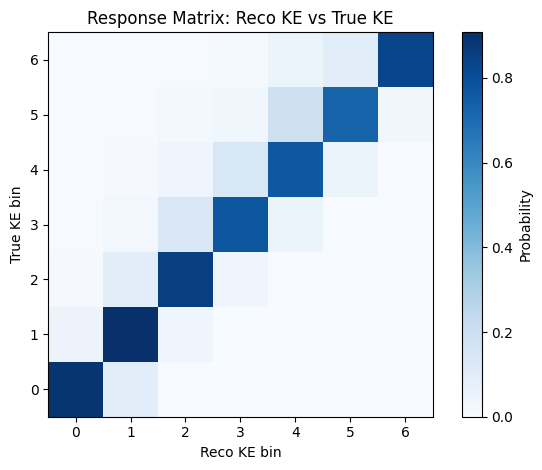

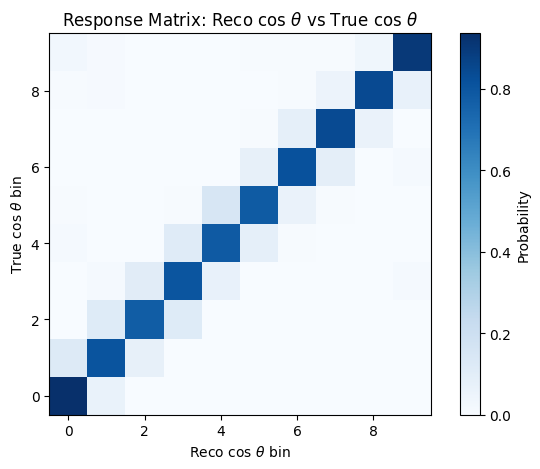

In [13]:
R = cv_results['reco_ke']['response']
plt.imshow(R,
           origin='lower',
           cmap='Blues')
plt.xlabel('Reco KE bin')
plt.ylabel('True KE bin')
plt.title('Response Matrix: Reco KE vs True KE')
plt.colorbar(label='Probability')
plt.tight_layout()
fig = os.path.join(PLOT_DIR, 'response_matrix_reco_ke.png')
plt.savefig(fig, dpi=300, bbox_inches='tight')
plt.show()

R = cv_results['reco_costheta']['response']
plt.imshow(R,
           origin='lower',
           cmap='Blues')
plt.xlabel(r'Reco cos $\theta$ bin')
plt.ylabel(r'True cos $\theta$ bin')
plt.title(r'Response Matrix: Reco cos $\theta$ vs True cos $\theta$')
plt.colorbar(label='Probability')
plt.tight_layout()
fig = os.path.join(PLOT_DIR, 'response_matrix_reco_costheta.png')
plt.savefig(fig, dpi=300, bbox_inches='tight')
plt.show()

In [14]:
for v in ['reco_ke','reco_costheta']:
    R = cv_results[v]['response']

    print(v)
    print(R.shape)
    print("diag =", np.diag(R))
    print("mean =", np.mean(np.diag(R)))

reco_ke
(7, 7)
diag = [0.89320388 0.90772532 0.85405872 0.77582645 0.76785714 0.72473118
 0.83293839]
mean = 0.8223344411253362
reco_costheta
(10, 10)
diag = [0.93617021 0.80597015 0.77272727 0.80232558 0.7862069  0.78017241
 0.81605351 0.83818182 0.84201077 0.90301318]
mean = 0.8282831811041659


In [15]:
# import uproot
# from makedf.getsyst import print_syst_all

# f = uproot.open("/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/input598.caf.root")
# print_syst_all(f)

## 6. Universe Histograms 

In [16]:
def build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
                     var_col, bins, ps, clip=10.0):
    sel  = sel_df[sel_df[stage_col]]
    if sel.empty:
        nb = len(bins) - 1; nu = len(univ_cols)
        return np.zeros((nu, nb)), np.zeros((nu, nb))

    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values

    # ── align sel index levels to wgt_aligned index levels ───────────────────
    nwl = wgt_aligned.index.nlevels
    if sel.index.nlevels > nwl:
        sidx = sel.index.droplevel(list(range(nwl, sel.index.nlevels)))
    elif sel.index.nlevels == nwl:
        sidx = sel.index
    else:
        # sel has FEWER levels than wgt — unexpected; fall back to unweighted
        warnings.warn(
            f"build_univ_hists: sel has {sel.index.nlevels} index levels but "
            f"wgt_aligned has {nwl}. Returning unit weights."
        )
        nb = len(bins) - 1; nu = len(univ_cols)
        return np.zeros((nu, nb)), np.zeros((nu, nb))

    # Add this at the TOP of build_univ_hists, right after computing sidx:
    print(f"  sel index nlevels: {sel.index.nlevels}, names: {sel.index.names}")
    print(f"  wgt index nlevels: {wgt_aligned.index.nlevels}, names: {wgt_aligned.index.names}")
    print(f"  sidx nlevels: {sidx.nlevels}, names: {sidx.names}")
    print(f"  sel first 3 indices:  {list(sel.index[:3])}")
    print(f"  sidx first 3 indices: {list(sidx[:3])}")
    print(f"  wgt first 3 indices:  {list(wgt_aligned.index[:3])}")
    
    # Check overlap
    overlap = sidx.isin(wgt_aligned.index)
    print(f"  sidx ∩ wgt_aligned: {overlap.sum()} / {len(sidx)} "
          f"({overlap.mean()*100:.1f}%)")
    
    # ── guard against duplicate wgt_aligned index (merged files) ─────────────
    wgt_sub = wgt_aligned[univ_cols]
    if wgt_sub.index.duplicated().any():
        wgt_sub = wgt_sub[~wgt_sub.index.duplicated(keep='first')]

    # reindex: rows in sel that have no weight match get NaN → replaced by 1.0
    wmat = wgt_sub.reindex(sidx).values.astype(np.float32)

    # sanity: warn if most weights are missing (likely file mismatch)
    nan_frac = np.isnan(wmat).mean()
    if nan_frac > 0.5:
        warnings.warn(
            f"build_univ_hists [{var_col}]: {nan_frac*100:.0f}% of weights "
            "are NaN after reindex — check that DF_FILE and WEIGHTS_FILE "
            "correspond to the same MC sample."
        )

    nu = len(univ_cols); nb = len(bins) - 1
    su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))

    for ui in tqdm(range(nu), desc=var_col, leave=False):
        w = np.where(np.isfinite(wmat[:, ui]), wmat[:, ui].astype(float), 1.0)
        w = np.clip(w, 0.0, clip) * ps
        su[ui], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[ui], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])

    return su, bu

In [17]:
SRC_LABEL = {'flux': 'BNB Flux', 'genie': 'GENIE', 'extra_xsec': 'Other Xsec Syst.',
             'g4': 'Geant4', 'mcstat': 'MCstat'}
univ_results = {}
lowE_univ_results = {}

# ── Main MC universes ─────────────────────────────────────────────────────────
for vcfg in VAR_CFGS:
    univ_results[vcfg.name] = {}
    for src, cols in [('flux',      bnb_cols_aligned),
                      ('genie',     genie_cols_aligned),
                      ('extra_xsec', extra_cols_aligned),
                      ('g4',        g4_cols_aligned)]:
        if not cols:
            continue
        print(f'[{vcfg.name}] {src} ({len(cols)} cols) ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  cols, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name][src] = {'sig': su, 'bkg': bu}
    gc.collect()

# ── LowE dirt universes ──────────────────────────────────────────────────────
for vcfg in VAR_CFGS:
    lowE_univ_results[vcfg.name] = {}
    for src, cols in [('flux',       lowE_bnb_cols_aligned),
                      ('genie',      lowE_genie_cols_aligned),
                      ('extra_xsec', lowE_extra_cols_aligned),
                      ('g4',         lowE_g4_cols_aligned)]:
        if not cols:
            continue
        print(f'[{vcfg.name}] LowE {src} ({len(cols)} cols) ...')
        su, bu = build_univ_hists(lowE_sel, FINAL_STAGE, lowE_wgt_aligned,
                                  cols, vcfg.name, vcfg.bins, lowE_pot_scale)
        lowE_univ_results[vcfg.name][src] = {'sig': su, 'bkg': bu}
    gc.collect()

print('All universes done (main MC + lowE).')

[reco_ke] flux (100 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(101, 14, 1), (111, 2, 5), (123, 7, 0)]
  sidx first 3 indices: [(101, 14, 1), (111, 2, 5), (123, 7, 0)]
  wgt first 3 indices:  [(0, 1, 6), (0, 2, 2), (0, 6, 1)]
  sidx ∩ wgt_aligned: 9440 / 9440 (100.0%)


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] genie (100 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(101, 14, 1), (111, 2, 5), (123, 7, 0)]
  sidx first 3 indices: [(101, 14, 1), (111, 2, 5), (123, 7, 0)]
  wgt first 3 indices:  [(0, 1, 6), (0, 2, 2), (0, 6, 1)]
  sidx ∩ wgt_aligned: 9440 / 9440 (100.0%)


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] extra_xsec (100 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(101, 14, 1), (111, 2, 5), (123, 7, 0)]
  sidx first 3 indices: [(101, 14, 1), (111, 2, 5), (123, 7, 0)]
  wgt first 3 indices:  [(0, 1, 6), (0, 2, 2), (0, 6, 1)]
  sidx ∩ wgt_aligned: 9440 / 9440 (100.0%)


...

reco_costheta:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] LowE g4 (300 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(218, 5, 0), (329, 2, 0), (351, 14, 0)]
  sidx first 3 indices: [(218, 5, 0), (329, 2, 0), (351, 14, 0)]
  wgt first 3 indices:  [(0, 0, 1), (0, 8, 3), (0, 12, 0)]
  sidx ∩ wgt_aligned: 585 / 585 (100.0%)


/tmp/ipykernel_3676852/1571029388.py:51: UserWarning: build_univ_hists [reco_costheta]: 100% of weights are NaN after reindex — check that DF_FILE and WEIGHTS_FILE correspond to the same MC sample.
  warnings.warn(


reco_costheta:   0%|          | 0/300 [00:00<?, ?it/s]

All universes done (main MC + lowE).


## 7. MCstat Universes (Poisson resampling)

In [18]:
from numpy.random import Generator, PCG64, SeedSequence

def build_mcstat_univs(sel_df, stage_col, var_col, bins, ps, nu=100, seed=42):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
    ne   = len(sel); ss = SeedSequence(seed); kids = ss.spawn(nu)
    nb   = len(bins) - 1; su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
    for u in tqdm(range(nu), desc=f'{var_col} MCstat', leave=False):
        w = Generator(PCG64(kids[u])).poisson(1.0, size=ne) * ps
        su[u], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[u], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    return su, bu

for vcfg in VAR_CFGS:
    print(f'[{vcfg.name}] MCstat ...')
    su, bu = build_mcstat_univs(sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale)
    univ_results[vcfg.name]['mcstat'] = {'sig': su, 'bkg': bu}

for vcfg in VAR_CFGS:
    print(f'[{vcfg.name}] LowE MCstat ...')
    su, bu = build_mcstat_univs(lowE_sel, FINAL_STAGE, vcfg.name,
                                vcfg.bins, lowE_pot_scale, seed=137)
    lowE_univ_results[vcfg.name]['mcstat'] = {'sig': su, 'bkg': bu}

del wgt_aligned
del lowE_wgt_aligned
gc.collect()
print('MCstat done. Weights freed.')

[reco_ke] MCstat ...


reco_ke MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] MCstat ...


reco_costheta MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] LowE MCstat ...


reco_ke MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] LowE MCstat ...


reco_costheta MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

MCstat done. Weights freed.


## 7. Covariance Matrices

In [19]:
def _mat(block):
    return block.get('cov', block) if isinstance(block, dict) else block

def compute_covs(su, bu, s_cv, b_cv):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return {
            'cov_ms_ms': get_covariance_matrix_self(su, s_cv),
            'cov_bs_bs': get_covariance_matrix_self(bu, b_cv),
            'cov_ms_bs': get_covariance_matrix(su, s_cv, bu, b_cv),
            'cov_bs_ms': get_covariance_matrix(bu, b_cv, su, s_cv),
        }

cov_results = {}

# ── Main MC covariances ──────────────────────────────────────────────────────
for vcfg in VAR_CFGS:
    cov_results[vcfg.name] = {}
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        print(f'[{vcfg.name}] cov: {src} ...')
        cov_results[vcfg.name][src] = compute_covs(
            ud['sig'], ud['bkg'], cv['sig_cv'], cv['bkg_cv'])

# ── LowE dirt covariances → add to main MC covariances ───────────────────────
for vcfg in VAR_CFGS:
    dirt_cv = lowE_cv[vcfg.name]
    zero_cv = np.zeros_like(dirt_cv)

    for src, ud in lowE_univ_results[vcfg.name].items():
        print(f'[{vcfg.name}] lowE cov: {src} ...')
        lowE_covs = compute_covs(ud['sig'], ud['bkg'], zero_cv, dirt_cv)

        if src in cov_results[vcfg.name]:
            for bk in ['cov_ms_ms', 'cov_bs_bs', 'cov_ms_bs', 'cov_bs_ms']:
                cov_results[vcfg.name][src][bk] = (
                    _mat(cov_results[vcfg.name][src][bk]) + _mat(lowE_covs[bk])
                )
            print(f'  [{vcfg.name}] {src}: added lowE contribution')
        else:
            cov_results[vcfg.name][src] = lowE_covs
            print(f'  [{vcfg.name}] {src}: new source from lowE')

print('All covariances computed (main MC + lowE combined).')

[reco_ke] cov: flux ...
[reco_ke] cov: genie ...
[reco_ke] cov: extra_xsec ...
[reco_ke] cov: g4 ...
[reco_ke] cov: mcstat ...
[reco_costheta] cov: flux ...
[reco_costheta] cov: genie ...
[reco_costheta] cov: extra_xsec ...
[reco_costheta] cov: g4 ...
[reco_costheta] cov: mcstat ...
[reco_ke] lowE cov: flux ...
  [reco_ke] flux: added lowE contribution
[reco_ke] lowE cov: genie ...
  [reco_ke] genie: added lowE contribution
[reco_ke] lowE cov: extra_xsec ...
  [reco_ke] extra_xsec: added lowE contribution
[reco_ke] lowE cov: g4 ...
  [reco_ke] g4: added lowE contribution
[reco_ke] lowE cov: mcstat ...
  [reco_ke] mcstat: added lowE contribution
[reco_costheta] lowE cov: flux ...
  [reco_costheta] flux: added lowE contribution
[reco_costheta] lowE cov: genie ...
  [reco_costheta] genie: added lowE contribution
[reco_costheta] lowE cov: extra_xsec ...
  [reco_costheta] extra_xsec: added lowE contribution
[reco_costheta] lowE cov: g4 ...
  [reco_costheta] g4: added lowE contribution
[reco

In [20]:
# ── N_targets calculation from your FV definition ────────────────────────────
# FV from _fiducial_cut_tmp in make_nueCC_df.py:
#   |x| in (5, 190), combined z/y regions

# Region 1: z in (10,250), y in (-190,190), full x  
V1 = (2 * 185.0) * 380.0 * 240.0   # cm³

# Region 2: z in (250,450), y in (-190,100), x < 0 only
V2 = 185.0 * 290.0 * 200.0         # cm³

# Region 3: z in (250,450), y in (-190,190), x > 0 only
V3 = 185.0 * 380.0 * 200.0         # cm³

V_FV = V1 + V2 + V3
rho_LAr = 1.3954    # g/cm³  (SBND LAr density)
N_A     = 6.022e23  # Avogadro
A_Ar    = 39.948     # g/mol

M_FV = rho_LAr * V_FV
N_targets = M_FV * N_A / A_Ar
print(f"FV volume:  {V_FV:.2e} cm³")
print(f"LAr mass:   {M_FV:.2e} g = {M_FV/1e6:.3f} tonnes")
print(f"N_targets:  {N_targets:.4e}")

FRAC_POT      = 0.02    # 2% POT counting uncertainty
FRAC_NTARGETS = 0.01    # 1% fiducial mass / number of targets uncertainty

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    sig_cv = cv['sig_cv']
    bkg_cv = cv['bkg_cv']

    for src_name, frac in [('pot', FRAC_POT), ('ntargets', FRAC_NTARGETS)]:
        cov_ms = frac**2 * np.outer(sig_cv, sig_cv)
        cov_bs = frac**2 * np.outer(bkg_cv, bkg_cv)

        cov_results[vcfg.name][src_name] = {
            'cov_ms_ms': cov_ms,
            'cov_bs_bs': cov_bs,
            'cov_ms_bs': frac**2 * np.outer(sig_cv, bkg_cv),
            'cov_bs_ms': frac**2 * np.outer(bkg_cv, sig_cv),
        }
        print(f'[{vcfg.name}] {src_name}: frac_unc={frac}, '
              f'diag sig = {np.sqrt(np.diag(cov_ms))}')

    # Also add to univ_results so the save/plot loop picks them xup
    # (these don't have universe histograms, so we skip the universe plots)

print('POT + N_targets covariance matrices added.')


FV volume:  5.85e+07 cm³
LAr mass:   8.17e+07 g = 81.678 tonnes
N_targets:  1.2313e+30
[reco_ke] pot: frac_unc=0.02, diag sig = [12.73737424 50.80914022 42.66844925 32.14169368 24.42207293 15.9304901
 25.29930256]
[reco_ke] ntargets: frac_unc=0.01, diag sig = [ 6.36868712 25.40457011 21.33422462 16.07084684 12.21103646  7.96524505
 12.64965128]
[reco_costheta] pot: frac_unc=0.02, diag sig = [  5.50900208   3.89489956   3.3334726    3.82472119   5.75462638
   8.24595853  11.4039852   19.82538966  38.17703354 104.03943423]
[reco_costheta] ntargets: frac_unc=0.01, diag sig = [ 2.75450104  1.94744978  1.6667363   1.9123606   2.87731319  4.12297927
  5.7019926   9.91269483 19.08851677 52.01971712]
POT + N_targets covariance matrices added.


## 8. Detector variation systematics

In [21]:
# # Prerequisites:
# #   Run build_detsys_covariances.py first (from the detvar/ directory):
# #     python3 build_detsys_covariances.py
# #
# #   This produces:
# #     saved_syst/reco_ke/detsys_cov_matrices.npz
# #     saved_syst/reco_costheta/detsys_cov_matrices.npz
# #
# # What this does:
# #   - Loads the det-sys covariance matrices (wiremod shape variations)
# #   - Adds them to cov_results so they automatically propagate to:
# #       • Total covariance sum (Cell 9 save_npz)
# #       • Fractional uncertainty plots (Cell 12)
# #       • Systematic band on stacked histograms (Cell 13)
# #       • Unblinding chi2 (Cell 14)
# # ══════════════════════════════════════════════════════════════════════════════

# SRC_LABEL = {
#     'flux':       'BNB Flux',
#     'genie':      'GENIE',
#     'extra_xsec': 'Extra Xsec',
#     'g4':         'Geant4',          
#     'mcstat':     'MCstat',
#     'pot':        'POT',
#     'ntargets':   r'$N_\mathrm{targets}$',
# }
# COLORS = {
#     'flux':       '#2196F3',
#     'genie':      '#F44336',
#     'extra_xsec': '#FF9800',
#     'g4':         '#00BCD4',        
#     'mcstat':     '#4CAF50',
#     'pot':        '#9C27B0',
#     'ntargets':   '#795548',
# }

# print('=== Loading detector systematics ===')

# for vcfg in VAR_CFGS:
#     detsys_path = f'{SYST_DIR}/{vcfg.name}/detsys_cov_matrices.npz'
#     if not os.path.exists(detsys_path):
#         print(f'  [{vcfg.name}] detsys NOT FOUND at {detsys_path}')
#         print(f'    → Run: cd detvar && python3 build_detsys_covariances.py')
#         continue

#     d = np.load(detsys_path)

#     # Verify shape matches the current binning
#     nb = len(vcfg.bins) - 1
#     cov_shape = d['cov_ms_ms'].shape
#     if cov_shape != (nb, nb):
#         print(f'  [{vcfg.name}] detsys SHAPE MISMATCH: '
#               f'expected ({nb},{nb}), got {cov_shape}')
#         print(f'    → Rerun build_detsys_covariances.py with matching binning')
#         continue

#     cov_results[vcfg.name]['detsys'] = {
#         'cov_ms_ms': d['cov_ms_ms'],
#         'cov_bs_bs': d['cov_bs_bs'],
#         'cov_ms_bs': d['cov_ms_bs'],
#         'cov_bs_ms': d['cov_bs_ms'],
#     }

#     frac_sig = d['frac_unc_sig']
#     frac_bkg = d['frac_unc_bkg']
#     variations = d['variations']
#     print(f'  [{vcfg.name}] detsys loaded:')
#     print(f'    Variations: {list(variations)}')
#     print(f'    Mean frac unc — signal: {frac_sig.mean()*100:.2f}%  '
#           f'bkg: {frac_bkg.mean()*100:.2f}%')

#     # Per-bin detail
#     centers = 0.5 * (vcfg.bins[:-1] + vcfg.bins[1:])
#     for c, fs, fb in zip(centers, frac_sig, frac_bkg):
#         print(f'      {c:8.1f}: sig {fs*100:5.2f}%  bkg {fb*100:5.2f}%')

# # Add to plotting dicts (used by Cell 12 fracunc plots)
# SRC_LABEL['detsys'] = 'Detector'
# COLORS['detsys']    = '#8B0000'

# # Verify integration: recompute total covariance with detsys included
# print('\nUpdated total covariance (with detsys):')
# for vcfg in VAR_CFGS:
#     cv = cv_results[vcfg.name]
#     ts = sum(_mat(cov_results[vcfg.name][s]['cov_ms_ms'])
#              for s in cov_results[vcfg.name])
#     total_frac = np.sqrt(np.diag(ts).sum()) / cv['sig_cv'].sum() \
#         if cv['sig_cv'].sum() > 0 else 0
#     print(f'  {vcfg.name}: total signal frac unc = {total_frac*100:.2f}%')

# print('\nDet-sys integration complete.')

## 9. Export uncertainty weights

### 9.1 Export weights for OmniFold

In [22]:
# ── Sanity check before running universes ─────────────────────────────────────
print("Column alignment check:")
print(f"  bnb_cols_aligned:   {len(bnb_cols_aligned)}")
print(f"  genie_cols_aligned: {len(genie_cols_aligned)}")
print(f"  extra_cols_aligned: {len(extra_cols_aligned)}")
print(f"  g4_cols_aligned:    {len(g4_cols_aligned)}")

if len(bnb_cols_aligned) == 0:
    print("\nERROR: bnb_cols_aligned is empty.")
    print("First 3 cols in wgt_aligned:", list(wgt_aligned.columns[:3]))
    print("First 3 cols in _main_aligned['flux']:", _main_aligned['flux'][:3])
    raise RuntimeError("Re-run Section 2 and Section 3.1 before running this cell.")

Column alignment check:
  bnb_cols_aligned:   100
  genie_cols_aligned: 100
  extra_cols_aligned: 100
  g4_cols_aligned:    300



true_p efficiency:
     100.0: 0.0875  (59/674)
     300.0: 0.4322  (809/1872)
     500.0: 0.6016  (977/1624)
     700.0: 0.6303  (803/1274)
     900.0: 0.7224  (739/1023)
    1200.0: 0.7887  (1060/1344)
    1700.0: 0.8287  (827/998)

true_costheta efficiency:
      -0.9: 0.3013  (47/156)
      -0.7: 0.3472  (67/193)
      -0.5: 0.3359  (88/262)
      -0.3: 0.2886  (86/298)
      -0.1: 0.4062  (145/357)
       0.1: 0.4915  (232/472)
       0.3: 0.4769  (299/627)
       0.5: 0.5808  (550/947)
       0.7: 0.6380  (1114/1746)
       0.9: 0.7307  (3186/4360)
OmniFold events: 5,814
BNB p-bins:   (100, 7)
GENIE p-bins: (100, 7)
BNB cos-bins: (100, 10)

Saved universe weights:
  BNB (2D): shape=(5814, 100), univ0 mean=1.0281, std=0.0131
  GENIE (2D): shape=(5814, 100), univ0 mean=1.0898, std=0.0523


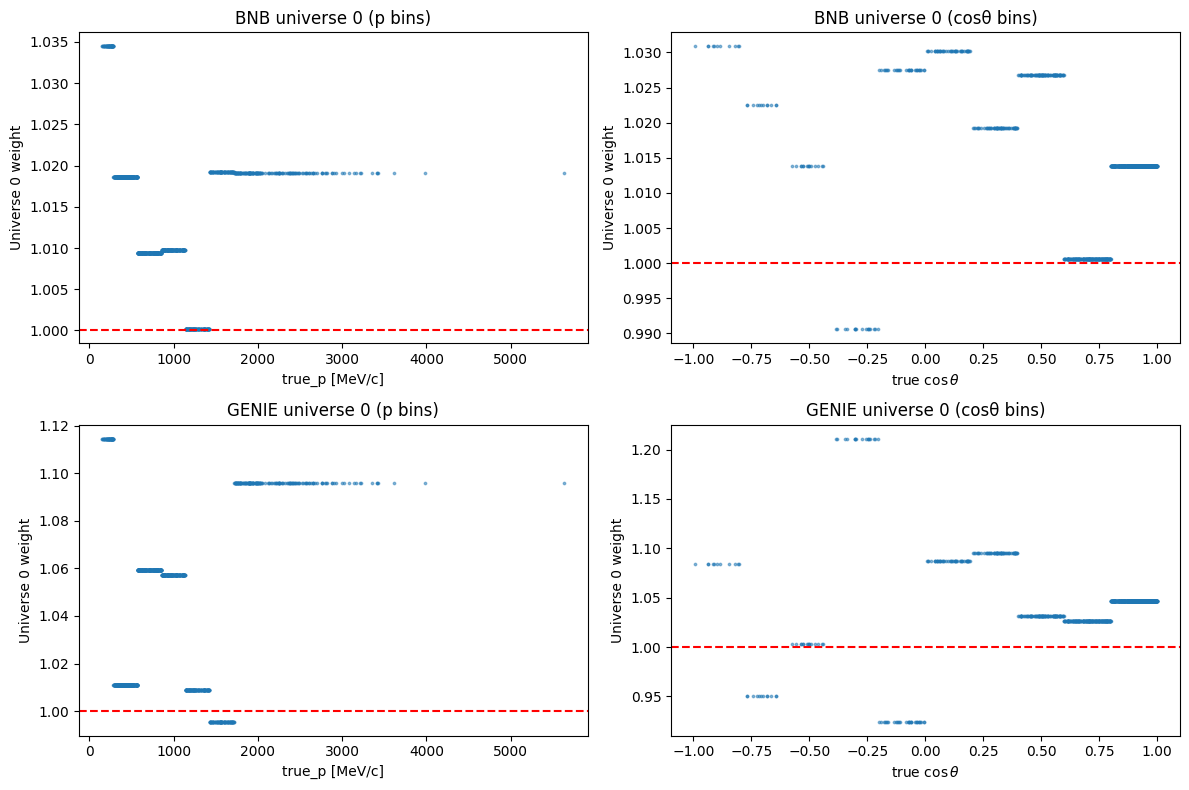

Done.


In [23]:
# ── Export binned fake data weights for OmniFold ─────────────────────────────
import numpy as np, os, matplotlib.pyplot as plt

OMNIFOLD_OUT  = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
OMNIFOLD_DATA = '/home/castalyf/FormattedData_SBND/'
os.makedirs(OMNIFOLD_OUT, exist_ok=True)


RECO_VARS = ['reco_p', 'reco_costheta']
FINAL_STAGE = 'sel_vertex_distance'

sig_all = sel_topo[sel_topo['is_sig']]
sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo[FINAL_STAGE]].copy()
reco_raw = sig_sel[RECO_VARS].values.astype(np.float32)
sig_sel_valid = sig_sel[~np.isnan(reco_raw).any(axis=1)]

bins_p   = np.array([0, 200, 400, 600, 800, 1000, 1400, 2000])
bins_cos = np.linspace(-1, 1, 11)

for var, bins, label in [('true_p', bins_p, 'true_p'),
                          ('true_costheta', bins_cos, 'true_costheta')]:
    N_all, _ = np.histogram(sig_all[var].dropna(), bins=bins)
    N_sel, _ = np.histogram(sig_sel_valid[var].dropna(), bins=bins)
    eff = N_sel / N_all.clip(1)
    np.save(OMNIFOLD_OUT + f'efficiency_{label}.npy', eff)
    centers = 0.5 * (bins[:-1] + bins[1:])
    print(f"\n{label} efficiency:")
    for c, e, na, ns in zip(centers, eff, N_all, N_sel):
        print(f"  {c:8.1f}: {e:.4f}  ({ns}/{na})")

# 1. Load OmniFold events
# Column order matches FormatData_SBND.py:
#   col 0 = true_p, col 1 = true_costheta
truth_raw  = np.load(OMNIFOLD_DATA + 'mc_vals_truth_NoNorm.npy')  # (6399, 2)
mc_weights = np.load(OMNIFOLD_DATA + 'mc_weights_reco.npy')       # (6399,)
true_p        = truth_raw[:, 0]
true_costheta = truth_raw[:, 1]
n_events = len(true_p)
print(f"OmniFold events: {n_events:,}")

# 2. Get universe histograms — with graceful fallback if flux missing
def _require_src(univ_dict, src, var_name):
    if src not in univ_dict:
        raise KeyError(
            f"Source '{src}' missing from univ_results['{var_name}']. "
            f"Available: {list(univ_dict.keys())}. "
            f"Re-run Cell 6 after ensuring {src}_cols_aligned is non-empty."
        )
    return univ_dict[src]

su_bnb_p   = _require_src(univ_results['reco_ke'],       'flux',  'reco_ke')['sig']
su_genie_p = _require_src(univ_results['reco_ke'],       'genie', 'reco_ke')['sig']
su_bnb_cos = _require_src(univ_results['reco_costheta'], 'flux',  'reco_costheta')['sig']
su_genie_cos = _require_src(univ_results['reco_costheta'], 'genie', 'reco_costheta')['sig']

sig_cv_p   = cv_results['reco_ke']['sig_cv']
sig_cv_cos = cv_results['reco_costheta']['sig_cv']

print(f"BNB p-bins:   {su_bnb_p.shape}")
print(f"GENIE p-bins: {su_genie_p.shape}")
print(f"BNB cos-bins: {su_bnb_cos.shape}")

# 3. Per-bin ratios
ratio_bnb_p    = su_bnb_p    / np.clip(sig_cv_p[np.newaxis, :],   1.0, None)
ratio_genie_p  = su_genie_p  / np.clip(sig_cv_p[np.newaxis, :],   1.0, None)
ratio_bnb_cos  = su_bnb_cos  / np.clip(sig_cv_cos[np.newaxis, :], 1.0, None)
ratio_genie_cos= su_genie_cos / np.clip(sig_cv_cos[np.newaxis, :], 1.0, None)

# 4. Assign per-event weights by bin
# p-binning (matches reco_ke bins — same MeV range)
bins_p   = np.linspace(0, 2000, 8)       # must match RECO_BINS from cell 4
bins_cos = np.linspace(-1, 1, 11)        # must match COS_BINS from cell 4

def assign_bin_weights(var_vals, bins, ratio_matrix):
    """Map each event to its bin and return per-event weights (N_events, N_universes)."""
    idx = np.digitize(var_vals.clip(bins[0], bins[-1] - 1e-8), bins) - 1
    idx = np.clip(idx, 0, len(bins) - 2)
    n_u = ratio_matrix.shape[0]
    out = np.ones((len(var_vals), n_u), dtype=np.float32)
    for u in range(n_u):
        out[:, u] = ratio_matrix[u, idx]
    return out

bnb_per_event_p    = assign_bin_weights(true_p,        bins_p,   ratio_bnb_p)
genie_per_event_p  = assign_bin_weights(true_p,        bins_p,   ratio_genie_p)
bnb_per_event_cos  = assign_bin_weights(true_costheta, bins_cos, ratio_bnb_cos)
genie_per_event_cos= assign_bin_weights(true_costheta, bins_cos, ratio_genie_cos)

# Combined: use the geometric mean of p and costheta weights as the 2D weight
# This approximates a 2D binned fake data from two 1D universe projections
bnb_2d   = bnb_per_event_p   * bnb_per_event_cos
genie_2d = genie_per_event_p * genie_per_event_cos

# 5. Save — keep both 1D projections and the 2D combined
np.save(OMNIFOLD_OUT + 'bnb_universe_weights.npy',     bnb_2d)
np.save(OMNIFOLD_OUT + 'genie_universe_weights.npy',   genie_2d)

# Also save 1D versions for diagnostics
np.save(OMNIFOLD_OUT + 'bnb_universe_weights_p.npy',       bnb_per_event_p)
np.save(OMNIFOLD_OUT + 'bnb_universe_weights_costheta.npy', bnb_per_event_cos)

print(f"\nSaved universe weights:")
for name, vals in [('BNB (2D)', bnb_2d), ('GENIE (2D)', genie_2d)]:
    u0 = vals[:, 0]
    print(f"  {name}: shape={vals.shape}, "
          f"univ0 mean={u0.mean():.4f}, std={u0.std():.4f}")

# 6. Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (name, vals_p, vals_cos) in enumerate([
    ('BNB',   bnb_per_event_p,   bnb_per_event_cos),
    ('GENIE', genie_per_event_p, genie_per_event_cos)
]):
    axes[row][0].scatter(true_p[::5],        vals_p[::5, 0],   s=3, alpha=0.5)
    axes[row][0].axhline(1.0, color='r', linestyle='--')
    axes[row][0].set_xlabel('true_p [MeV/c]')
    axes[row][0].set_ylabel('Universe 0 weight')
    axes[row][0].set_title(f'{name} universe 0 (p bins)')

    axes[row][1].scatter(true_costheta[::5], vals_cos[::5, 0], s=3, alpha=0.5)
    axes[row][1].axhline(1.0, color='r', linestyle='--')
    axes[row][1].set_xlabel(r'true $\cos\theta$')
    axes[row][1].set_ylabel('Universe 0 weight')
    axes[row][1].set_title(f'{name} universe 0 (cosθ bins)')

plt.tight_layout()
plt.savefig(OMNIFOLD_OUT + 'binned_fakedata_diagnostic.png', dpi=100)
plt.show()
print("Done.")

In [24]:
# ── Export G4 + extra_xsec universe weights for OmniFold ─────────────────────
import numpy as np, os

OMNIFOLD_OUT  = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
OMNIFOLD_DATA = '/home/castalyf/FormattedData_SBND/'

truth_raw  = np.load(OMNIFOLD_DATA + 'mc_vals_truth_NoNorm.npy')
mc_weights = np.load(OMNIFOLD_DATA + 'mc_weights_reco.npy')
true_p        = truth_raw[:, 0]
true_costheta = truth_raw[:, 1]
n_events = len(true_p)
print(f"OmniFold events: {n_events:,}")

bins_p   = np.array([0, 200, 400, 600, 800, 1000, 1400, 2000])
bins_cos = np.linspace(-1, 1, 11)
sig_cv_p   = cv_results['reco_ke']['sig_cv']
sig_cv_cos = cv_results['reco_costheta']['sig_cv']

def assign_bin_weights(var_vals, bins, ratio_matrix):
    idx = np.digitize(var_vals.clip(bins[0], bins[-1] - 1e-8), bins) - 1
    idx = np.clip(idx, 0, len(bins) - 2)
    n_u = ratio_matrix.shape[0]
    out = np.ones((len(var_vals), n_u), dtype=np.float32)
    for u in range(n_u):
        out[:, u] = ratio_matrix[u, idx]
    return out

# G4 is already combined (300 universes) under key 'g4'
# extra_xsec is under key 'extra_xsec'
for src, n_expected, outname in [
    ('g4',         300, 'g4_universe_weights.npy'),
    ('extra_xsec', 100, 'extra_xsec_universe_weights.npy'),
]:
    su_p   = univ_results['reco_ke'][src]['sig']
    su_cos = univ_results['reco_costheta'][src]['sig']
    print(f"\n{src}: {su_p.shape[0]} universes (expected {n_expected})")

    ratio_p   = su_p   / np.clip(sig_cv_p[np.newaxis, :],   1.0, None)
    ratio_cos = su_cos / np.clip(sig_cv_cos[np.newaxis, :], 1.0, None)

    per_event_p   = assign_bin_weights(true_p,        bins_p,   ratio_p)
    per_event_cos = assign_bin_weights(true_costheta, bins_cos, ratio_cos)
    combined = per_event_p * per_event_cos

    np.save(OMNIFOLD_OUT + outname, combined)
    print(f"  Saved: {outname}  shape={combined.shape}")
    print(f"  univ0 mean={combined[:,0].mean():.4f}, std={combined[:,0].std():.4f}")

# Verification
print(f"\n=== Shape check (all should be ({n_events}, N_univ)) ===")
for name in ['bnb', 'genie', 'extra_xsec', 'g4', 'mcstat']:
    f = OMNIFOLD_OUT + f'{name}_universe_weights.npy'
    if os.path.exists(f):
        a = np.load(f)
        ok = "OK" if a.shape[0] == n_events else f"MISMATCH (expected {n_events})"
        print(f"  {name:12s}: {str(a.shape):>15s}  {ok}")
    else:
        print(f"  {name:12s}: NOT FOUND")

OmniFold events: 5,814

g4: 300 universes (expected 300)
  Saved: g4_universe_weights.npy  shape=(5814, 300)
  univ0 mean=0.9949, std=0.0013

extra_xsec: 100 universes (expected 100)
  Saved: extra_xsec_universe_weights.npy  shape=(5814, 100)
  univ0 mean=1.0641, std=0.0491

=== Shape check (all should be (5814, N_univ)) ===
  bnb         :     (5814, 100)  OK
  genie       :     (5814, 100)  OK
  extra_xsec  :     (5814, 100)  OK
  g4          :     (5814, 300)  OK
  mcstat      :     (5814, 100)  OK


In [25]:
# ── What's actually in the weight files? ─────────────────────────────────────
_load_hdf_key = nh.load_hdf_key
_is_univ = nh._is_univ

print("=== Main MC: first 10 universe col names ===")
with pd.HDFStore(WEIGHTS_FILE, mode='r') as store:
    _tmp = store[store.keys()[0]] if store.keys() else None
_tmp_mcnu = _load_hdf_key(WEIGHTS_FILE, 'mcnu')
_all = list(_tmp_mcnu.columns)
_univ_cols = [c for c in _all if _is_univ(c)]
for c in _univ_cols[:10]:
    print(' ', c)

print(f"\n=== Main MC: total univ cols = {len(_univ_cols)} ===")
print("\nUnique first-level names:")
_first = sorted(set(c[0] for c in _univ_cols if isinstance(c, tuple)))
for f in _first:
    n = sum(1 for c in _univ_cols if isinstance(c, tuple) and c[0] == f)
    print(f"  {f:<60s}: {n}")
del _tmp_mcnu

=== Main MC: first 10 universe col names ===
  ('Flux', 'univ_0')
  ('Flux', 'univ_1')
  ('Flux', 'univ_2')
  ('Flux', 'univ_3')
  ('Flux', 'univ_4')
  ('Flux', 'univ_5')
  ('Flux', 'univ_6')
  ('Flux', 'univ_7')
  ('Flux', 'univ_8')
  ('Flux', 'univ_9')

=== Main MC: total univ cols = 600 ===

Unique first-level names:
  Flux                                                        : 100
  GENIE                                                       : 100
  extra_xsec                                                  : 100
  reinteractions_piminus_Geant4                               : 100
  reinteractions_piplus_Geant4                                : 100
  reinteractions_proton_Geant4                                : 100


In [26]:
# ── Export MCstat universe weights for OmniFold ──────────────────────────────
from numpy.random import Generator, PCG64, SeedSequence

sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo['sel_vertex_distance']].copy()
reco_raw = sig_sel[['reco_ke', 'reco_costheta', 'reco_p']].values.astype(np.float32)
valid = ~np.isnan(reco_raw).any(axis=1)
sig_sel = sig_sel[valid]
n = len(sig_sel)

n_univ = 100
seed = 42
ss = SeedSequence(seed)
kids = ss.spawn(n_univ)

mcstat_weights = np.zeros((n, n_univ), dtype=np.float32)
for u in range(n_univ):
    mcstat_weights[:, u] = Generator(PCG64(kids[u])).poisson(1.0, size=n).astype(np.float32)

np.save(OMNIFOLD_OUT + 'mcstat_universe_weights.npy', mcstat_weights)
print(f"MCstat saved: {mcstat_weights.shape}")
print(f"  Univ 0: mean={mcstat_weights[:,0].mean():.4f}, std={mcstat_weights[:,0].std():.4f}")

MCstat saved: (5814, 100)
  Univ 0: mean=1.0043, std=1.0011


In [27]:
print(f"Notebook sel_topo shape: {sel_topo.shape}")
print(f"sel_topo['sel_vertex_distance'].sum(): {sel_topo['sel_vertex_distance'].sum()}")
print(f"sel_topo is_sig & sel_vertex_distance: {(sel_topo['is_sig'] & sel_topo['sel_vertex_distance']).sum()}")

# Check if sel_topo has been further filtered vs the raw pkl
df_raw = pd.read_pickle('/home/castalyf/cafpyana/analysis_village/nueCC/nuecc_dfs/selected_nuecc_qual.pkl')
print(f"\nRaw pkl shape: {df_raw.shape}")
print(f"Raw pkl is_sig & sel_vertex_distance: {(df_raw['is_sig'] & df_raw['sel_vertex_distance']).sum()}")

Notebook sel_topo shape: (2425112, 16)
sel_topo['sel_vertex_distance'].sum(): 9440
sel_topo is_sig & sel_vertex_distance: 5814

Raw pkl shape: (2425112, 16)
Raw pkl is_sig & sel_vertex_distance: 5814


### 9.2 Save NPZ Files for plotting and stats

In [28]:

def save_npz(path, cv, covs, extra=None):
    p = dict(ms=cv['sig_cv'], bs=cv['bkg_cv'])
    if 'true_sig_cv' in cv: p['true_signal'] = cv['true_sig_cv']
    if 'response'    in cv: p['response']    = cv['response']
    for bk, bv in covs.items():
        if isinstance(bv, dict):
            for k, v in bv.items():
                if isinstance(v, np.ndarray): p[f'{bk}_{k}'] = v
        else:
            p[bk] = bv
    if extra: p.update(extra)
    np.savez(path, **p)
    print(f'  {os.path.basename(path)}  ({os.path.getsize(path)/1024:.0f} KB)')

for vcfg in VAR_CFGS:
    vd = os.path.join(SYST_DIR, vcfg.name); os.makedirs(vd, exist_ok=True)
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        save_npz(os.path.join(vd, f'{src}_cov_matrices.npz'), cv, covs)
        # In the total covariance computation, replace the existing sum:
    if len(cov_results[vcfg.name]) > 1:
        ts = sum(_mat(cov_results[vcfg.name][s]['cov_ms_ms'])
                 for s in cov_results[vcfg.name])
        tb = sum(_mat(cov_results[vcfg.name][s]['cov_bs_bs'])
                 for s in cov_results[vcfg.name])
        save_npz(os.path.join(vd, 'total_cov_matrices.npz'), cv, {},
                 extra=dict(total_cov_ms_ms=ts, total_cov_bs_bs=tb))
print(f'\nAll NPZ saved to {SYST_DIR}/')


  flux_cov_matrices.npz  (4 KB)
  genie_cov_matrices.npz  (4 KB)
  extra_xsec_cov_matrices.npz  (4 KB)
  g4_cov_matrices.npz  (4 KB)
  mcstat_cov_matrices.npz  (4 KB)
  pot_cov_matrices.npz  (4 KB)
  ntargets_cov_matrices.npz  (4 KB)
  total_cov_matrices.npz  (3 KB)
  flux_cov_matrices.npz  (6 KB)
  genie_cov_matrices.npz  (6 KB)
  extra_xsec_cov_matrices.npz  (6 KB)
  g4_cov_matrices.npz  (6 KB)
  mcstat_cov_matrices.npz  (6 KB)
  pot_cov_matrices.npz  (6 KB)
  ntargets_cov_matrices.npz  (6 KB)
  total_cov_matrices.npz  (4 KB)

All NPZ saved to ./saved_syst/


## 10. Plots: Universe Spreads

In [29]:
def savefig(fig, name, sub=''):
    d = os.path.join(PLOT_DIR, sub) if sub else PLOT_DIR
    os.makedirs(d, exist_ok=True)
    fig.savefig(os.path.join(d, f'{name}.png'), dpi=150, bbox_inches='tight')
    display(fig)       # show inline in notebook
    plt.close(fig)

# for vcfg in VAR_CFGS:
#     cv = cv_results[vcfg.name]
#     for src, ud in univ_results[vcfg.name].items():
#         for categ, cv_arr, ua in [
#             ('Signal',     cv['sig_cv'], ud['sig']),
#             ('Background', cv['bkg_cv'], ud['bkg']),
#         ]:
#             try:
#                 plot_univ_hists(ua, cv_arr, SRC_LABEL[src], vcfg, categ_name=categ)
#                 fig = plt.gcf()   # grab whatever was just created
#                 savefig(fig, f'{vcfg.name}_{src}_{categ.lower()}_univs', 'univ')
#             except Exception as e:
#                 print(f'  [WARN] {vcfg.name}/{src}/{categ}: {e}')
#                 plt.close('all')

# print('Universe plots -> plots_syst/univ/')

## 11. Plots: Covariance Heatmaps

In [30]:
import re

def format_heatmap_value(v):
    if np.isnan(v): return ""
    av = abs(v)
    if av == 0: return "0"
    if av < 1:
        return f"{v:.4f}"
    elif av < 1e3:
        return f"{v:.2f}"
    mantissa, exponent = f"{v:.2e}".split("e")
    return rf"${mantissa}\times10^{{{int(exponent)}}}$"

def plot_heatmap_custom(matrix, title, vcfg, axis_labels=None,
                        cmap='viridis', vmin=None, vmax=None):
    """Heatmap with bin-range tick labels and formatted cell annotations."""
    try:
        from analysis_village.unfolding.utils import bin_range_labels, get_text_color
        raw     = bin_range_labels(vcfg.bins)
        t_lbls  = [re.sub(r'(\d+)\.0+(?!\d)', r'\1', l) for l in raw]
        _get_tc = get_text_color
    except Exception:
        t_lbls  = [f'{vcfg.bins[i]:.0f}–{vcfg.bins[i+1]:.0f}'
                   for i in range(len(vcfg.bins)-1)]
        _get_tc = lambda v: 'white'

    n        = len(vcfg.bins) - 1
    unif     = np.arange(n + 1, dtype=float)
    tick_pos = 0.5 * (unif[:-1] + unif[1:])
    extent   = [unif[0], unif[-1], unif[0], unif[-1]]

    fig, ax = plt.subplots(figsize=(max(6, n*0.8), max(5, n*0.7)))
    im = ax.imshow(matrix, extent=extent, origin='lower',
                   cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=9)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(t_lbls, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(t_lbls, fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

    xlbl, ylbl = axis_labels if axis_labels else [vcfg.var_plot_name]*2
    ax.set_xlabel(xlbl, fontsize=11)
    ax.set_ylabel(ylbl, fontsize=11)
    ax.set_title(title, fontsize=12)

    # Cell annotations
    fsize = max(5, 9 - n//3)   # shrink font for more bins
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            if not np.isnan(v):
                try:    tc = _get_tc(v)
                except: tc = 'white'
                ax.text(tick_pos[j], tick_pos[i],
                        format_heatmap_value(v),
                        ha='center', va='center',
                        color=tc, fontsize=fsize)
    fig.tight_layout()
    return fig, ax

## 12. Plots: Fractional Uncertainties per Bin

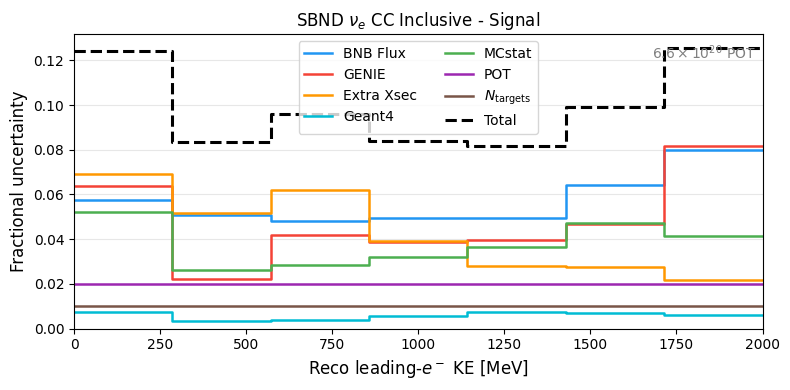

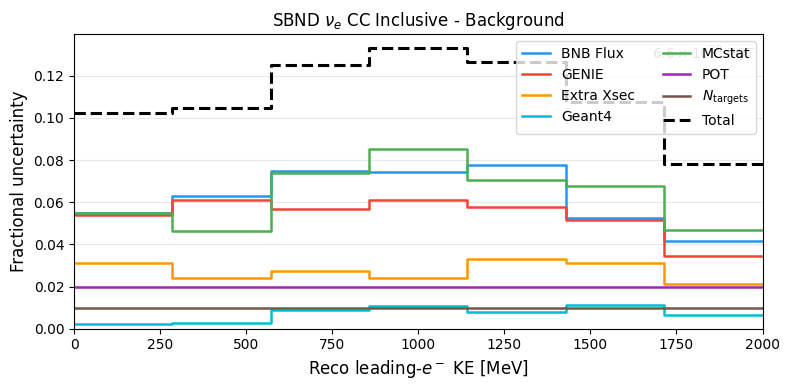

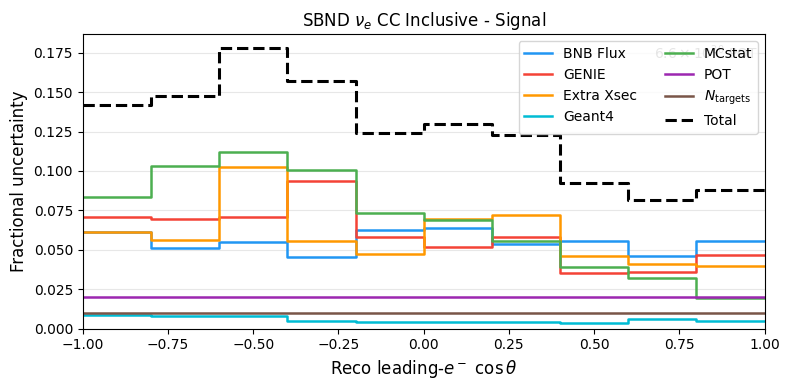

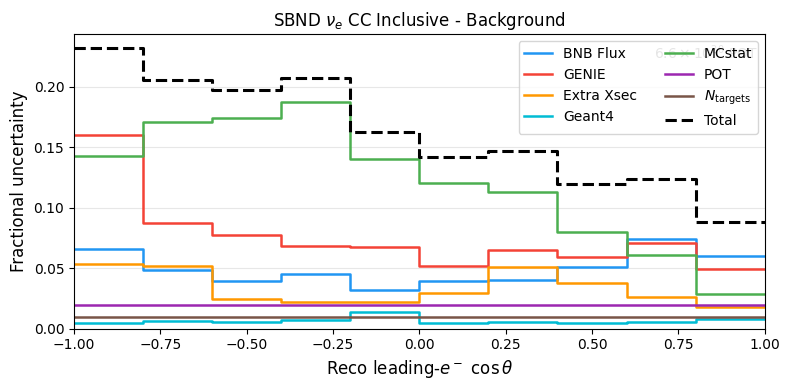

Fracunc plots -> plots_syst/fracunc/


In [31]:
SRC_LABEL = {
    'flux':       'BNB Flux',
    'genie':      'GENIE',
    'extra_xsec': 'Extra Xsec',
    'g4':         'Geant4',          
    'mcstat':     'MCstat',
    'pot':        'POT',
    'ntargets':   r'$N_\mathrm{targets}$',
}
COLORS = {
    'flux':       '#2196F3',
    'genie':      '#F44336',
    'extra_xsec': '#FF9800',
    'g4':         '#00BCD4',        
    'mcstat':     '#4CAF50',
    'pot':        '#9C27B0',
    'ntargets':   '#795548',
}
def plot_fracunc(vcfg, cv_arr, cov_results_var, block_key, categ):
    fig, ax = plt.subplots(figsize=(8, 4))
    total_var = np.zeros(len(vcfg.bin_centers))
    for src, covs in cov_results_var.items():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            diag = np.diag(_mat(covs[block_key])).clip(0)
            frac = np.where(cv_arr > 0, np.sqrt(diag) / cv_arr, 0.0)
        xe = np.append(vcfg.bins[:-1], vcfg.bins[-1])
        ye = np.append(frac, frac[-1])
        ax.step(xe, ye, where='post', label=SRC_LABEL[src],
                color=COLORS.get(src, 'gray'), lw=1.8)
        total_var += diag
    tot = np.where(cv_arr > 0, np.sqrt(total_var) / cv_arr, 0.0)
    ax.step(np.append(vcfg.bins[:-1], vcfg.bins[-1]),
            np.append(tot, tot[-1]),
            where='post', label='Total', color='black', lw=2.2, ls='--')
    ax.set_xlabel(vcfg.var_plot_name, fontsize=12)
    ax.set_ylabel('Fractional uncertainty', fontsize=12)
    ax.set_title(f'{TITLE} - {categ}', fontsize=12)
    ax.legend(fontsize=10, ncol=2)
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1]); ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.99, 0.97, vcfg.pot_label, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')
    fig.tight_layout(); return fig

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]; covs_var = cov_results[vcfg.name]
    for bk, categ, cv_arr in [
        ('cov_ms_ms', 'Signal',     cv['sig_cv']),
        ('cov_bs_bs', 'Background', cv['bkg_cv']),
    ]:
        fig = plot_fracunc(vcfg, cv_arr, covs_var, bk, categ)
        savefig(fig, f'{vcfg.name}_fracunc_{categ.lower()}', 'fracunc')
print('Fracunc plots -> plots_syst/fracunc/')


In [32]:
# After computing universe histograms, add chi2 for each source
import nue_helpers as nh
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        if src in ('pot', 'ntargets'):
            continue  # no universes for flat systs
        # chi2 of each universe vs CV, take median
        chi2s = []
        for u in range(ud['sig'].shape[0]):
            c2, _, _ = nh.chi2_pvalue(ud['sig'][u], cv['sig_cv'])
            chi2s.append(c2)
        print(f"  [{vcfg.name}] {src}: median χ²/ndof = "
              f"{np.median(chi2s):.1f}/{len(cv['sig_cv'])}")

  [reco_ke] flux: median χ²/ndof = 11.8/7
  [reco_ke] genie: median χ²/ndof = 19.9/7
  [reco_ke] extra_xsec: median χ²/ndof = 21.5/7
  [reco_ke] g4: median χ²/ndof = 0.1/7
  [reco_ke] mcstat: median χ²/ndof = 11.7/7
  [reco_costheta] flux: median χ²/ndof = 11.5/10
  [reco_costheta] genie: median χ²/ndof = 21.0/10
  [reco_costheta] extra_xsec: median χ²/ndof = 22.1/10
  [reco_costheta] g4: median χ²/ndof = 0.1/10
  [reco_costheta] mcstat: median χ²/ndof = 16.7/10


## 13. CV Stacked Histogram + Systematic Band

In [33]:
print(f"sel_topo shape        : {sel_topo.shape}")
print(f"Index names           : {sel_topo.index.names}")
print(f"Index nlevels         : {sel_topo.index.nlevels}")
stage_sum = sel_topo[FINAL_STAGE].sum()
sig_sum   = (sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == 0)
             & sel_topo['reco_ke'].notna()).sum()
print(f"Passing {FINAL_STAGE}: {stage_sum}")
print(f"Signal passing stage  : {sig_sum}")
print(f"Expected weighted sig : {sig_sum * pot_scale:.1f}  (should be ~9322)")

sel_topo shape        : (2425112, 16)
Index names           : ['__ntuple', 'entry', 'rec.dlp..index']
Index nlevels         : 3
Passing sel_vertex_distance: 9440
Signal passing stage  : 5814
Expected weighted sig : 10200.4  (should be ~9322)


In [34]:
def _build_mc_ob_series(sel_df, stage_col, var_col, mc_weight,
                         offbeam_vals, ob_weight,
                         dirt_vals=LOWE_RECO_FINAL.get(vcfg.name, np.array([])),
                         dirt_weight=lowE_pot_scale_to_data,
                         extra_mask=None):
    """
    Returns (series_list, weights_list, labels, colors) for plot_stacked_hist.
    MC cats 0-6, then dirt (cat 9), then offbeam (cat 7).
    """
    mc_cats = [0, 1, 2, 3, 4, 5, 6]
    series_list, weights_list = [], []
    for cat in mc_cats:
        m = sel_df[stage_col] & (sel_df['truth_cat'] == cat)
        if extra_mask is not None:
            m = m & extra_mask
        vals = sel_df.loc[m, var_col].dropna().values
        series_list.append(vals)
        weights_list.append(np.full(len(vals), mc_weight))

    labels = [nh.CAT_LABELS[c] for c in mc_cats]
    colors = [nh.CAT_COLORS[c] for c in mc_cats]

    # Dirt
    if dirt_vals is not None and dirt_weight is not None:
        dv = np.asarray(dirt_vals, dtype=float)
        dv = dv[~np.isnan(dv)]
        series_list.append(dv)
        weights_list.append(np.full(len(dv), dirt_weight))
        labels.append(nh.CAT_LABELS[9])
        colors.append(nh.CAT_COLORS[9])

    # Offbeam
    ob = np.asarray(offbeam_vals if offbeam_vals is not None else [], dtype=float)
    ob = ob[~np.isnan(ob)]
    series_list.append(ob)
    weights_list.append(np.full(len(ob), ob_weight))
    labels.append(nh.CAT_LABELS[7])
    colors.append(nh.CAT_COLORS[7])

    return series_list, weights_list, labels, colors
 
 
def _total_hist(series_list, weights_list, bins_arr):
    total = np.zeros(len(bins_arr) - 1)
    for s, w in zip(series_list, weights_list):
        v, _ = np.histogram(s, bins=bins_arr, weights=w)
        total += v
    return total


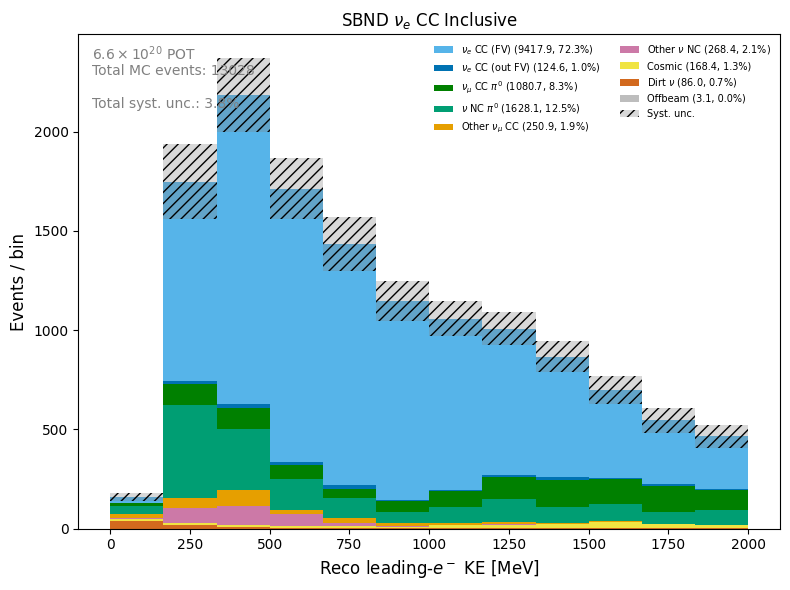

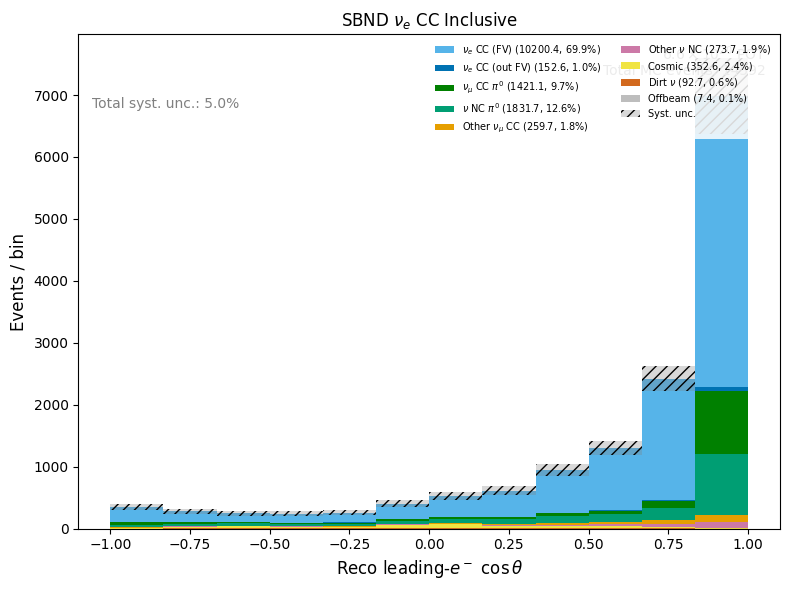

Stacked+syst -> plots_syst/


In [35]:
import nue_helpers as nh
 
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6, 9, 7]   # 9=dirt before 7=offbeam
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

 
DISP_KE_BINS  = np.linspace(0, 2000, 13)
DISP_COS_BINS = np.linspace(-1, 1,   13)
DISP_BINS_UNIFORM = {'reco_ke': DISP_KE_BINS, 'reco_costheta': DISP_COS_BINS}
 
_extra_mask = sel_topo['reco_ke'].notna() & sel_topo['reco_costheta'].notna()
 
for vcfg in VAR_CFGS:
    cv        = cv_results[vcfg.name]
    covs_var  = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)

    disp_bins    = DISP_BINS_UNIFORM[vcfg.name]
    disp_centers = 0.5 * (disp_bins[:-1] + disp_bins[1:])
    frac_cv      = np.where(cv['sig_cv'] > 0,
                            np.sqrt(total_var.clip(0)) / cv['sig_cv'], 0.0)
    frac_disp    = np.interp(disp_centers, vcfg.bin_centers, frac_cv)

    series_list, weights_list, labels_all, colors_all = _build_mc_ob_series(
        sel_topo, FINAL_STAGE, vcfg.name,
        mc_weight=pot_scale,
        offbeam_vals=OFFBEAM_RECO.get(vcfg.name, np.array([])), 
        ob_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_TOPO.get(vcfg.name, np.array([])),  # FIX
        dirt_weight=lowE_pot_scale_to_data,
        extra_mask=_extra_mask)

    total_disp = _total_hist(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_disp

    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=labels_all, colors=colors_all,
        bins=disp_bins, weights=weights_list,
        xlabel=vcfg.var_plot_name, title=TITLE,
        pot_label=POT_LABEL, ax=ax,
        invert_stack_order=True, show_counts=True, show_percentage=True)

    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_disp-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)

    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')

    total_frac = np.sqrt(total_var.sum()) / cv['sig_cv'].sum() \
        if cv['sig_cv'].sum() > 0 else 0

    ax.text(0.02, 0.85, f'Total syst. unc.: {total_frac*100:.1f}%',
            transform=ax.transAxes, fontsize=10, color='gray')

    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band')

print('Stacked+syst -> plots_syst/')


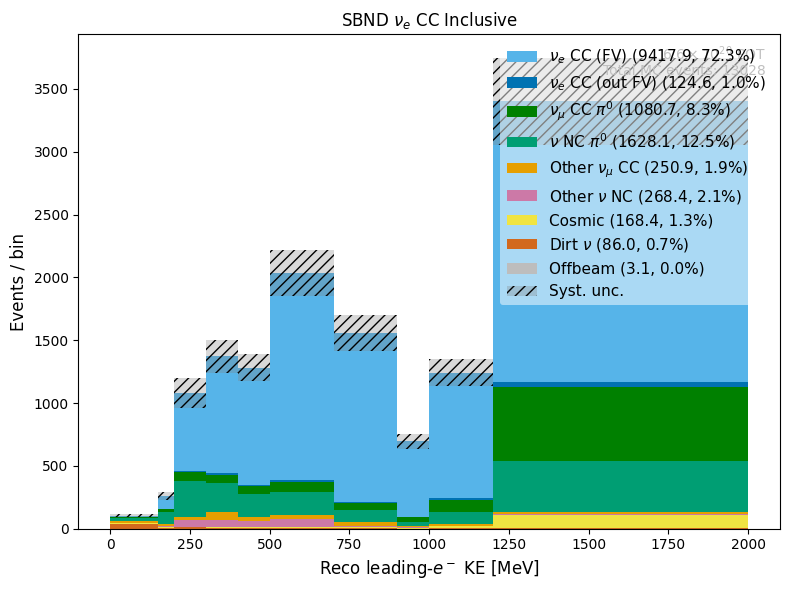

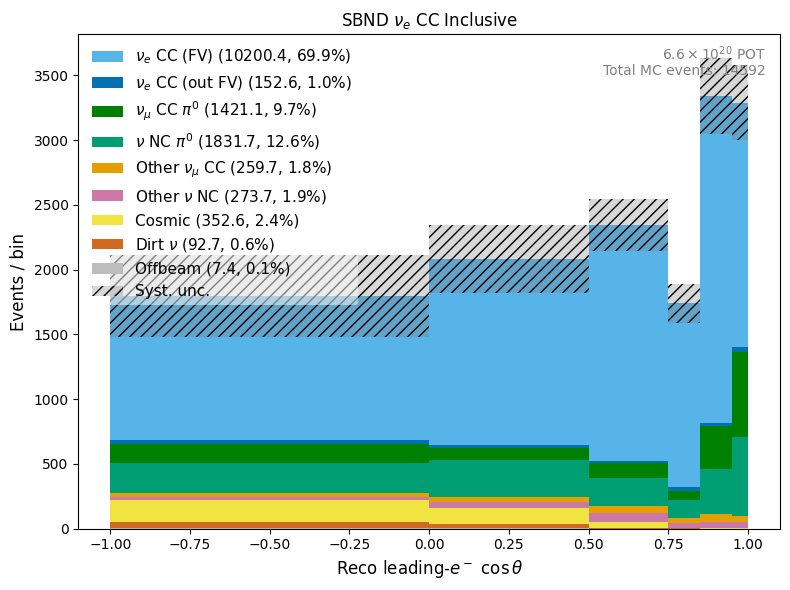

Stacked+syst (xsec bins) -> plots_syst/


In [36]:
from nue_xsec_helpers import make_nuecc_binning2d
_b2d = make_nuecc_binning2d()
_ke_edges  = np.unique(np.concatenate(_b2d.diff_momentum_bins_2d))
_ke_edges  = _ke_edges[_ke_edges <= 2000.0]
_cos_edges = _b2d.diff_costheta_bins.copy(); _cos_edges[-1] = 1.0
 
DISP_BINS_XSEC = {'reco_ke': _ke_edges, 'reco_costheta': _cos_edges, 'reco_p': _ke_edges}
 
for vcfg in VAR_CFGS:
    if vcfg.name not in DISP_BINS_XSEC:
        continue
    cv        = cv_results[vcfg.name]
    covs_var  = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
 
    disp_bins    = DISP_BINS_XSEC[vcfg.name]
    disp_centers = 0.5 * (disp_bins[:-1] + disp_bins[1:])
    frac_cv      = np.where(cv['sig_cv'] > 0,
                            np.sqrt(total_var.clip(0)) / cv['sig_cv'], 0.0)
    frac_disp    = np.interp(disp_centers, vcfg.bin_centers, frac_cv)
 
    series_list, weights_list, labels_all, colors_all = _build_mc_ob_series(
        sel_topo, FINAL_STAGE, vcfg.name,
        mc_weight=pot_scale,
        offbeam_vals=OFFBEAM_RECO.get(vcfg.name, np.array([])),
        ob_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_TOPO.get(vcfg.name, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        extra_mask=_extra_mask)
 
    total_disp = _total_hist(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_disp
 
    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=labels_all, colors=colors_all,
        bins=disp_bins, weights=weights_list,
        xlabel=vcfg.var_plot_name, title=TITLE,
        pot_label=POT_LABEL, ax=ax,
        invert_stack_order=True, show_counts=True, show_percentage=True)
 
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_disp-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=11, ncol=1, loc='best',
              frameon=True, framealpha=0.5, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band_xsecbins')
 
print('Stacked+syst (xsec bins) -> plots_syst/')


In [37]:
print(f'\n{"="*68}')
print(f'{"Variable":<16} {"Source":<10} {"Category":<14} {"Mean frac. unc.":>16}')
print(f'{"="*68}')
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        for bk, categ, cv_arr in [
            ('cov_ms_ms', 'Signal',     cv['sig_cv']),
            ('cov_bs_bs', 'Background', cv['bkg_cv']),
        ]:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                frac = np.where(cv_arr > 0,
                    np.sqrt(np.diag(_mat(covs[bk])).clip(0)) / cv_arr, np.nan)
            fu = float(np.nanmean(frac))
            print(f'  {vcfg.name:<14} {src:<10} {categ:<14} {fu*100:>14.2f}%')
print(f'{"="*68}')
print(f'\nNPZ files -> {SYST_DIR}/')
for vcfg in VAR_CFGS:
    vd = f'{SYST_DIR}/{vcfg.name}'
    if os.path.isdir(vd):
        print(f'  {vcfg.name}: {os.listdir(vd)}')
print(f'Plots     -> {PLOT_DIR}/')
for sub in ['univ', 'cov', 'fracunc']:
    sd = f'{PLOT_DIR}/{sub}'
    if os.path.isdir(sd):
        print(f'  {sub}/: {len(os.listdir(sd))} files')



Variable         Source     Category        Mean frac. unc.
  reco_ke        flux       Signal                   5.71%
  reco_ke        flux       Background               6.26%
  reco_ke        genie      Signal                   4.78%
  reco_ke        genie      Background               5.39%
  reco_ke        extra_xsec Signal                   4.27%
  reco_ke        extra_xsec Background               2.74%
  reco_ke        g4         Signal                   0.59%
  reco_ke        g4         Background               0.72%
  reco_ke        mcstat     Signal                   3.78%
  reco_ke        mcstat     Background               6.37%
  reco_ke        pot        Signal                   2.00%
  reco_ke        pot        Background               2.00%
  reco_ke        ntargets   Signal                   1.00%
  reco_ke        ntargets   Background               1.00%
  reco_costheta  flux       Signal                   5.50%
  reco_costheta  flux       Background               4

## 14. Data added: Unblind analysis

In [38]:
# CELL A (unblinding setup) — add offbeam FV/topo/final stage indices
# ══════════════════════════════════════════════════════════════════════════════
 
import nue_selection as nue_sel
import os, gc, warnings
 
UNBLIND_DIR  = f'{PLOT_DIR}/unblinding'
SIDEBAND_DIR = f'{PLOT_DIR}/sideband'
for d in [UNBLIND_DIR, SIDEBAND_DIR]: os.makedirs(d, exist_ok=True)
 
# Fractional syst (sig+bkg) from covariance
def get_total_frac_unc(var_name):
    cv = cv_results[var_name]; covs_var = cov_results[var_name]
    vs = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
    vb = sum(np.diag(_mat(covs_var[s]['cov_bs_bs'])).clip(0) for s in covs_var)
    tmc = cv['sig_cv'] + cv['bkg_cv']
    frac = np.where(tmc > 0, np.sqrt((vs+vb).clip(0)) / tmc, 0.0)
    vcfg = next(v for v in VAR_CFGS if v.name == var_name)
    return vcfg.bin_centers, frac
 
cov_centers_ke,  frac_unc_ke  = get_total_frac_unc('reco_ke')
cov_centers_cos, frac_unc_cos = get_total_frac_unc('reco_costheta')
 
def interp_frac_unc(disp_bins, proxy='reco_ke'):
    c = 0.5*(disp_bins[:-1]+disp_bins[1:])
    if proxy == 'reco_costheta':
        return np.interp(c, cov_centers_cos, frac_unc_cos,
                         left=frac_unc_cos[0], right=frac_unc_cos[-1])
    return np.interp(c, cov_centers_ke, frac_unc_ke,
                     left=frac_unc_ke[0], right=frac_unc_ke[-1])
 
from nue_xsec_helpers import make_nuecc_binning2d   # already loaded above
XSEC_KE_BINS  = np.unique(np.concatenate(_b2d.diff_momentum_bins_2d))
XSEC_KE_BINS  = XSEC_KE_BINS[XSEC_KE_BINS <= 2000.0]
XSEC_COS_BINS = _b2d.diff_costheta_bins.copy(); XSEC_COS_BINS[-1] = 1.0
 
from mem_optimizer import load_evtdf_slim
mc_evtdf_ub = load_evtdf_slim(DF_FILE, key=None, mode="reco_min_true")
mc_il       = list(range(mc_evtdf_ub.index.nlevels - 1))
data_il_ub  = list(range(data_evtdf_patched.index.nlevels - 1))
 
MC_FV_IDX    = sel_topo.index[sel_topo['sel_fiducial']]
MC_TOPO_IDX  = sel_topo.index[sel_topo['sel_single_electron']]
MC_FINAL_IDX = sel_topo.index[sel_topo[FINAL_STAGE]]
DATA_FV_IDX    = data_cut_flow['fiducial']['inter_index']
DATA_TOPO_IDX  = data_cut_flow['single_electron']['inter_index']
DATA_FINAL_IDX = data_cut_flow[FINAL_STAGE.replace('sel_','')]['inter_index']
 
truth_cat_fv    = sel_topo.loc[MC_FV_IDX,    'truth_cat']
truth_cat_topo  = sel_topo.loc[MC_TOPO_IDX,  'truth_cat']
truth_cat_final = sel_topo.loc[MC_FINAL_IDX, 'truth_cat']
 
KINE_VARS = [
    ('reco_ke',       r'Reco leading-$e^-$ KE [MeV]',     XSEC_KE_BINS,  'reco_ke'),
    ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$',  XSEC_COS_BINS, 'reco_costheta'),
]
 
print(f"MC  FV={len(MC_FV_IDX):,}  topo={len(MC_TOPO_IDX):,}  final={len(MC_FINAL_IDX):,}")
print(f"Data FV={len(DATA_FV_IDX):,}  topo={len(DATA_TOPO_IDX):,}  final={len(DATA_FINAL_IDX):,}")


load_evtdf_slim  mode='reco_min_true'  keys=10 sub-keys

load_evtdf_slim  mode='reco_min_true'  key='/evt_0'
  Total cols :  124  →  kept:  124  dropped:    0  (0% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction               0      0
  dlp_true_particle                 16     16
  mcnu                               0      0
  index_artifact                     4      4
  other                              0      0

  Post-drop shape per sub-key: ~(1135881, 124)
  Concatenating 10 parts (11,356,242 total rows) ...
  Final shape: (11356242, 124)
MC  FV=2,425,112  topo=69,929  final=9,440
Data FV=38,919  topo=1,107  final=129



STAGE 1: Vertex (after FV cut)
  After FV cut / Reco vertex x [cm]:
    Data/Pred = 1.107 ± 0.006 (stat.) ± 0.018 (syst.)
    chi2/ndf = 38.4/20  p = 0.008


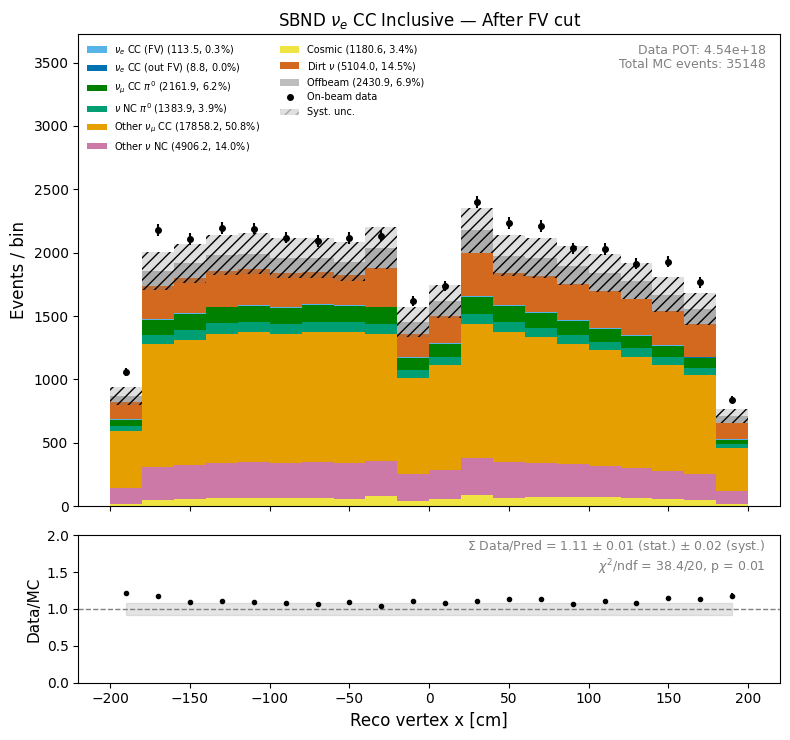

  After FV cut / Reco vertex y [cm]:
    Data/Pred = 1.107 ± 0.006 (stat.) ± 0.018 (syst.)
    chi2/ndf = 40.1/20  p = 0.005


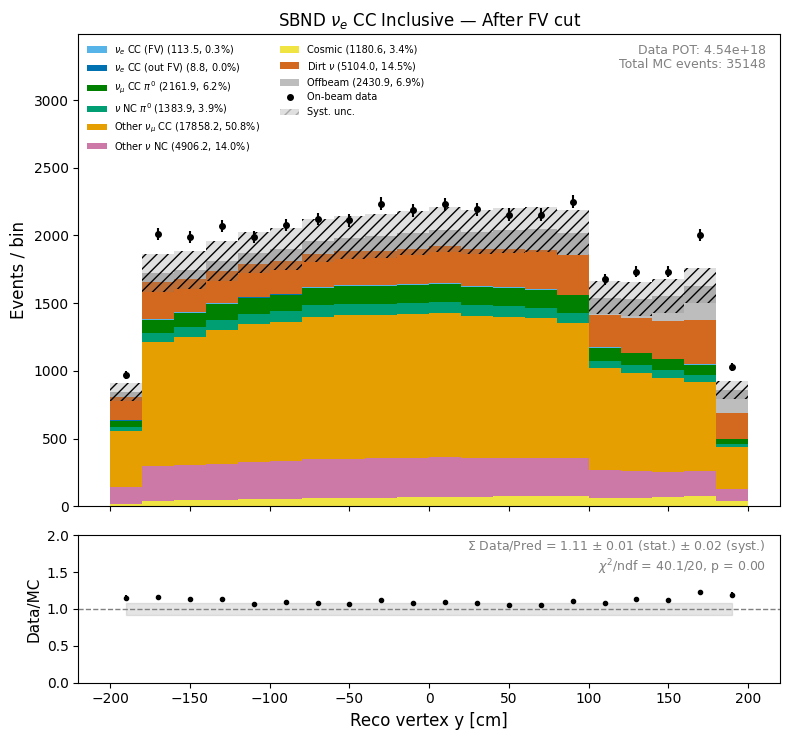

  After FV cut / Reco vertex z [cm]:
    Data/Pred = 1.107 ± 0.006 (stat.) ± 0.016 (syst.)
    chi2/ndf = 42.9/25  p = 0.014


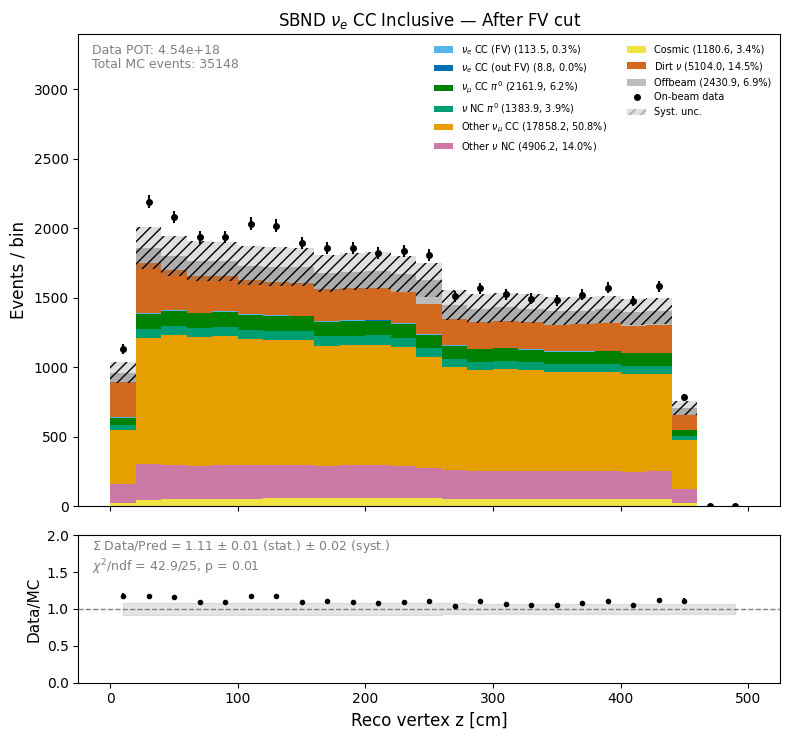

In [39]:
# ── Cell B: Vertex (FV stage) ─────────────────────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 1: Vertex (after FV cut)\n" + "="*70)
 
VCANDS = {
    'x': [('vertex','x',''),('vertex','x'),('vertex','I0',''),('vertex','I0')],
    'y': [('vertex','y',''),('vertex','y'),('vertex','I1',''),('vertex','I1')],
    'z': [('vertex','z',''),('vertex','z'),('vertex','I2',''),('vertex','I2')],
}
VBINS = {'x': np.linspace(-200,200,21),
         'y': np.linspace(-200,200,21),
         'z': np.linspace(0,500,26)}
VLBL  = {'x':'Reco vertex x [cm]',
         'y':'Reco vertex y [cm]',
         'z':'Reco vertex z [cm]'}
 
def _find_col(cols, cands):
    for cc in cands:
        if cc in cols: return cc
    for cc in cols:
        if isinstance(cc, tuple):
            for cand in cands:
                if isinstance(cand, tuple) and cand[0] in cc and cand[1] in cc:
                    return cc
    return None
 
ri_mc   = nh.reco_interactions(mc_evtdf_ub)._df.sort_index()
ri_data = nh.reco_interactions(data_evtdf_patched)._df.sort_index()
 
for coord in ['x', 'y', 'z']:
    mc_col   = _find_col(ri_mc.columns,   VCANDS[coord])
    data_col = _find_col(ri_data.columns, VCANDS[coord])
    if mc_col is None or data_col is None:
        print(f"  vertex {coord} not found"); continue
    mc_v   = ri_mc[mc_col].groupby(level=mc_il).first().reindex(MC_FV_IDX).dropna()
    data_v = ri_data[data_col].groupby(level=data_il_ub).first().reindex(DATA_FV_IDX).dropna()
    nh.plot_unblinding_var(
        mc_vals=mc_v,
        data_vals=data_v.values,
        truth_cat=truth_cat_fv,
        bins=VBINS[coord],
        xlabel=VLBL[coord],
        stage_name='After FV cut',
        pot_scale_data=pot_scale_to_data,
        data_pot=data_total_pot,
    
        frac_unc_per_bin=interp_frac_unc(VBINS[coord]),
    
        offbeam_vals=OFFBEAM_VERTEX.get(coord, np.array([])),
        offbeam_weight=offbeam_scale,
    
        dirt_vals=LOWE_VERTEX.get(coord, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
    
        savefig_fn=savefig,
        filename=f'vertex_{coord}_fv'
    )


STAGE 2: Multiplicity (after FV cut)
  After FV cut / N showers:
    Data/Pred = 1.107 ± 0.006 (stat.) ± 0.037 (syst.)
    chi2/ndf = 16.7/10  p = 0.081


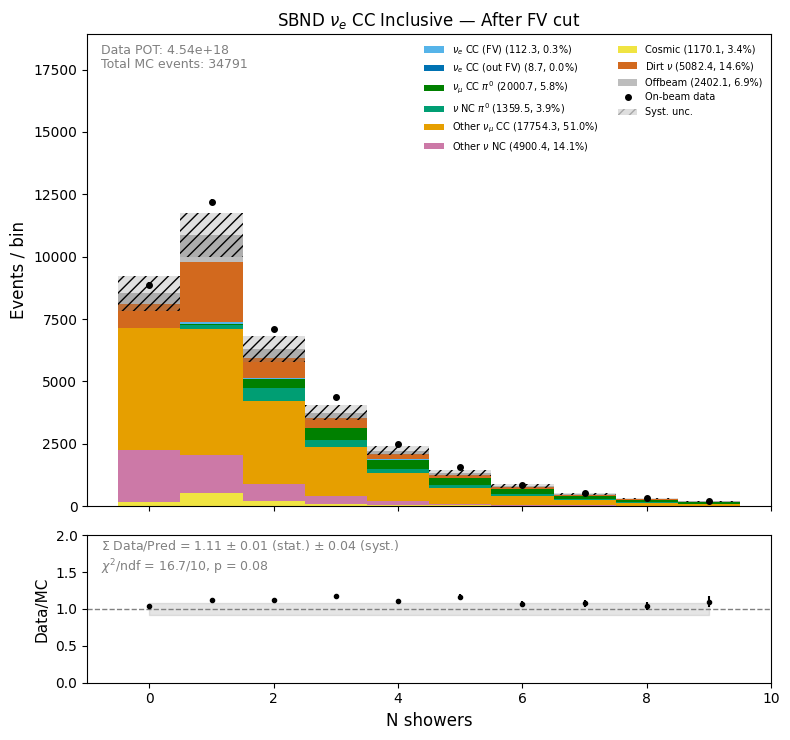

  After FV cut / N tracks:
    Data/Pred = 1.112 ± 0.006 (stat.) ± 0.036 (syst.)
    chi2/ndf = 52.1/10  p = 0.000


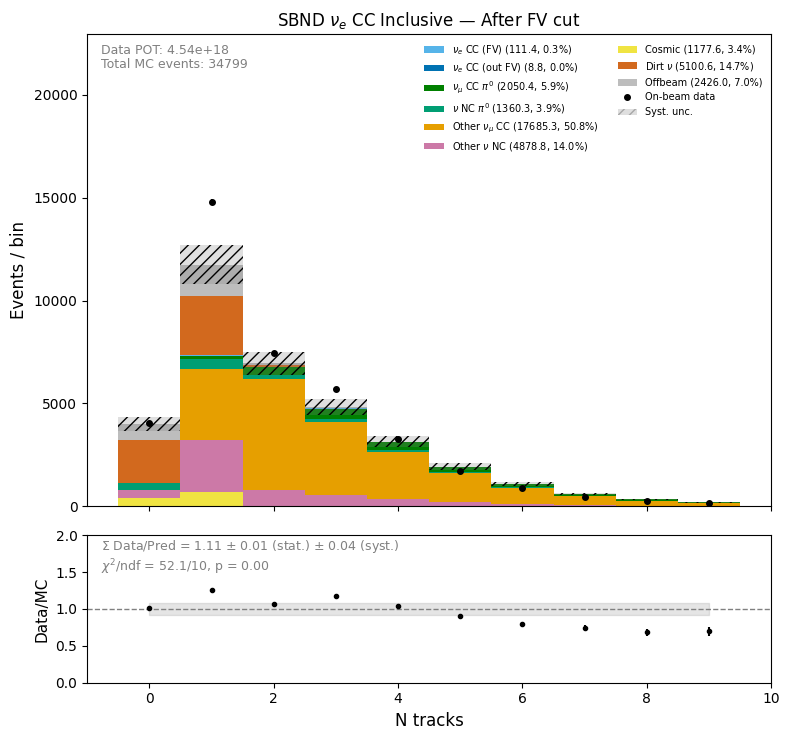

In [40]:
# ── Cell C: Multiplicity (FV stage) ──────────────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 2: Multiplicity (after FV cut)\n" + "="*70)

LOWE_MULT = {}

def _count_parts(evtdf, idx, il, ptype):
    rp      = nh.reco_particles(evtdf)._df
    pid_col = ('pid','') if ('pid','') in rp.columns else 'pid'
    parts   = rp[rp.index.droplevel(-1).isin(idx)]
    mask    = parts[pid_col].isin([0,1] if ptype == 'shower' else [2,3,4])
    return mask.groupby(level=il).sum().reindex(idx, fill_value=0)
    
for pt in ['shower','track']:
    LOWE_MULT[pt] = _count_parts(
        lowE_evtdf,
        lowE_cut_flow['fiducial']['inter_index'],
        lowE_il,
        pt
    ).values

 
bm = np.arange(-0.5, 10.5, 1)
for pt, xl in [('shower', 'N showers'), ('track', 'N tracks')]:
    mc_c   = _count_parts(mc_evtdf_ub,       MC_FV_IDX,   mc_il,      pt)
    data_c = _count_parts(data_evtdf_patched, DATA_FV_IDX, data_il_ub, pt)
    nh.plot_unblinding_var(
        mc_vals=mc_c, data_vals=data_c.values, truth_cat=truth_cat_fv,
        bins=bm, xlabel=xl, stage_name='After FV cut',
        pot_scale_data=pot_scale_to_data, data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bm),
        offbeam_vals=OFFBEAM_MULT.get(pt, np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_MULT.get(pt, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig, filename=f'mult_{pt}_fv')


STAGE 3: Shower quality (after topology cut)

  primary_scores: MC=69,929  Data=1,107
  After topology cut / Primary score:
    Data/Pred = 1.213 ± 0.036 (stat.) ± 0.065 (syst.)
    chi2/ndf = 16.7/20  p = 0.674


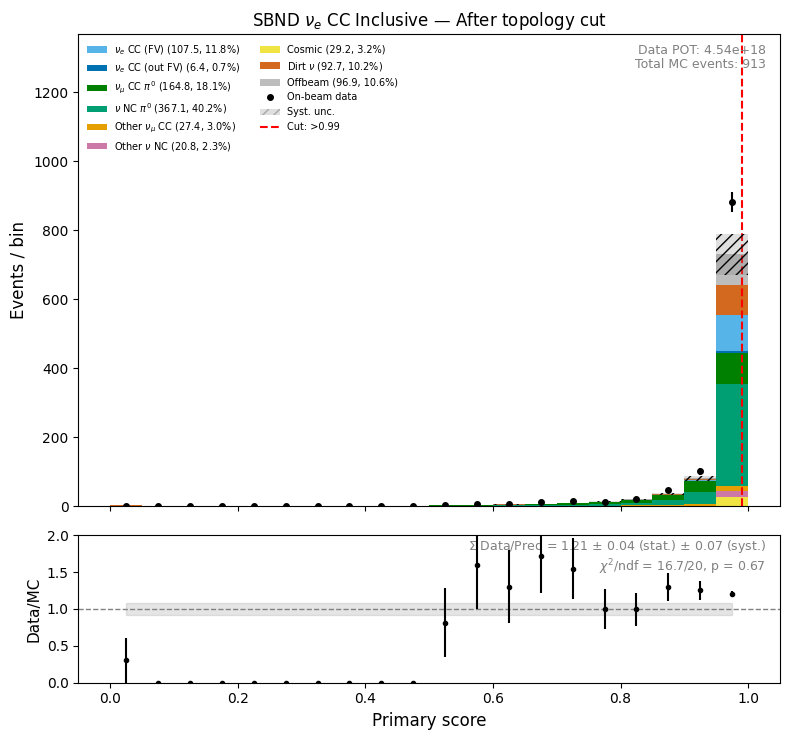


  pid_scores: MC=69,929  Data=1,107
  After topology cut / PID score:
    Data/Pred = 1.213 ± 0.036 (stat.) ± 0.026 (syst.)
    chi2/ndf = 23.6/20  p = 0.261


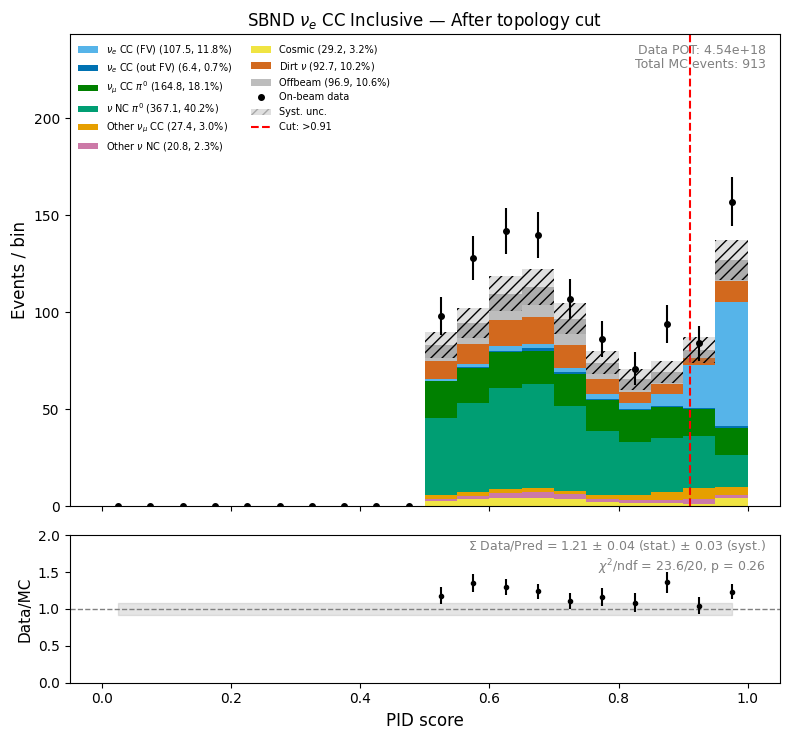


  vertex_distance: MC=69,929  Data=1,107
  After topology cut / Conversion gap [cm]:
    Data/Pred = 1.183 ± 0.039 (stat.) ± 0.049 (syst.)
    chi2/ndf = 26.9/20  p = 0.137


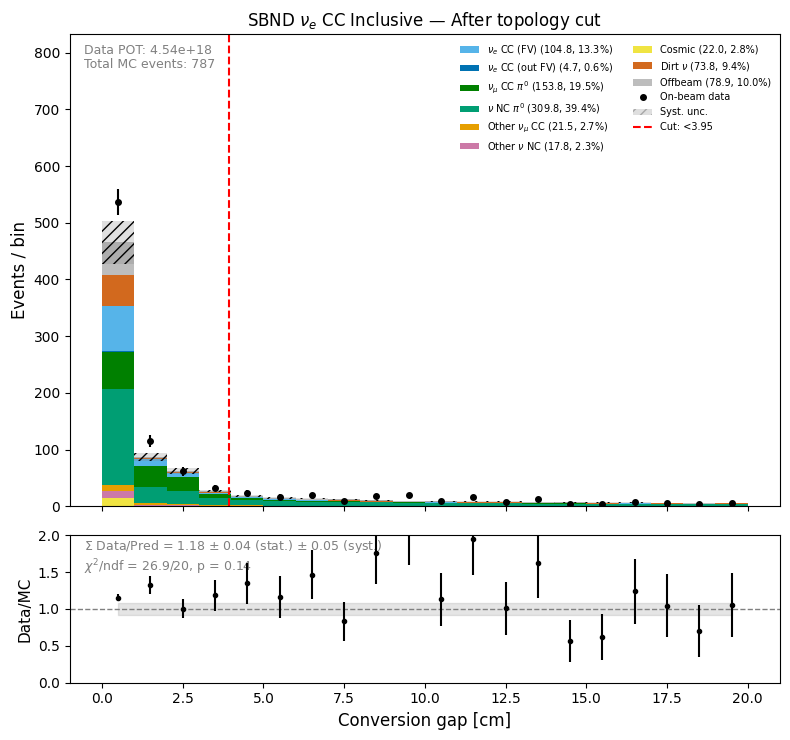


  start_dedx: MC=69,929  Data=1,107
  After topology cut / Start $dE/dx$ [MeV/cm]:
    Data/Pred = 1.237 ± 0.038 (stat.) ± 0.024 (syst.)
    chi2/ndf = 41.0/20  p = 0.004


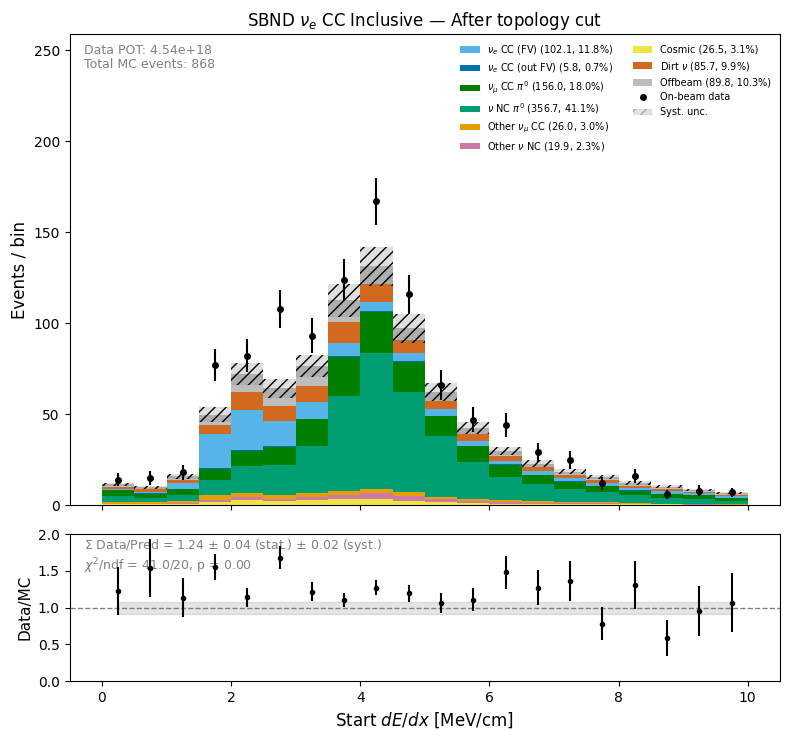


  calo_ke: MC=69,929  Data=1,107
  After topology cut / Calo KE [MeV]:
    Data/Pred = 1.220 ± 0.037 (stat.) ± 0.033 (syst.)
    chi2/ndf = 50.7/20  p = 0.000


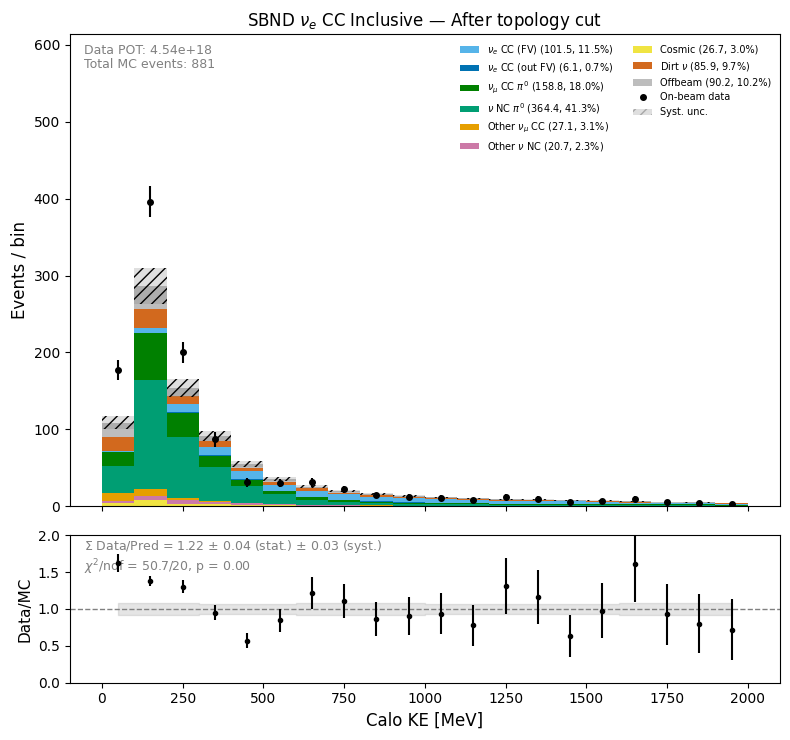

In [41]:
# ── Cell D: Shower quality (topology stage) ───────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 3: Shower quality (after topology cut)\n" + "="*70)
 
import nue_selection as nue_sel
 
SHOWER_VARS = [
    (('primary_scores','I1'), 'Primary score',          np.linspace(0,1,21),    nue_sel.THRESH_PRIMARY_SCORE, '>'),
    (('pid_scores','I1'),     'PID score',               np.linspace(0,1,21),    nue_sel.THRESH_PID_SCORE,     '>'),
    (('vertex_distance',''),  'Conversion gap [cm]',     np.linspace(0,20,21),   nue_sel.THRESH_VERTEX_DIST,   '<'),
    (('start_dedx',''),       r'Start $dE/dx$ [MeV/cm]', np.linspace(0,10,21),  None,                         None),
    (('calo_ke',''),          'Calo KE [MeV]',           np.linspace(0,2000,21), None,                         None),
]

LOWE_SHOWER_VARS = {}

for col_key, _, _, _, _ in SHOWER_VARS:
    vn = col_key[0]

    vals = nh._get_leading_electron_var(
        lowE_evtdf,
        col_key,
        lowE_topo_idx,
        lowE_il
    )

    LOWE_SHOWER_VARS[vn] = (
        vals.dropna().values
        if not vals.empty else np.array([])
    )
for col_key, xlabel, bins, cut_val, cut_dir in SHOWER_VARS:
    mc_var   = nh._get_leading_electron_var(mc_evtdf_ub,       col_key, MC_TOPO_IDX,   mc_il)
    data_var = nh._get_leading_electron_var(data_evtdf_patched, col_key, DATA_TOPO_IDX, data_il_ub)
    vn = col_key[0] if isinstance(col_key, tuple) else col_key
    nm, nd = mc_var.notna().sum(), data_var.notna().sum()
    print(f"\n  {vn}: MC={nm:,}  Data={nd:,}")
    if nm == 0: print("    Not found — skipping"); continue
    nh.plot_unblinding_var(
        mc_vals=mc_var,
        data_vals=data_var.dropna().values if nd > 0 else np.array([]),
        truth_cat=truth_cat_topo,
        bins=bins, xlabel=xlabel, stage_name='After topology cut',
        pot_scale_data=pot_scale_to_data, data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins),
        offbeam_vals=OFFBEAM_SHOWER_VARS.get(vn,np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_SHOWER_VARS.get(vn,np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig, filename=f'unblind_{vn}_topo',
        cut_val=cut_val, cut_dir=cut_dir)


STAGE 4: Kinematics (final selection, xsec bins)
  Final selection / Reco leading-$e^-$ KE [MeV]:
    Data/Pred = 1.141 ± 0.109 (stat.) ± 0.029 (syst.)
    chi2/ndf = 10.4/10  p = 0.402


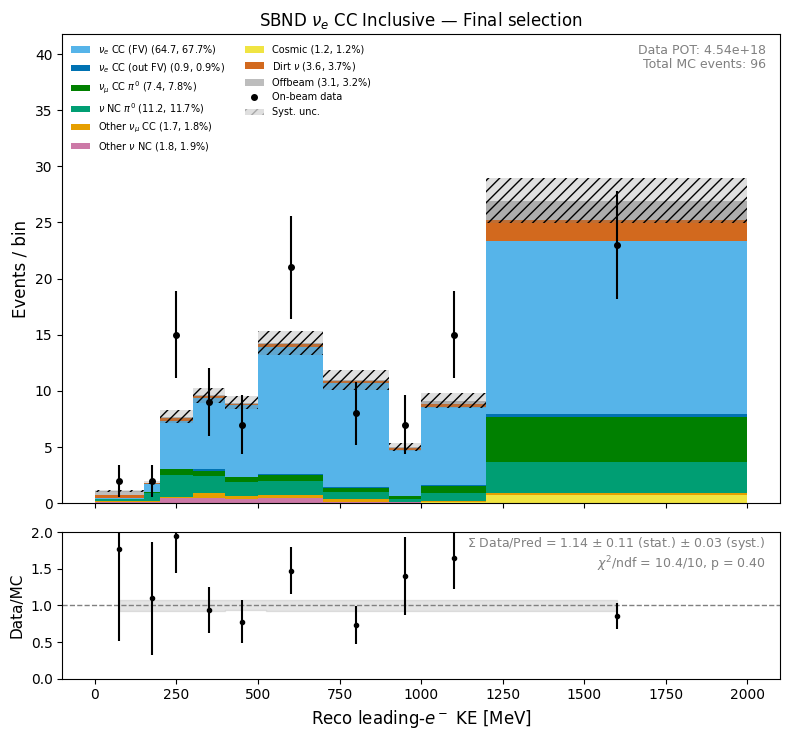

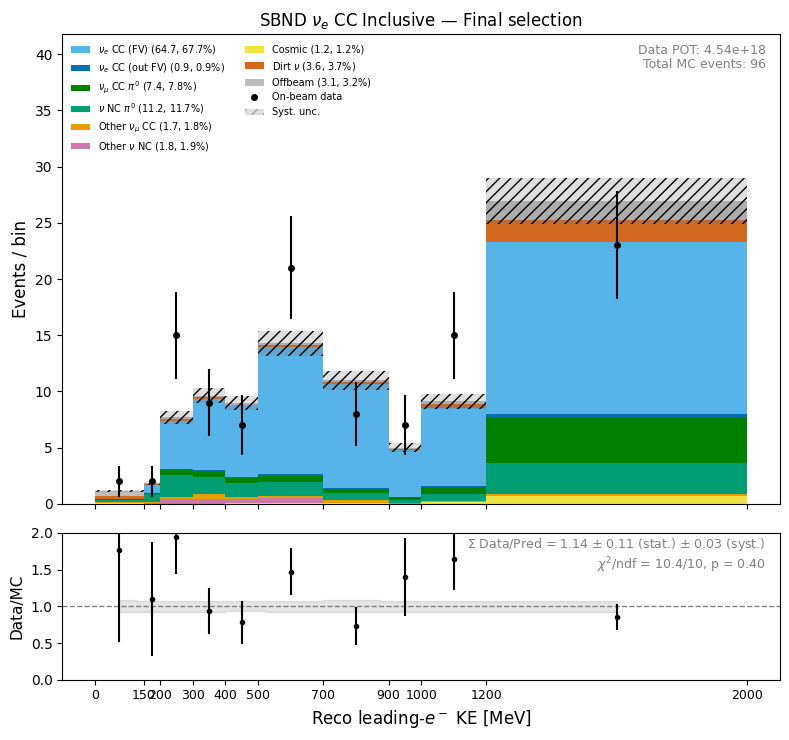

  Final selection / Reco leading-$e^-$ $\cos\theta$:
    Data/Pred = 1.124 ± 0.099 (stat.) ± 0.036 (syst.)
    chi2/ndf = 4.7/6  p = 0.580


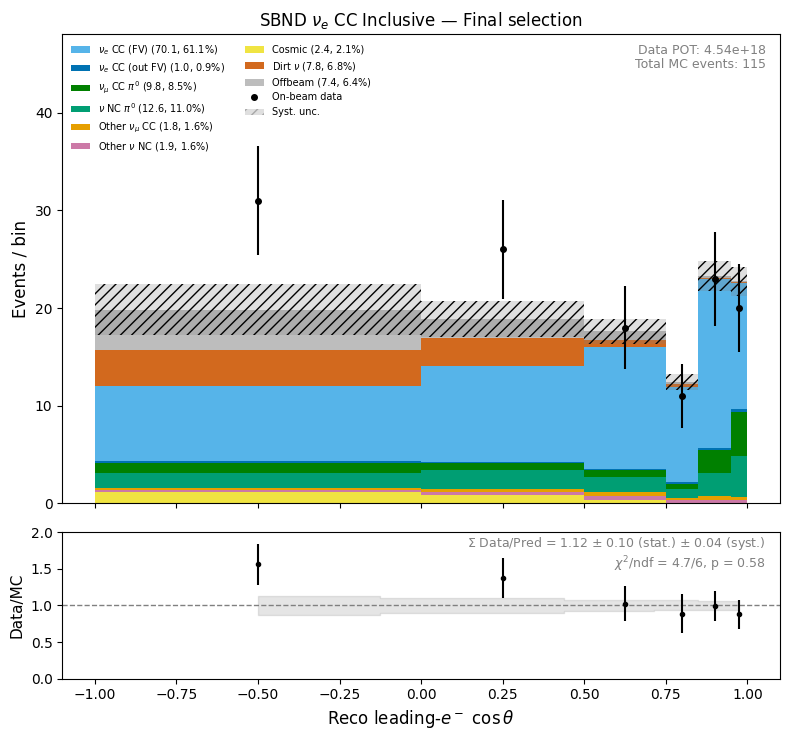

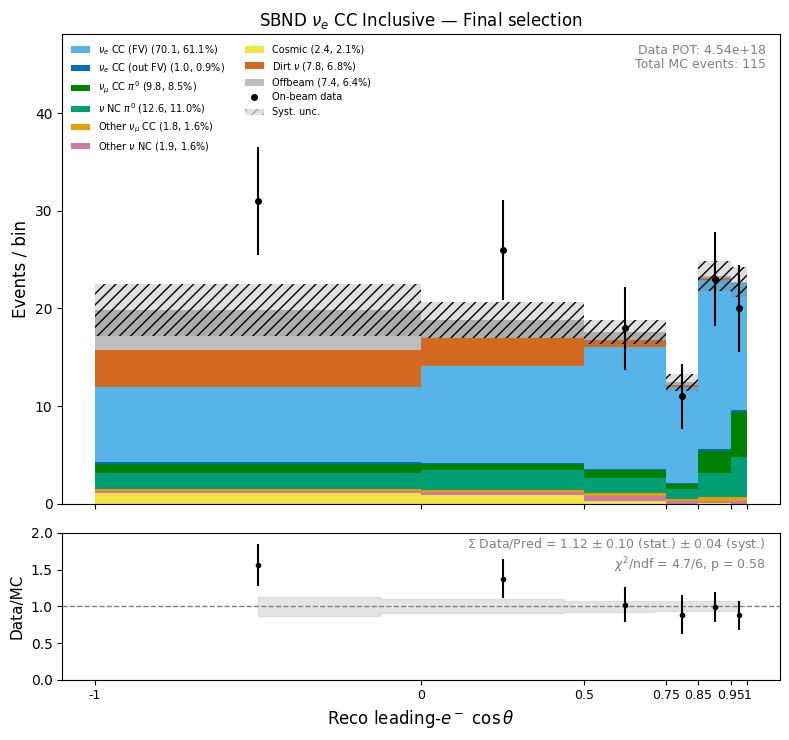

In [42]:
# ── Cell E: Kinematics (final selection) ──────────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 4: Kinematics (final selection, xsec bins)\n" + "="*70)
 
# Ensure xsec bins are defined explicitly (matches the CV xsec-bin cell)
from nue_xsec_helpers import make_nuecc_binning2d
_b2d_e = make_nuecc_binning2d()
_XSEC_KE_BINS  = np.unique(np.concatenate(_b2d_e.diff_momentum_bins_2d))
_XSEC_KE_BINS  = _XSEC_KE_BINS[_XSEC_KE_BINS <= 2000.0]
_XSEC_COS_BINS = _b2d_e.diff_costheta_bins.copy()
_XSEC_COS_BINS[-1] = 1.0
 
KINE_VARS_XSEC = [
    ('reco_ke',       r'Reco leading-$e^-$ KE [MeV]',     _XSEC_KE_BINS,  'reco_ke'),
    ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$',  _XSEC_COS_BINS, 'reco_costheta'),
]
 
for vn, xl, bins, proxy in KINE_VARS_XSEC:
    mc_var = sel_topo.loc[MC_FINAL_IDX, vn].dropna()
    fig = nh.plot_unblinding_var(
        mc_vals=mc_var,
        data_vals=DATA_RECO.get(vn, np.array([])),
        truth_cat=truth_cat_final,
        bins=bins,
        xlabel=xl,
        stage_name='Final selection',
        pot_scale_data=pot_scale_to_data,
        data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins, proxy),
        offbeam_vals=OFFBEAM_RECO.get(vn, np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_FINAL.get(vn, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig,
        filename=f'unblind_{vn}_final_xsecbins')
 
    # Set tick marks at every bin edge
    if fig is not None:
        for ax in fig.get_axes():
            ax.set_xticks(bins)
            ax.set_xticklabels(
                [f'{int(b)}' if b == int(b) else f'{b:.3g}' for b in bins],
                fontsize=9)
        fig.tight_layout()
        savefig(fig, f'unblind_{vn}_final_xsecbins')


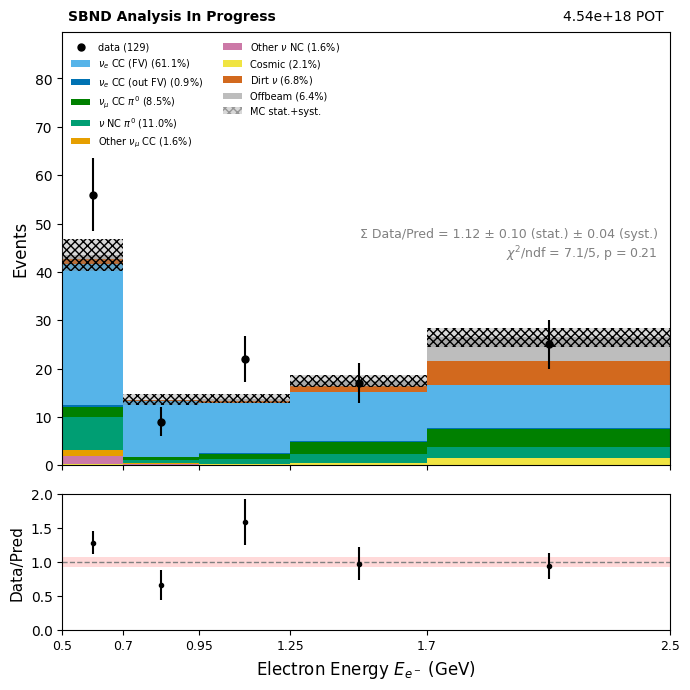

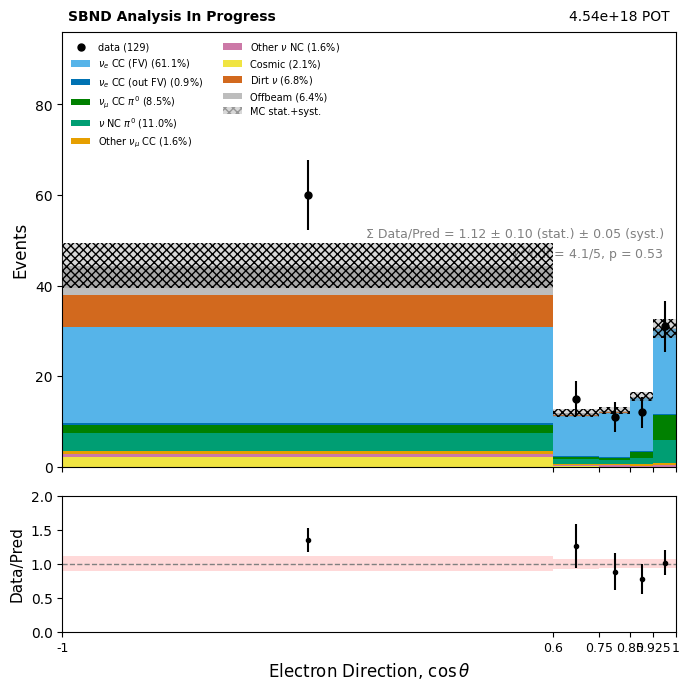

Lynn-style comparison plots saved to plots_syst/lynn_comparison/


In [43]:
# ── CELL: Lynn binning comparison ────────────────────────────────────────────
# %%
from nue_plotter import plot_lynn_comparison, LYNN_KE_BINS_MEV, LYNN_COS_BINS
 
def savefig(fig, name, sub=''):
    d = os.path.join(PLOT_DIR, sub) if sub else PLOT_DIR
    os.makedirs(d, exist_ok=True)
    fig.savefig(os.path.join(d, f'{name}.png'), dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)
 
# Fractional syst for the Lynn bins
def get_total_frac_unc(var_name):
    cv = cv_results[var_name]; covs_var = cov_results[var_name]
    vs = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
    vb = sum(np.diag(_mat(covs_var[s]['cov_bs_bs'])).clip(0) for s in covs_var)
    tmc = cv['sig_cv'] + cv['bkg_cv']
    frac = np.where(tmc > 0, np.sqrt((vs+vb).clip(0)) / tmc, 0.0)
    vcfg = next(v for v in VAR_CFGS if v.name == var_name)
    return vcfg.bin_centers, frac
 
cov_centers_ke,  frac_unc_ke  = get_total_frac_unc('reco_ke')
cov_centers_cos, frac_unc_cos = get_total_frac_unc('reco_costheta')
 
# Interpolate frac unc onto Lynn bins
def lynn_frac_unc(var_name):
    if var_name == 'reco_ke':
        bins = LYNN_KE_BINS_MEV
        centers = 0.5 * (bins[:-1] + bins[1:])
        return np.interp(centers, cov_centers_ke, frac_unc_ke,
                         left=frac_unc_ke[0], right=frac_unc_ke[-1])
    else:
        bins = LYNN_COS_BINS
        centers = 0.5 * (bins[:-1] + bins[1:])
        return np.interp(centers, cov_centers_cos, frac_unc_cos,
                         left=frac_unc_cos[0], right=frac_unc_cos[-1])
 
# ── KE plot ──────────────────────────────────────────────────────────────────
fig_ke = plot_lynn_comparison(
    sel_topo, FINAL_STAGE, 'reco_ke',
    pot_scale_data=pot_scale_to_data,
    data_pot=data_total_pot,
    data_reco=DATA_RECO,
    offbeam_reco=OFFBEAM_RECO, offbeam_weight=offbeam_scale,
    dirt_reco=LOWE_RECO_FINAL, dirt_weight=lowE_pot_scale_to_data,
    frac_unc_per_bin=lynn_frac_unc('reco_ke'),
    savefig_fn=savefig,
    filename='lynn_reco_ke')
 
# ── cosθ plot ────────────────────────────────────────────────────────────────
fig_cos = plot_lynn_comparison(
    sel_topo, FINAL_STAGE, 'reco_costheta',
    pot_scale_data=pot_scale_to_data,
    data_pot=data_total_pot,
    data_reco=DATA_RECO,
    offbeam_reco=OFFBEAM_RECO, offbeam_weight=offbeam_scale,
    dirt_reco=LOWE_RECO_FINAL, dirt_weight=lowE_pot_scale_to_data,
    frac_unc_per_bin=lynn_frac_unc('reco_costheta'),
    savefig_fn=savefig,
    filename='lynn_reco_costheta')
 
print('Lynn-style comparison plots saved to plots_syst/lynn_comparison/')


## 15. Sideband selection

In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL F: Sideband selection
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70 + "\nSIDEBAND SELECTION\n" + "="*70)
 
_SB_THRESH_VD    = nue_sel.THRESH_VERTEX_DIST
_SB_THRESH_PID   = nue_sel.THRESH_PID_SCORE
_SB_THRESH_DX_LO = nue_sel.THRESH_SB_DEDX_LO
_SB_THRESH_DX_HI = nue_sel.THRESH_SB_DEDX_HI
 
def build_sideband_idx(evtdf, topo_idx, il):
    rp   = nh.reco_particles(evtdf)._df
    ke_c = ('ke','')  if ('ke','')  in rp.columns else 'ke'
    pi_c = ('pid','') if ('pid','') in rp.columns else 'pid'
    ele  = rp[rp.index.droplevel(-1).isin(topo_idx) & (rp[pi_c]==1)]
    if ele.empty: return pd.Index([])
    li  = ele[ke_c].groupby(level=il).idxmax().dropna()
    if li.empty: return pd.Index([])
    lmi = pd.MultiIndex.from_tuples(li.values, names=ele.index.names)
    ld  = ele.loc[lmi].copy(); ld.index = li.index
    vd_c, ps_c, dx_c = ('vertex_distance',''), ('pid_scores','I1'), ('start_dedx','')
    sb = pd.Series(True, index=ld.index)
    if vd_c in ld.columns:
        sb &= (ld[vd_c] > _SB_THRESH_VD)
    else:
        print("  WARNING: vertex_distance not found")
    if ps_c in ld.columns:
        sb &= (ld[ps_c] < _SB_THRESH_PID)
    else:
        print("  WARNING: pid_scores not found")
    if dx_c in ld.columns:
        sb &= (ld[dx_c] > _SB_THRESH_DX_LO) & (ld[dx_c] < _SB_THRESH_DX_HI)
    else:
        print("  WARNING: start_dedx not found — dE/dx cut skipped")
    return ld.index[sb]
 
MC_SB_IDX   = build_sideband_idx(mc_evtdf_ub, MC_TOPO_IDX, mc_il)
DATA_SB_IDX = build_sideband_idx(data_evtdf_patched, DATA_TOPO_IDX, data_il_ub)
LOWE_SB_IDX = build_sideband_idx(lowE_evtdf,lowE_topo_idx,lowE_il)
truth_cat_sb = sel_topo.loc[MC_SB_IDX, 'truth_cat']
 
print(f"Sideband: MC={len(MC_SB_IDX):,}  Data={len(DATA_SB_IDX):,}")
_cn = {0:"νe CC FV",1:"νe CC out-FV",2:"νμ CC π0",3:"NC π0",
       4:"other νμ CC",5:"other NC",6:"cosmic"}
_ns = len(MC_SB_IDX)
for cat in [0,1,2,3,4,5,6]:
    n = (truth_cat_sb==cat).sum()
    if _ns>0: print(f"  cat {cat} ({_cn.get(cat,'?'):<16s}): {n:>6,}  ({n/_ns*100:.1f}%)")
print(f"  Signal contamination: {(truth_cat_sb==0).sum()/_ns*100:.1f}%" if _ns>0 else "")
 
rp_sb = nh.reco_particles(data_evtdf_patched)._df
_kc = ('ke','') if ('ke','') in rp_sb.columns else 'ke'
_pc = ('pid','') if ('pid','') in rp_sb.columns else 'pid'
_cc = ('calo_ke','') if ('calo_ke','') in rp_sb.columns else 'calo_ke'
_esb = rp_sb[rp_sb.index.droplevel(-1).isin(DATA_SB_IDX) & (rp_sb[_pc]==1)]
DATA_SB_RECO = {}
if not _esb.empty:
    _ks = _esb[_cc] if _cc in _esb.columns else _esb[_kc]
    _li = _ks.groupby(level=data_il_ub).idxmax().dropna()
    if not _li.empty:
        _lmi = pd.MultiIndex.from_tuples(_li.values, names=_esb.index.names)
        _ld  = _esb.loc[_lmi].copy(); _ld.index = _li.index
        DATA_SB_RECO['reco_ke'] = _ld[_cc if _cc in _ld.columns else _kc].dropna().values
        _m_e = 0.511
        DATA_SB_RECO['reco_p'] = np.sqrt(((DATA_SB_RECO['reco_ke']+_m_e)**2 - _m_e**2).clip(0))
        try:
            dx=[c for c in rp_sb.columns if 'start_dir' in str(c) and 'I0' in str(c)][0]
            dy=[c for c in rp_sb.columns if 'start_dir' in str(c) and 'I1' in str(c)][0]
            dz=[c for c in rp_sb.columns if 'start_dir' in str(c) and 'I2' in str(c)][0]
            dd=_esb.loc[_lmi,[dx,dy,dz]].copy(); dd.index=_li.index
            pm=np.sqrt(dd[dx]**2+dd[dy]**2+dd[dz]**2).replace(0,np.nan)
            DATA_SB_RECO['reco_costheta']=(dd[dz]/pm).dropna().values
        except: DATA_SB_RECO['reco_costheta']=np.array([])
print(f"Data sideband: KE={len(DATA_SB_RECO.get('reco_ke',[])):,}, "
      f"cos={len(DATA_SB_RECO.get('reco_costheta',[])):,}")


SIDEBAND SELECTION
Sideband: MC=12,275  Data=198
  cat 0 (νe CC FV        ):     83  (0.7%)
  cat 1 (νe CC out-FV    ):    116  (0.9%)
  cat 2 (νμ CC π0        ):  1,154  (9.4%)
  cat 3 (NC π0           ):  8,166  (66.5%)
  cat 4 (other νμ CC     ):    270  (2.2%)
  cat 5 (other NC        ):    297  (2.4%)
  cat 6 (cosmic          ):    470  (3.8%)
  Signal contamination: 0.7%
Data sideband: KE=198, cos=198


In [49]:
# ── Dirt (lowE) sideband reco ─────────────────────────────────────────────────
# LOWE_SB_IDX was just built above by build_sideband_idx.
# Now extract the reco observables and shower variables for it.

lowE_evtdf      = load_evtdf_slim(LOWE_FILE, key=None, mode="reco_min_true")
lowE_truth_info = _load_hdf_key(LOWE_FILE, 'truth_info')

lowE_final_stage = FINAL_STAGE.replace('sel_', '')
lowE_final_idx   = lowE_cut_flow[lowE_final_stage]['inter_index']
lowE_topo_idx    = lowE_cut_flow['single_electron']['inter_index']

lowE_reco_ke  = nue_sel.leading_electron_ke(lowE_evtdf)
lowE_reco_cos = nue_sel.leading_electron_costheta(lowE_evtdf)
lowE_reco_p   = nue_sel.leading_electron_p(lowE_evtdf)

# Build lowE_sel (mini sel_topo, used by build_univ_hists)
lowE_presel_inter = lowE_evtdf.groupby(level=lowE_il).size().index
lowE_truth_cat    = lowE_truth_info['truth_cat'].reindex(lowE_presel_inter)

lowE_sel = pd.DataFrame(index=lowE_presel_inter)
lowE_sel['truth_cat']     = lowE_truth_cat.fillna(7).astype('int8')
lowE_sel['is_sig']        = (lowE_sel['truth_cat'] == 0)
lowE_sel['reco_ke']       = lowE_reco_ke.reindex(lowE_presel_inter).astype('float32')
lowE_sel['reco_costheta'] = lowE_reco_cos.reindex(lowE_presel_inter).astype('float32')
lowE_sel['reco_p']        = lowE_reco_p.reindex(lowE_presel_inter).astype('float32')
for stage_name in lowE_cut_flow:
    lowE_sel[f'sel_{stage_name}'] = lowE_presel_inter.isin(
        lowE_cut_flow[stage_name]['inter_index'])
lowE_sel['pot_scale'] = np.float32(lowE_pot_scale)

def _build_reco_dict(reco_ke, reco_cos, reco_p, idx):
    """Build reco dict by reindexing pre-computed Series to idx."""
    return {
        'reco_ke':       reco_ke.reindex(idx).dropna().values,
        'reco_costheta': reco_cos.reindex(idx).dropna().values,
        'reco_p':        reco_p.reindex(idx).dropna().values,
    }

LOWE_RECO_FINAL = _build_reco_dict(lowE_reco_ke, lowE_reco_cos, lowE_reco_p, lowE_final_idx)
LOWE_RECO_TOPO  = _build_reco_dict(lowE_reco_ke, lowE_reco_cos, lowE_reco_p, lowE_topo_idx)

LOWE_SB_RECO = _build_reco_dict(lowE_reco_ke, lowE_reco_cos, lowE_reco_p, LOWE_SB_IDX)

LOWE_SB_SHOWER_VARS = {}
for col_key in [('primary_scores','I1'), ('pid_scores','I1'),
                ('vertex_distance',''), ('start_dedx',''), ('calo_ke','')]:
    vals = nh._get_leading_electron_var(lowE_evtdf, col_key, LOWE_SB_IDX, lowE_il)
    LOWE_SB_SHOWER_VARS[col_key[0]] = vals.dropna().values if not vals.empty else np.array([])

print(f'\nDirt sideband: {len(LOWE_SB_IDX):,} interactions')
print(f'  KE={len(LOWE_SB_RECO.get("reco_ke",[])):,}  '
      f'cos={len(LOWE_SB_RECO.get("reco_costheta",[])):,}')
for vn, arr in LOWE_SB_SHOWER_VARS.items():
    print(f'  {vn}: {len(arr):,}')


load_evtdf_slim  mode='reco_min_true'  key='/evt_0'
  Total cols :  393  →  kept:  124  dropped:  269  (68% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction              68      0  ← dropped 68
  dlp_true_particle                113     16  ← dropped 97
  mcnu                             104      0  ← dropped 104
  index_artifact                     4      4
  other                              0      0

  Post-drop complete. Final shape: (857988, 124)

Dirt sideband: 1,178 interactions
  KE=1,178  cos=1,178
  primary_scores: 1,178
  pid_scores: 1,178
  vertex_distance: 1,178
  start_dedx: 1,178
  calo_ke: 1,178



SIDEBAND PLOTS
  Sideband (photon-enriched) / Reco leading-$e^-$ KE [MeV]:
    Data/Pred = 1.247 ± 0.089 (stat.) ± 0.035 (syst.)
    chi2/ndf = 32.9/10  p = 0.000


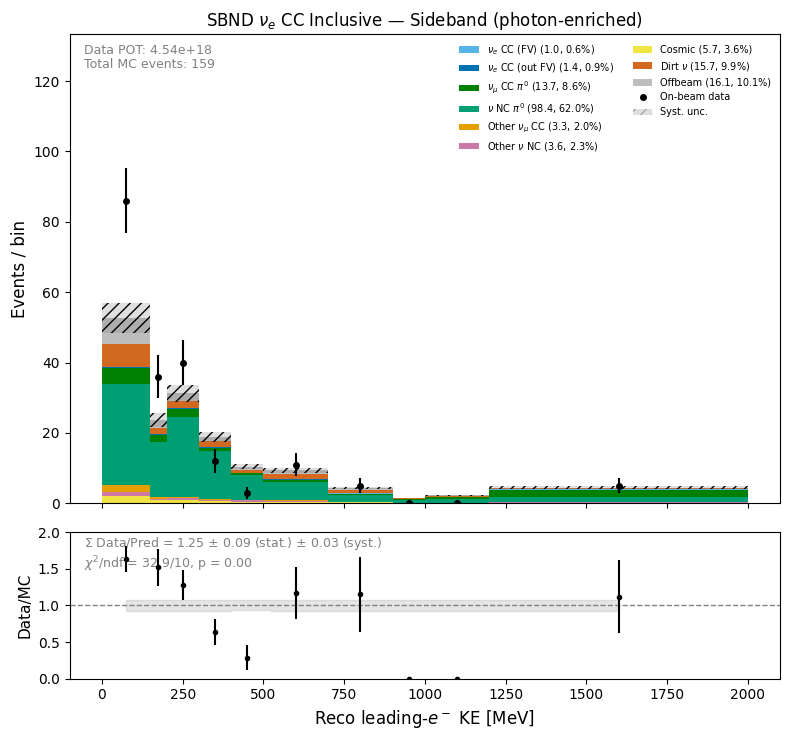

  Sideband (photon-enriched) / Reco leading-$e^-$ $\cos\theta$:
    Data/Pred = 1.245 ± 0.088 (stat.) ± 0.046 (syst.)
    chi2/ndf = 10.3/6  p = 0.113


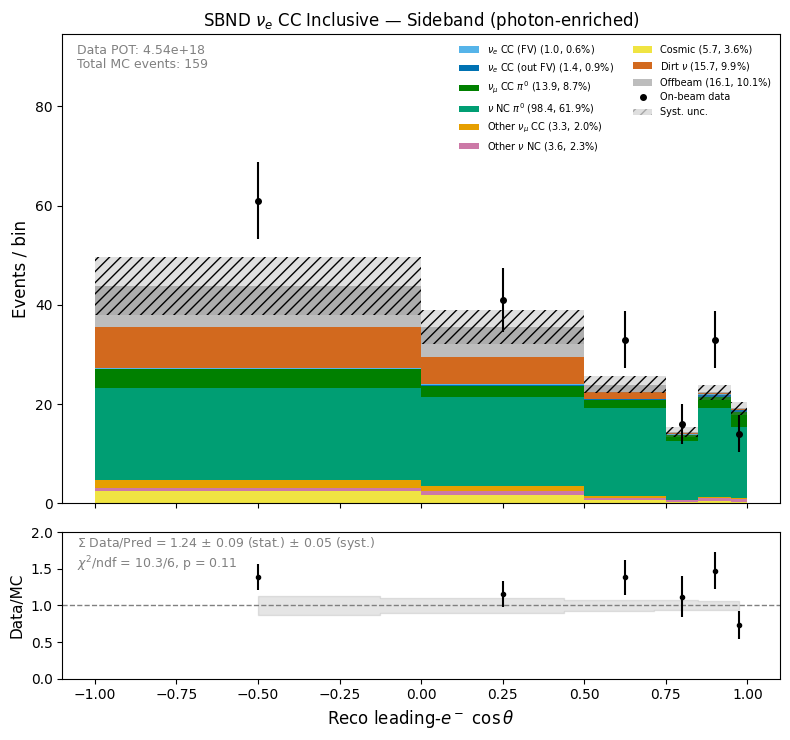


Sideband shower variables:
  primary_scores: MC=12,275  Data=198  Dirt(SB)=1,178
  Sideband / Primary score:
    Data/Pred = 1.245 ± 0.088 (stat.) ± 0.070 (syst.)
    chi2/ndf = 7.4/20  p = 0.995


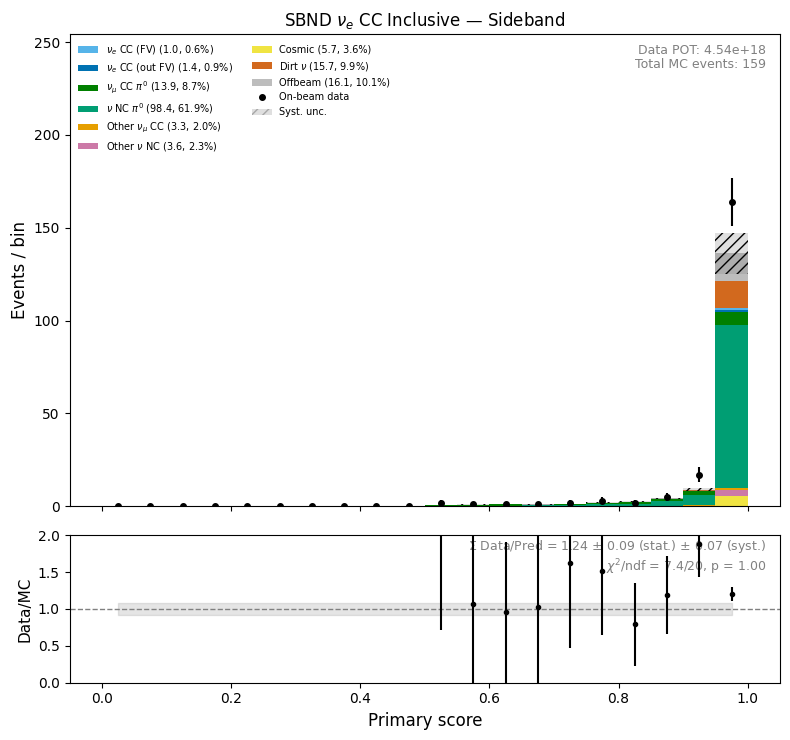

  pid_scores: MC=12,275  Data=198  Dirt(SB)=1,178
  Sideband / PID score:
    Data/Pred = 1.245 ± 0.088 (stat.) ± 0.031 (syst.)
    chi2/ndf = 14.7/20  p = 0.794


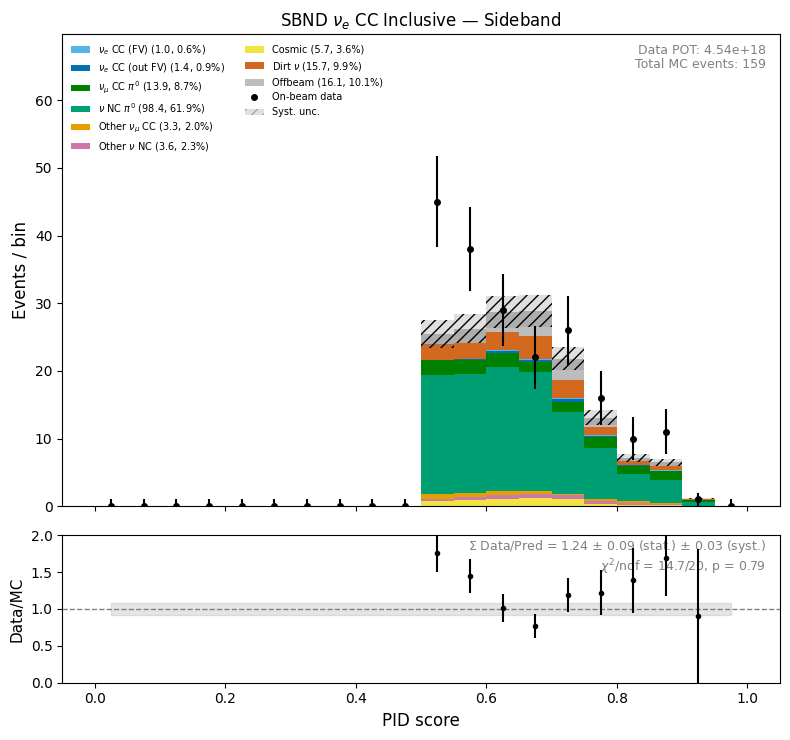

  vertex_distance: MC=12,275  Data=198  Dirt(SB)=1,178
  Sideband / Conversion gap [cm]:
    Data/Pred = 1.182 ± 0.118 (stat.) ± 0.021 (syst.)
    chi2/ndf = 22.3/20  p = 0.327


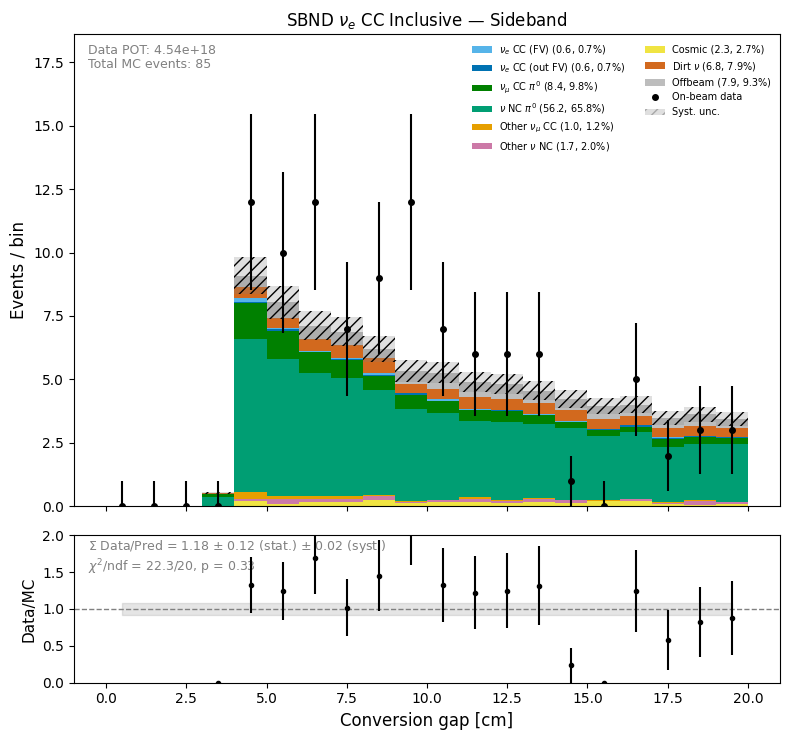

  start_dedx: MC=12,275  Data=198  Dirt(SB)=1,178
  Sideband / Start $dE/dx$ [MeV/cm]:
    Data/Pred = 1.245 ± 0.088 (stat.) ± 0.036 (syst.)
    chi2/ndf = 7.1/20  p = 0.996


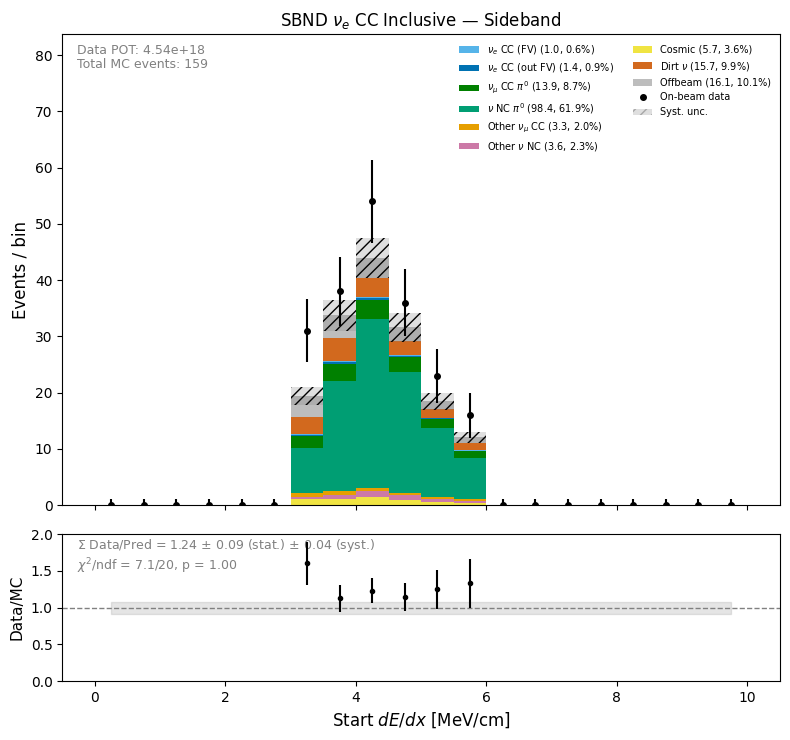

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# CELLS G-H: Sideband plots + chi2 summary
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70 + "\nSIDEBAND PLOTS\n" + "="*70)

# ── Kinematic variables ──────────────────────────────────────────────────────
for vn, xl, bins, proxy in KINE_VARS:
    mc_v = sel_topo.loc[MC_SB_IDX, vn].dropna()
    nh.plot_unblinding_var(
        mc_vals=mc_v,
        data_vals=DATA_SB_RECO.get(vn, np.array([])),
        truth_cat=truth_cat_sb,
        bins=bins,
        xlabel=xl,
        stage_name='Sideband (photon-enriched)',
        pot_scale_data=pot_scale_to_data,
        data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins, proxy),
        # ── FIX: use sideband-filtered offbeam and dirt ──
        offbeam_vals=OFFBEAM_SB_RECO.get(vn, np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_SB_RECO.get(vn, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig,
        filename=f'sideband_{vn}',
        save_subdir='sideband')

# ── Shower quality variables ─────────────────────────────────────────────────
SB_SHOWER = [
    (('primary_scores','I1'), 'Primary score',          np.linspace(0,1,21)),
    (('pid_scores','I1'),     'PID score',               np.linspace(0,1,21)),
    (('vertex_distance',''),  'Conversion gap [cm]',     np.linspace(0,20,21)),
    (('start_dedx',''),       r'Start $dE/dx$ [MeV/cm]', np.linspace(0,10,21)),
]

print("\nSideband shower variables:")
for col_key, xl, bins in SB_SHOWER:
    mc_v  = nh._get_leading_electron_var(mc_evtdf_ub,        col_key, MC_SB_IDX,   mc_il)
    dat_v = nh._get_leading_electron_var(data_evtdf_patched,  col_key, DATA_SB_IDX, data_il_ub)
    vn = col_key[0]

    # ── FIX: dirt shower vars from sideband, not topology ──
    dirt_arr = LOWE_SB_SHOWER_VARS.get(vn, np.array([]))

    nm = mc_v.notna().sum()
    nd = dat_v.notna().sum()
    nlow = len(dirt_arr)

    print(f"  {vn}: MC={nm:,}  Data={nd:,}  Dirt(SB)={nlow:,}")
    if nm == 0:
        print("    Not found — skipping")
        continue

    nh.plot_unblinding_var(
        mc_vals=mc_v,
        data_vals=dat_v.dropna().values if nd > 0 else np.array([]),
        truth_cat=truth_cat_sb,
        bins=bins,
        xlabel=xl,
        stage_name='Sideband',
        pot_scale_data=pot_scale_to_data,
        data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins),
        # ── FIX: use sideband-filtered offbeam and dirt ──
        offbeam_vals=OFFBEAM_SB_SHOWER_VARS.get(vn, np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=dirt_arr,
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig,
        filename=f'sideband_{vn}',
        save_subdir='sideband')

In [51]:
# chi2 summary
print("\n" + "="*70 + "\nCHI2 SUMMARY (stat+syst+offbeam)\n" + "="*70)
 
def _chi2_row(label, mc_s, da, tcat, ba, fa,
              ob_vals=None, ob_w=None,
              dirt_vals=None, dirt_w=None):

    ba = np.asarray(ba)
    tmc = np.zeros(len(ba)-1)

    for c in [0,1,2,3,4,5,6]:
        cv = nh._by_cat_generic(mc_s, tcat, c)
        v,_ = np.histogram(
            cv, bins=ba,
            weights=np.full(len(cv), pot_scale_to_data))
        tmc += v

    extra_stat = np.zeros(len(ba)-1)

    if dirt_vals is not None and dirt_w is not None:
        dh,_ = np.histogram(
            dirt_vals,
            bins=ba,
            weights=np.full(len(dirt_vals), dirt_w))
        tmc += dh

    ob_h = np.zeros(len(ba)-1)

    if ob_vals is not None and ob_w is not None and len(ob_vals)>0:
        ob_h,_ = np.histogram(
            ob_vals,
            bins=ba,
            weights=np.full(len(ob_vals), ob_w))
        tmc += ob_h

    if da is None or len(da)==0:
        return label,'-','-','-'

    dc,_ = np.histogram(da,bins=ba)
    dcf = dc.astype(float)

    cov = np.diag(np.where(dcf>0,dcf,1.0))
    cov += np.diag(ob_h)

    if fa is not None:
        cov += np.diag((fa*tmc)**2)

    c2,nd,pv = nh.chi2_pvalue(dcf,tmc,cov_matrix=cov)

    dp = dcf.sum()/tmc.sum() if tmc.sum()>0 else 0

    return label,f'{dp:.3f}',f'{c2:.1f}/{nd}',f'{pv:.3f}'
 
h = f"{'Region / Variable':<45s} {'Data/Pred':>10s} {'chi2/ndf':>12s} {'p':>8s}"
print(h); print("-"*len(h))

for vn, xl, bins, proxy in KINE_VARS:
    # Signal region
    r = _chi2_row(
        f'Signal / {vn}',
        sel_topo.loc[MC_FINAL_IDX, vn].dropna(),
        DATA_RECO.get(vn, np.array([])),
        truth_cat_final, bins,
        interp_frac_unc(bins, proxy),
        OFFBEAM_RECO.get(vn, np.array([])), offbeam_scale,
        LOWE_RECO_FINAL.get(vn, np.array([])), lowE_pot_scale_to_data)
    print(f"  {r[0]:<43s} {r[1]:>10s} {r[2]:>12s} {r[3]:>8s}")

for vn, xl, bins, proxy in KINE_VARS:
    # Sideband — FIX: use sideband-filtered offbeam and dirt
    r = _chi2_row(
        f'Sideband / {vn}',
        sel_topo.loc[MC_SB_IDX, vn].dropna(),
        DATA_SB_RECO.get(vn, np.array([])),
        truth_cat_sb, bins,
        interp_frac_unc(bins, proxy),
        OFFBEAM_SB_RECO.get(vn, np.array([])), offbeam_scale,
        LOWE_SB_RECO.get(vn, np.array([])), lowE_pot_scale_to_data)
    print(f"  {r[0]:<43s} {r[1]:>10s} {r[2]:>12s} {r[3]:>8s}")

print("=" * len(h))


CHI2 SUMMARY (stat+syst+offbeam)
Region / Variable                              Data/Pred     chi2/ndf        p
------------------------------------------------------------------------------
  Signal / reco_ke                                 1.141      10.7/10    0.385
  Signal / reco_costheta                           1.124        5.1/6    0.531
  Sideband / reco_ke                               1.247      37.2/10    0.000
  Sideband / reco_costheta                         1.245       10.7/6    0.099


## 16. MC/data comparison

In [52]:
import nue_helpers as nh
 
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6, 9, 7]
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]
 
DISP_KE_BINS  = np.linspace(0, 2000, 13)
DISP_COS_BINS = np.linspace(-1, 1,   13)
DISP_BINS = {'reco_ke': DISP_KE_BINS, 'reco_costheta': DISP_COS_BINS}
 
def _frac_unc_sig(var_name, disp_bins):
    cv = cv_results[var_name]
    covs_var = cov_results[var_name]
    total_var_sig = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
    frac_cv = np.where(cv['sig_cv'] > 0,
                       np.sqrt(total_var_sig.clip(0)) / cv['sig_cv'], 0.0)
    vcfg = next(v for v in VAR_CFGS if v.name == var_name)
    return np.interp(0.5*(disp_bins[:-1]+disp_bins[1:]), vcfg.bin_centers, frac_cv)
 
def _add_offbeam(series_list, weights_list, ob_vals, ob_w):
    """Append offbeam as category 7 to series/weights lists in-place."""
    ob = np.asarray(ob_vals if ob_vals is not None else [], dtype=float)
    ob = ob[~np.isnan(ob)]
    series_list.append(ob)
    weights_list.append(np.full(len(ob), ob_w))
 
 
def _total_with_offbeam(series_list, weights_list, bins):
    total = np.zeros(len(bins)-1)
    for s, w in zip(series_list, weights_list):
        v, _ = np.histogram(s, bins=bins, weights=w)
        total += v
    return total


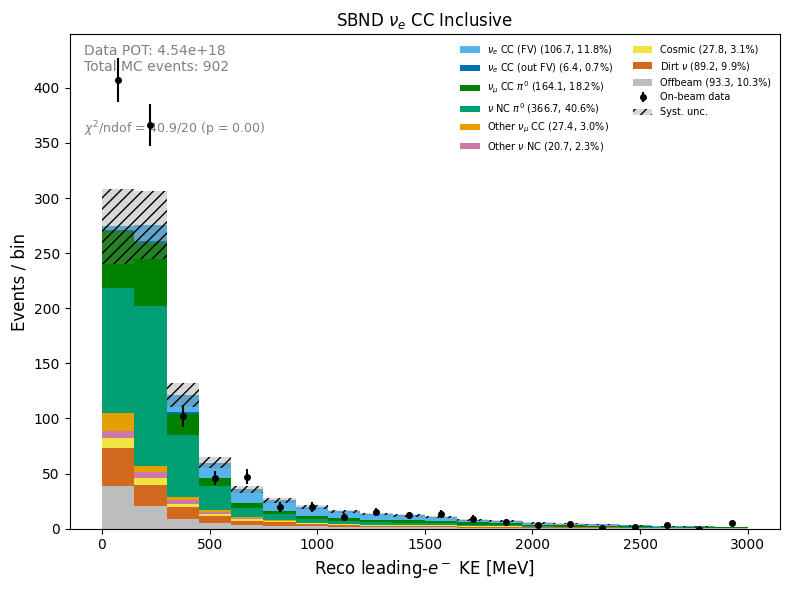

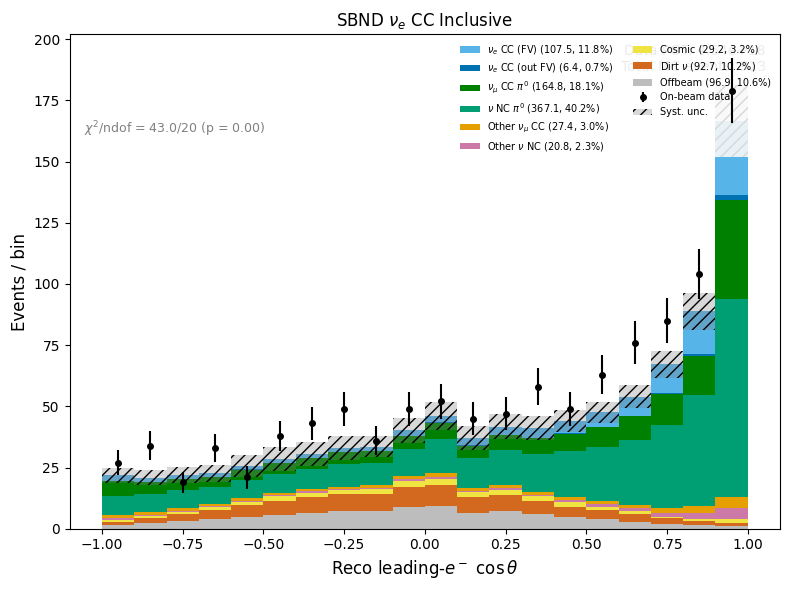

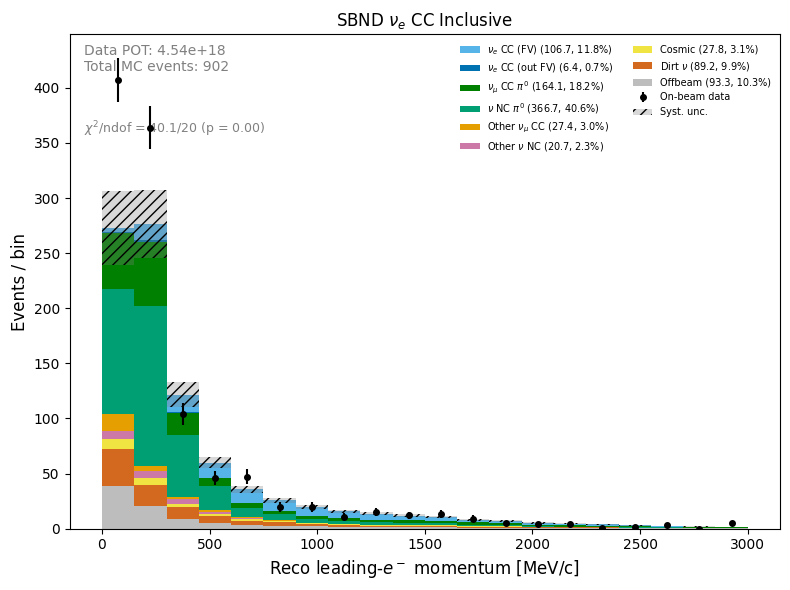

Topology syst+data -> plots_syst/


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# Topology-stage plots
# ══════════════════════════════════════════════════════════════════════════════
TOPO_STAGE = "sel_single_electron"
TOPO_DISP_BINS = {
    'reco_ke':       np.linspace(0, 3000, 21),
    'reco_costheta': np.linspace(-1, 1,   21),
    'reco_p':        np.linspace(0, 3000, 21),
}
 
for var_name, xlabel in [('reco_ke',       r'Reco leading-$e^-$ KE [MeV]'),
                          ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$'),
                          ('reco_p',        r'Reco leading-$e^-$ momentum [MeV/c]')]:
    if var_name not in TOPO_DISP_BINS or var_name not in sel_topo.columns:
        continue
    disp_bins = TOPO_DISP_BINS[var_name]
    proxy     = 'reco_costheta' if var_name == 'reco_costheta' else 'reco_ke'
    frac_disp = _frac_unc_sig(proxy, disp_bins)
 
    series_list  = []
    weights_list = []
    for cat in [0,1,2,3,4,5,6]:
        m = sel_topo[TOPO_STAGE] & (sel_topo['truth_cat']==cat) & sel_topo[var_name].notna()
        vals = sel_topo.loc[m,var_name].values
        series_list.append(vals)
        weights_list.append(np.full(len(vals),pot_scale_to_data))
    
    dv = LOWE_RECO_TOPO.get(var_name,np.array([]))
    dv = np.asarray(dv,dtype=float)
    dv = dv[~np.isnan(dv)]
    series_list.append(dv)
    weights_list.append(np.full(len(dv),lowE_pot_scale_to_data))
    
    _add_offbeam(
        series_list,
        weights_list,
        OFFBEAM_RECO_TOPO.get(var_name),
        offbeam_scale)
        
 
    total_cv_t = _total_with_offbeam(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_cv_t
    data_series = DATA_RECO_TOPO.get(var_name)
 
    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=_labels, colors=_colors,
        bins=disp_bins, weights=weights_list,
        xlabel=xlabel, title=TITLE,
        pot_label=f'Data POT: {data_total_pot:.2e}',
        ax=ax, invert_stack_order=True, show_counts=True, show_percentage=True,
        data_series=data_series, data_label='On-beam data')
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_cv_t-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)
    if data_series is not None and len(data_series) > 0:
        dc, _ = np.histogram(data_series, bins=disp_bins)
        cov = np.diag(total_cv_t + (frac_disp*total_cv_t)**2)
        ax.text(0.02, 0.80, chi2_text(dc.astype(float), total_cv_t, cov),
                transform=ax.transAxes, fontsize=9, color='gray')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{var_name}_topo_with_syst_band_data')
 
print('Topology syst+data -> plots_syst/')

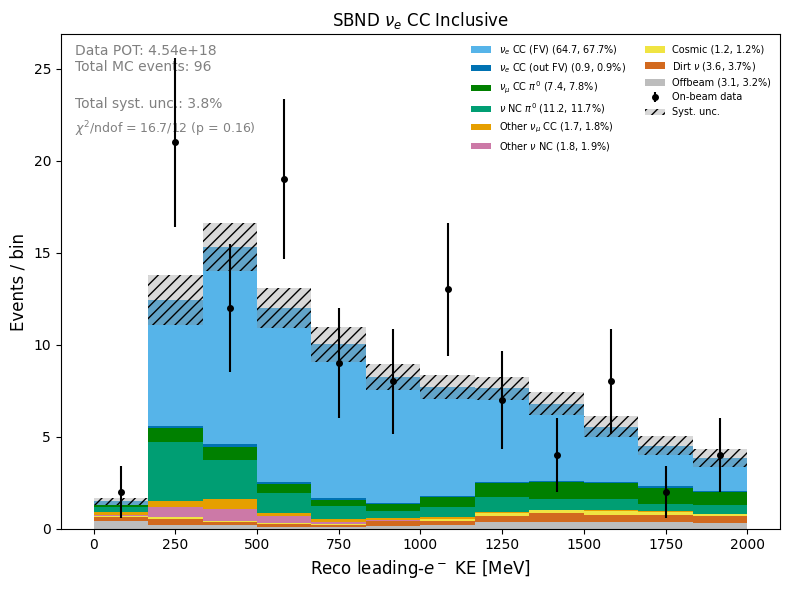

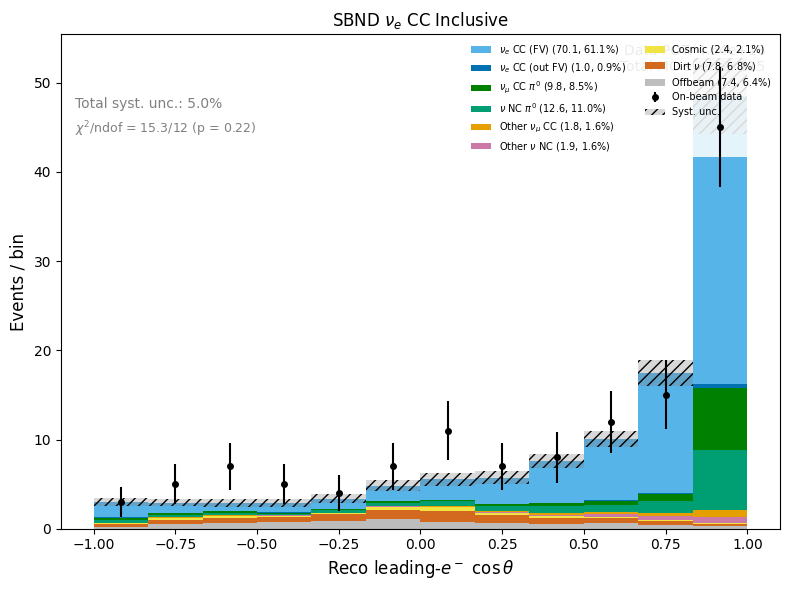

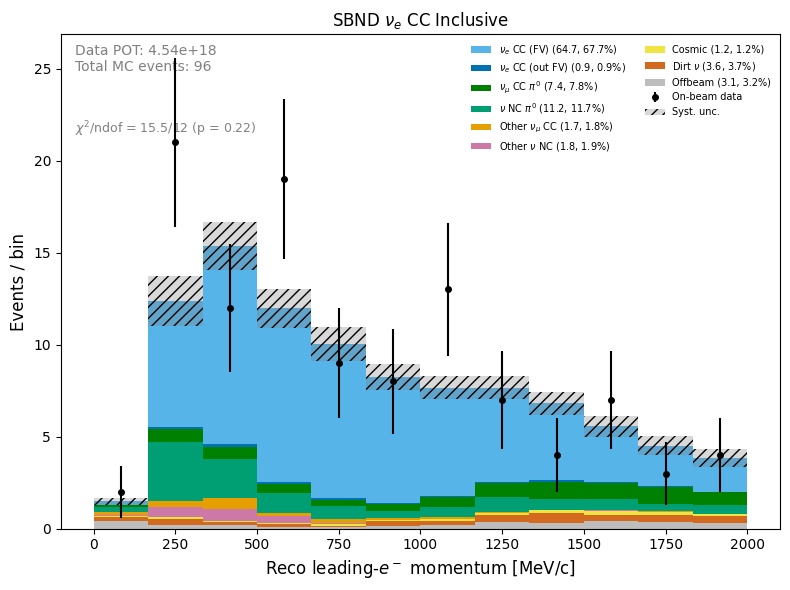

Stacked+syst+data -> plots_syst/


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# Final-selection plots
# ══════════════════════════════════════════════════════════════════════════════
DISP_BINS_FINAL = {
    'reco_ke':       np.linspace(0, 2000, 13),
    'reco_costheta': np.linspace(-1, 1,   13),
    'reco_p':        np.linspace(0, 2000, 13),
}
_extra_mask = sel_topo['reco_ke'].notna() & sel_topo['reco_costheta'].notna()
 
for var_name, xlabel in [('reco_ke',       r'Reco leading-$e^-$ KE [MeV]'),
                          ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$'),
                          ('reco_p',        r'Reco leading-$e^-$ momentum [MeV/c]')]:
    if var_name not in DISP_BINS_FINAL or var_name not in sel_topo.columns:
        continue
    disp_bins = DISP_BINS_FINAL[var_name]
    proxy     = 'reco_costheta' if var_name == 'reco_costheta' else 'reco_ke'
    frac_disp = _frac_unc_sig(proxy, disp_bins)
 
    series_list  = []
    weights_list = []
    for cat in [0,1,2,3,4,5,6]:
        m = sel_topo[FINAL_STAGE] & (sel_topo['truth_cat']==cat) & _extra_mask
        vals = sel_topo.loc[m,var_name].dropna().values
        series_list.append(vals)
        weights_list.append(np.full(len(vals),pot_scale_to_data))
    
    dv = LOWE_RECO_FINAL.get(var_name,np.array([]))
    dv = np.asarray(dv,dtype=float)
    dv = dv[~np.isnan(dv)]
    
    series_list.append(dv)
    weights_list.append(np.full(len(dv),lowE_pot_scale_to_data))
    
    _add_offbeam(
        series_list,
        weights_list,
        OFFBEAM_RECO.get(var_name),
        offbeam_scale)
 
    if all(len(s)==0 for s in series_list):
        print(f"  {var_name} empty — skipping"); continue
 
    total_disp = _total_with_offbeam(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_disp
    data_vals  = DATA_RECO.get(var_name)
 
    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=_labels, colors=_colors,
        bins=disp_bins, weights=weights_list,
        xlabel=xlabel, title=TITLE,
        pot_label=f'Data POT: {data_total_pot:.2e}',
        ax=ax, invert_stack_order=True, show_counts=True, show_percentage=True,
        data_series=data_vals, data_label='On-beam data')
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_disp-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)
    if data_vals is not None and len(data_vals) > 0:
        dc, _ = np.histogram(data_vals, bins=disp_bins)
        cov = np.diag(total_disp + (frac_disp*total_disp)**2)
        ax.text(0.02, 0.80, chi2_text(dc.astype(float), total_disp, cov),
                transform=ax.transAxes, fontsize=9, color='gray')
    vcfg = next((v for v in VAR_CFGS if v.name == var_name), None)
    if vcfg is not None:
        tv = sum(np.diag(_mat(cov_results[var_name][s]['cov_ms_ms'])).clip(0)
                 for s in cov_results[var_name])
        cv = cv_results[var_name]
        tf = np.sqrt(tv.sum())/cv['sig_cv'].sum() if cv['sig_cv'].sum()>0 else 0
        ax.text(0.02, 0.85, f'Total syst. unc.: {tf*100:.1f}%',
                transform=ax.transAxes, fontsize=10, color='gray')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{var_name}_cv_with_syst_band_data')
 
print('Stacked+syst+data -> plots_syst/')


Differential: cosθ in KE slices


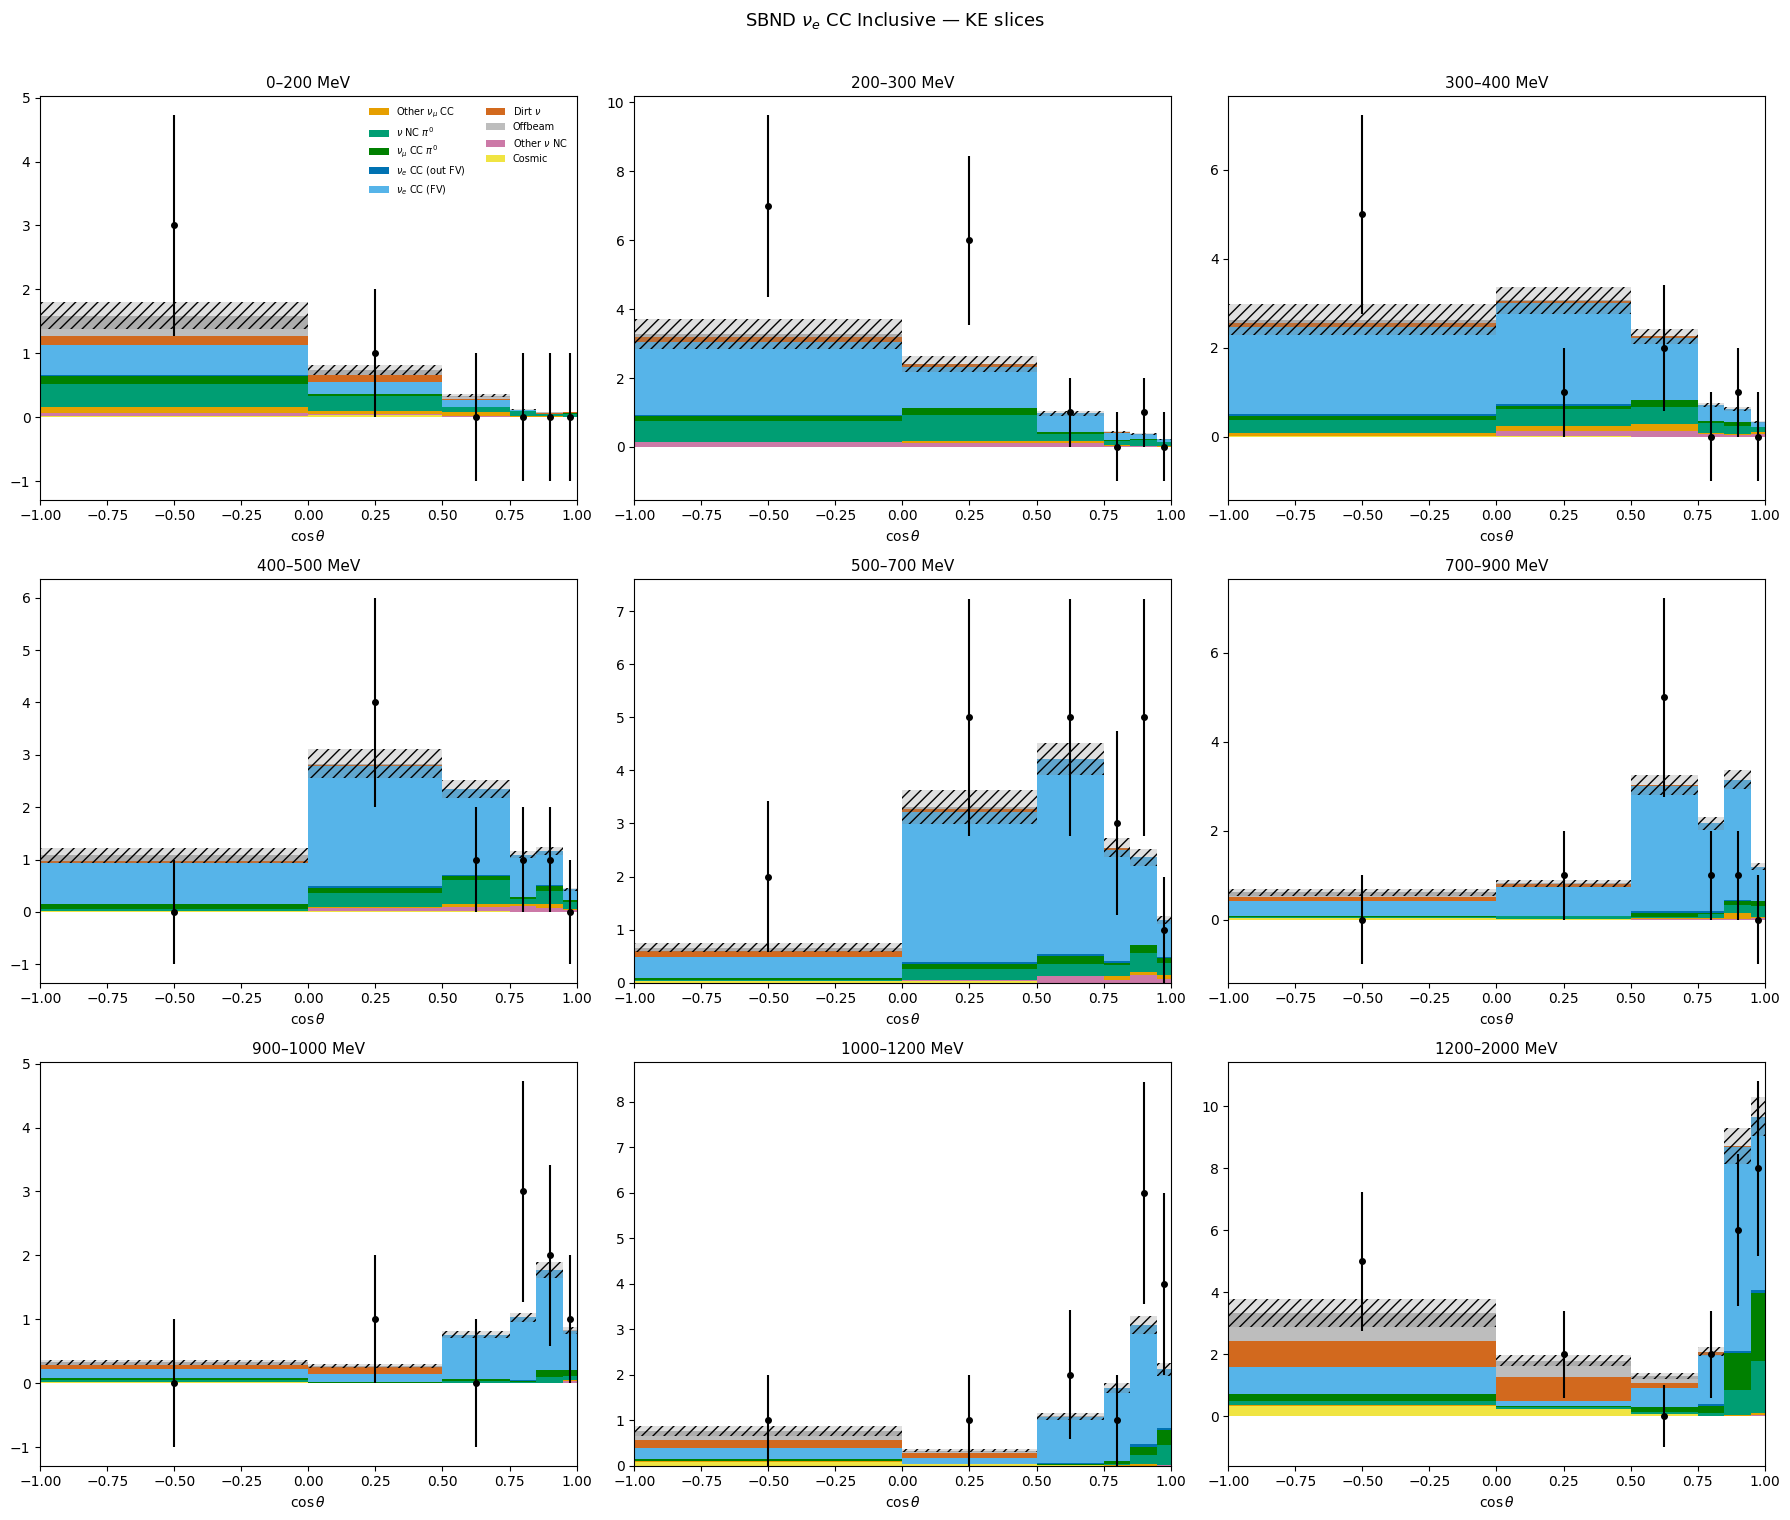


Differential: KE in cosθ slices


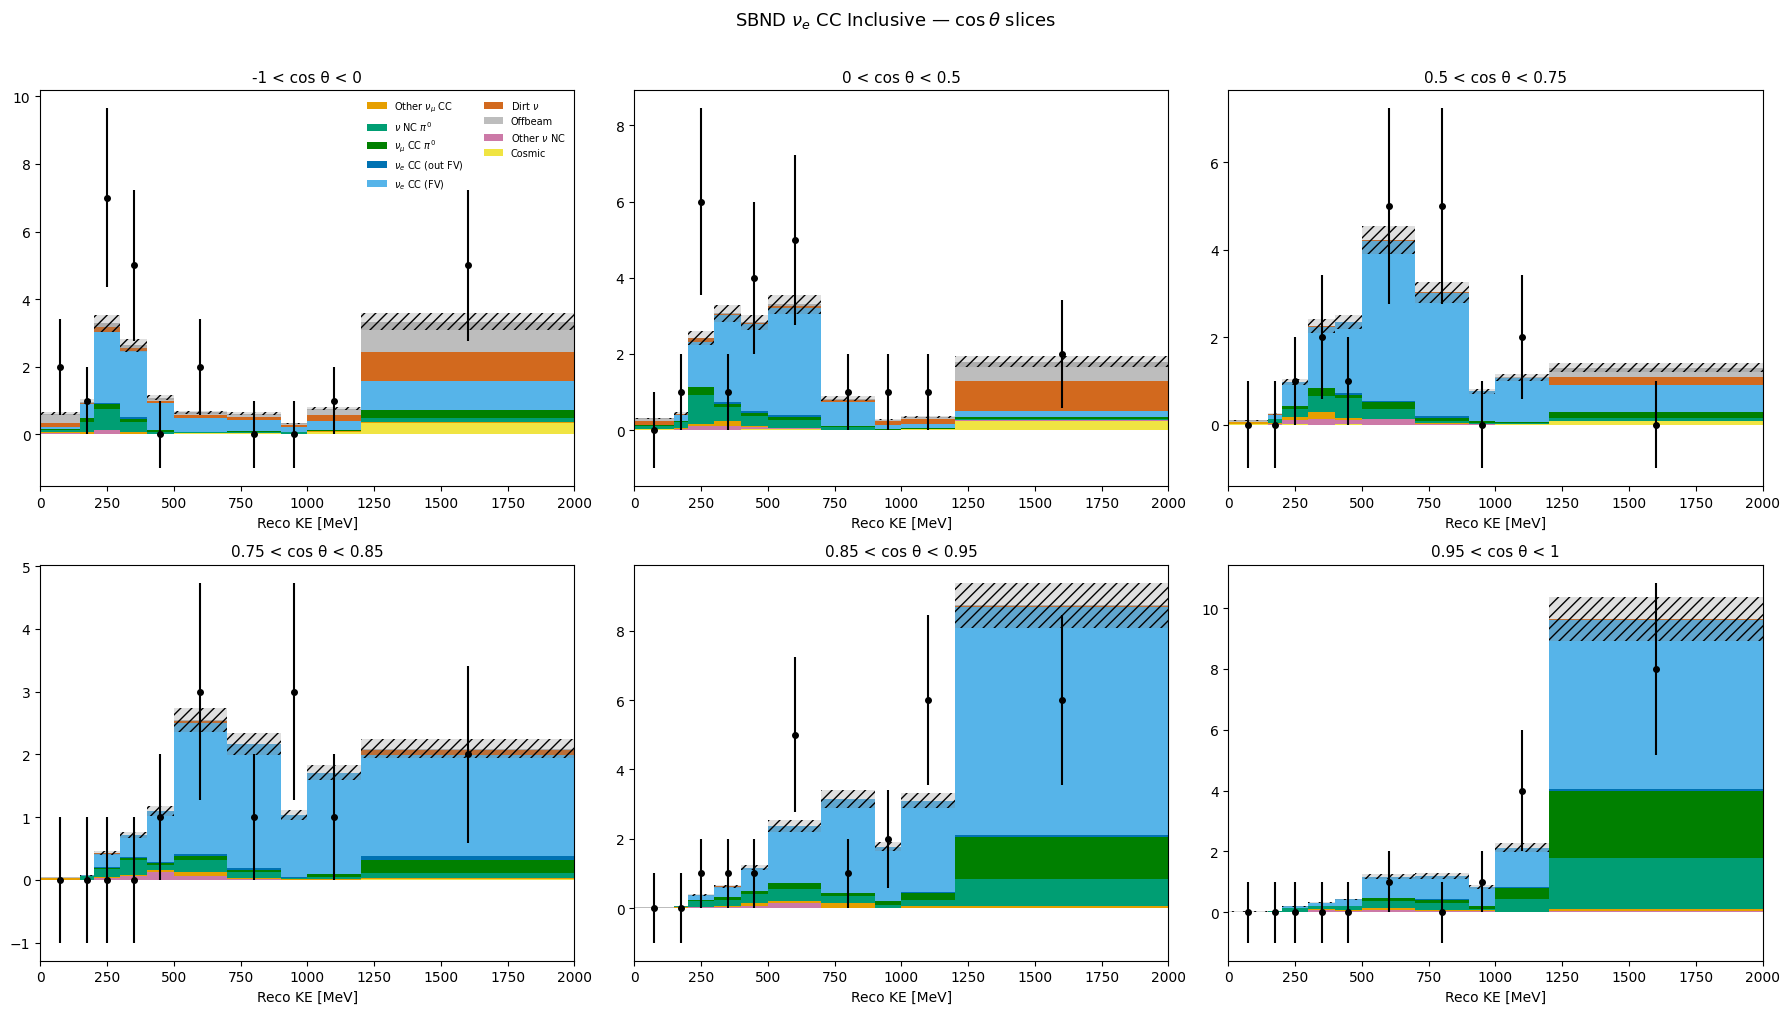

(<Figure size 1800x1000 with 6 Axes>,
 array([[<Axes: title={'center': '-1 < cos θ < 0'}, xlabel='Reco KE [MeV]'>,
         <Axes: title={'center': '0 < cos θ < 0.5'}, xlabel='Reco KE [MeV]'>,
         <Axes: title={'center': '0.5 < cos θ < 0.75'}, xlabel='Reco KE [MeV]'>],
        [<Axes: title={'center': '0.75 < cos θ < 0.85'}, xlabel='Reco KE [MeV]'>,
         <Axes: title={'center': '0.85 < cos θ < 0.95'}, xlabel='Reco KE [MeV]'>,
         <Axes: title={'center': '0.95 < cos θ < 1'}, xlabel='Reco KE [MeV]'>]],
       dtype=object))

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# Differential slice plots (both directions)
# ══════════════════════════════════════════════════════════════════════════════
from nue_xsec_helpers import make_nuecc_binning2d

binning2d = make_nuecc_binning2d()
cos_bins_diff = binning2d.diff_costheta_bins.copy()
cos_bins_diff[-1] = 1.0

# ── KE slice edges from 2D binning, merge [0,150]+[150,200] → [0,200] ────
p_edges_raw = sorted(set(
    edge for pbin in binning2d.diff_momentum_bins_2d for edge in pbin))
# Remove 150 to merge first two bins
p_edges = [e for e in p_edges_raw if e != 150]
ke_slices = list(zip(p_edges[:-1], p_edges[1:]))

# ── cosθ slice edges ──────────────────────────────────────────────────────
cos_slices = list(zip(cos_bins_diff[:-1], cos_bins_diff[1:]))

# ── KE bins for the cosθ-sliced plots ────────────────────────────────────
ke_bins_diff = np.unique(np.concatenate(binning2d.diff_momentum_bins_2d))
ke_bins_diff = ke_bins_diff[ke_bins_diff <= 2000.0]

# ── 1) cosθ in KE slices (each subplot = KE range, x-axis = cosθ) ────────
print("\n" + "="*70 + "\nDifferential: cosθ in KE slices\n" + "="*70)

nh.plot_differential_slices(
    sel_df=sel_topo, stage_col=FINAL_STAGE,
    slice_var='reco_ke', plot_var='reco_costheta',
    slice_edges=ke_slices, plot_bins=cos_bins_diff,
    pot_scale=pot_scale_to_data,
    data_reco_dict=DATA_RECO,
    offbeam_reco_dict=OFFBEAM_RECO, offbeam_weight=offbeam_scale,
    dirt_reco_dict=LOWE_RECO_FINAL, dirt_weight=lowE_pot_scale_to_data,
    frac_unc_fn=interp_frac_unc,
    title=fr'{TITLE} — KE slices',
    xlabel=r'$\cos\theta$',
    savefig_fn=savefig,
    filename='nuecc_differential_ke_slices_data')

# ── 2) KE in cosθ slices (each subplot = cosθ range, x-axis = KE) ────────
print("\n" + "="*70 + "\nDifferential: KE in cosθ slices\n" + "="*70)

nh.plot_differential_slices(
    sel_df=sel_topo, stage_col=FINAL_STAGE,
    slice_var='reco_costheta', plot_var='reco_ke',
    slice_edges=cos_slices, plot_bins=ke_bins_diff,
    pot_scale=pot_scale_to_data,
    data_reco_dict=DATA_RECO,
    offbeam_reco_dict=OFFBEAM_RECO, offbeam_weight=offbeam_scale,
    dirt_reco_dict=LOWE_RECO_FINAL, dirt_weight=lowE_pot_scale_to_data,
    frac_unc_fn=interp_frac_unc,
    title=fr'{TITLE} — $\cos\theta$ slices',
    xlabel=r'Reco KE [MeV]',
    savefig_fn=savefig,
    filename='nuecc_differential_costheta_slices_data')

In [56]:
# # ══════════════════════════════════════════════════════════════════════════════
# # Differential costheta slices
# # ══════════════════════════════════════════════════════════════════════════════
# from nue_xsec_helpers import make_nuecc_binning2d, plot_nuecc_differential_stacked
# import inspect

# binning2d_nue = make_nuecc_binning2d()

# cv_ke        = cv_results['reco_ke']
# covs_ke      = cov_results['reco_ke']
# total_var_ke = sum(np.diag(_mat(covs_ke[s]['cov_ms_ms'])).clip(0) for s in covs_ke)
# frac_unc_ke  = np.where(cv_ke['sig_cv'] > 0,
#                         np.sqrt(total_var_ke) / cv_ke['sig_cv'], 0.0)

# _diff_kwargs = dict(
#     sel_df               = sel_topo,
#     stage_col            = FINAL_STAGE,
#     ke_col               = 'reco_ke',
#     costheta_col         = 'reco_costheta',
#     truth_cat_col        = 'truth_cat',
#     binning2d            = binning2d_nue,
#     display_cats         = [0,1,2,3,4,5,6,9],
#     labels               = [nh.CAT_LABELS[c] for c in [0,1,2,3,4,5,6,9]],
#     colors               = [nh.CAT_COLORS[c] for c in [0,1,2,3,4,5,6,9]],
#     pot_scale            = pot_scale_to_data,
#     pot_label            = f'Data POT: {data_total_pot:.2e}',
#     frac_unc_ke          = frac_unc_ke,
#     reco_ke_bins         = VAR_CFGS[0].bins,
#     title                = fr'{TITLE} — $\cos\theta_e$ slices',
#     plot_dir             = PLOT_DIR,
#     filename             = 'nuecc_differential_costheta_slices_data',
#     plot_stacked_hist_fn = nh.plot_stacked_hist,

#     offbeam_ke           = OFFBEAM_RECO.get('reco_ke', np.array([])),
#     offbeam_cos          = OFFBEAM_RECO.get('reco_costheta', np.array([])),
#     offbeam_weight       = offbeam_scale,

#     dirt_ke              = LOWE_RECO_FINAL.get('reco_ke', np.array([])),
#     dirt_cos             = LOWE_RECO_FINAL.get('reco_costheta', np.array([])),
#     dirt_weight          = lowE_pot_scale_to_data,
# )

# _sig = inspect.signature(plot_nuecc_differential_stacked)

# if 'data_ke' in _sig.parameters:
#     _diff_kwargs['data_ke'] = DATA_RECO.get('reco_ke')
#     _diff_kwargs['data_cos'] = DATA_RECO.get('reco_costheta')
#     _diff_kwargs['data_label'] = 'On-beam data'

# if 'dirt_ke' not in _sig.parameters:
#     _diff_kwargs.pop('dirt_ke', None)
#     _diff_kwargs.pop('dirt_cos', None)
#     _diff_kwargs.pop('dirt_weight', None)

# if 'offbeam_ke' not in _sig.parameters:
#     _diff_kwargs.pop('offbeam_ke', None)
#     _diff_kwargs.pop('offbeam_cos', None)
#     _diff_kwargs.pop('offbeam_weight', None)

# fig, axs = plot_nuecc_differential_stacked(**_diff_kwargs)

In [57]:
# print("\n" + "="*70 +
#       "\nDifferential: costheta in momentum slices\n" + "="*70)
 
# binning2d = make_nuecc_binning2d()
# cos_bins_global = binning2d.diff_costheta_bins.copy()
# cos_bins_global[-1] = 1.0
 
# # Momentum slice edges from the 2D binning
# p_slice_edges = sorted(set(
#     edge for pbin in binning2d.diff_momentum_bins_2d for edge in pbin))
# # Build slices as consecutive pairs
# p_slices = list(zip(p_slice_edges[:-1], p_slice_edges[1:]))
# # Remove duplicates / ensure unique
# p_slices = sorted(set(p_slices))
 
# n_slices = len(p_slices)
# ncols = min(3, n_slices)
# nrows = (n_slices + ncols - 1) // ncols
 
# fig_diff, axes_diff = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows),
#                                     squeeze=False)
# axes_flat = axes_diff.flatten()
 
# DISPLAY_CATS_DIFF = [0, 1, 2, 3, 4, 5, 6, 9, 7]
 
# for si, (p_lo, p_hi) in enumerate(p_slices):
#     ax = axes_flat[si]
 
#     # MC: select final-stage events in this momentum slice
#     mc_final = sel_topo[sel_topo[FINAL_STAGE]].copy()
#     mc_slice = mc_final[(mc_final['reco_ke'] >= p_lo) & (mc_final['reco_ke'] < p_hi)]
 
#     series_list  = []
#     weights_list = []
#     labels_sl    = []
#     colors_sl    = []
 
#     for cat in DISPLAY_CATS_DIFF:
#         if cat <= 6:
#             vals = mc_slice.loc[mc_slice['truth_cat'] == cat, 'reco_costheta'].dropna().values
#             w = np.full(len(vals), pot_scale_to_data)
#         elif cat == 9:
#             # Dirt in this momentum slice
#             dirt_ke  = np.asarray(LOWE_RECO_FINAL.get('reco_ke', []), dtype=float)
#             dirt_cos = np.asarray(LOWE_RECO_FINAL.get('reco_costheta', []), dtype=float)
#             valid = ~np.isnan(dirt_ke) & ~np.isnan(dirt_cos)
#             mask = valid & (dirt_ke >= p_lo) & (dirt_ke < p_hi)
#             vals = dirt_cos[mask]
#             w = np.full(len(vals), lowE_pot_scale_to_data)
#         elif cat == 7:
#             # Offbeam in this momentum slice
#             ob_ke  = np.asarray(OFFBEAM_RECO.get('reco_ke', []), dtype=float)
#             ob_cos = np.asarray(OFFBEAM_RECO.get('reco_costheta', []), dtype=float)
#             valid = ~np.isnan(ob_ke) & ~np.isnan(ob_cos)
#             mask = valid & (ob_ke >= p_lo) & (ob_ke < p_hi)
#             vals = ob_cos[mask]
#             w = np.full(len(vals), offbeam_scale)
#         else:
#             continue
 
#         series_list.append(vals)
#         weights_list.append(w)
#         labels_sl.append(nh.CAT_LABELS[cat])
#         colors_sl.append(nh.CAT_COLORS[cat])
 
#     # Total MC for syst band
#     total_sl = np.zeros(len(cos_bins_global) - 1)
#     for s, w in zip(series_list, weights_list):
#         h, _ = np.histogram(s, bins=cos_bins_global, weights=w)
#         total_sl += h
 
#     frac_sl = interp_frac_unc(cos_bins_global, 'reco_costheta')
#     unc_sl  = frac_sl * total_sl
 
#     # Plot
#     nh.plot_stacked_hist(
#         series_list=series_list, labels=labels_sl, colors=colors_sl,
#         bins=cos_bins_global, weights=weights_list,
#         xlabel=r'$\cos\theta$', title='',
#         pot_label='', ax=ax,
#         invert_stack_order=True, show_counts=False, show_percentage=False)
 
#     bw = np.diff(cos_bins_global)
#     ax.bar(cos_bins_global[:-1], 2*unc_sl, bottom=total_sl - unc_sl,
#            width=bw, align='edge', alpha=0.25, color='gray',
#            hatch='///', linewidth=0)
 
#     # Data in this momentum slice
#     data_ke  = np.asarray(DATA_RECO.get('reco_ke', []), dtype=float)
#     data_cos = np.asarray(DATA_RECO.get('reco_costheta', []), dtype=float)
#     valid_d  = ~np.isnan(data_ke) & ~np.isnan(data_cos)
#     d_mask   = valid_d & (data_ke >= p_lo) & (data_ke < p_hi)
#     data_sl  = data_cos[d_mask]
 
#     if len(data_sl) > 0:
#         dc, _ = np.histogram(data_sl, bins=cos_bins_global)
#         centers = 0.5 * (cos_bins_global[:-1] + cos_bins_global[1:])
#         ax.errorbar(centers, dc, yerr=np.sqrt(dc.clip(1)),
#                     fmt='ko', ms=4, zorder=10)
 
#     ax.set_title(f'{int(p_lo)}–{int(p_hi)} MeV', fontsize=11)
#     ax.set_xlim(cos_bins_global[0], cos_bins_global[-1])
 
#     # Only keep legend on first subplot
#     if si > 0:
#         leg = ax.get_legend()
#         if leg: leg.remove()
 
# # Hide unused axes
# for j in range(si + 1, len(axes_flat)):
#     axes_flat[j].set_visible(False)
 
# fig_diff.suptitle(fr'{TITLE} — KE slices', fontsize=13, y=1.01)
# fig_diff.tight_layout()
# savefig(fig_diff, 'nuecc_differential_ke_slices_data')
# print('Differential costheta in KE slices saved.')



load_evtdf_slim  mode='reco_min_true'  keys=10 sub-keys

load_evtdf_slim  mode='reco_min_true'  key='/evt_0'
  Total cols :  124  →  kept:  124  dropped:    0  (0% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction               0      0
  dlp_true_particle                 16     16
  mcnu                               0      0
  index_artifact                     4      4
  other                              0      0

  Post-drop shape per sub-key: ~(1135881, 124)
  Concatenating 10 parts (11,356,242 total rows) ...
  Final shape: (11356242, 124)
pid_score: MC=69,929  Data=1,107  Dirt=6,950
  After topology cut / Leading electron PID score:
    Data/Pred = 1.357 ± 0.041 (stat.) ± 0.028 (syst.)
    chi2/ndf = 56.2/40  p = 0.046


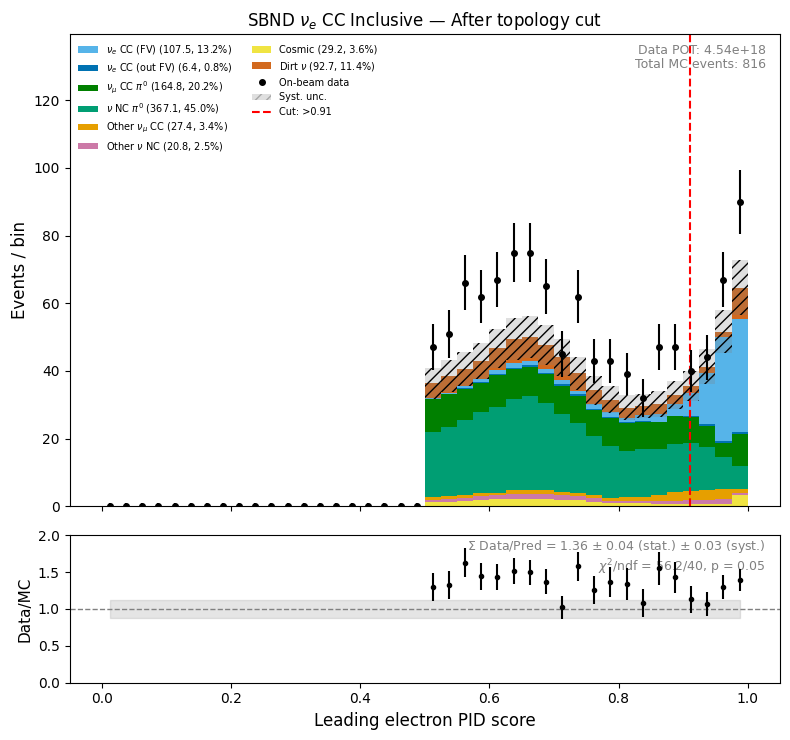

primary_score: MC=69,929  Data=1,107  Dirt=6,950
  After topology cut / Leading electron primary score:
    Data/Pred = 1.357 ± 0.041 (stat.) ± 0.086 (syst.)
    chi2/ndf = 36.4/40  p = 0.634


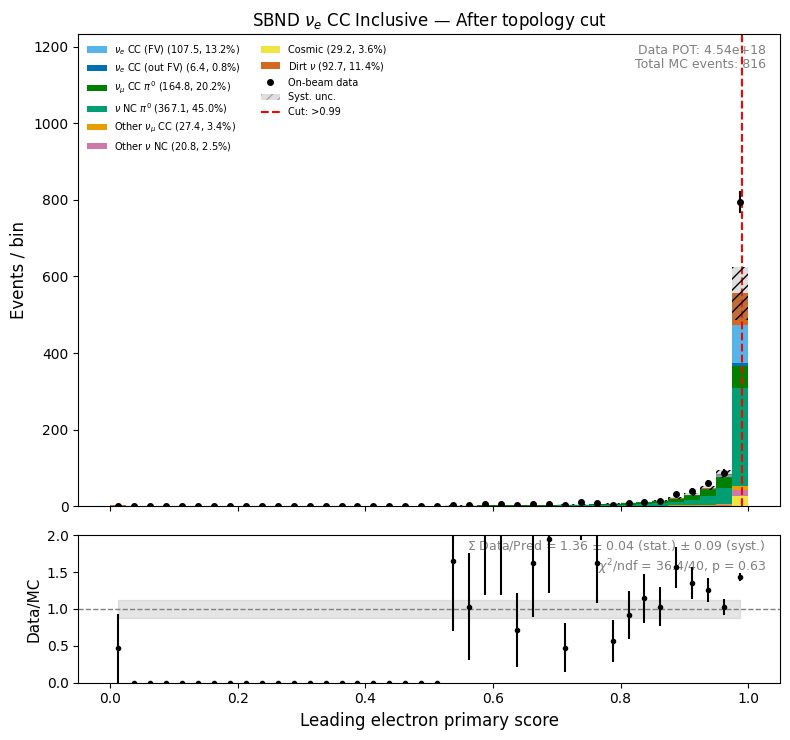

vertex_dist: MC=69,929  Data=1,107  Dirt=6,950
  After topology cut / Vertex distance [cm]:
    Data/Pred = 1.315 ± 0.043 (stat.) ± 0.058 (syst.)
    chi2/ndf = 56.8/40  p = 0.041


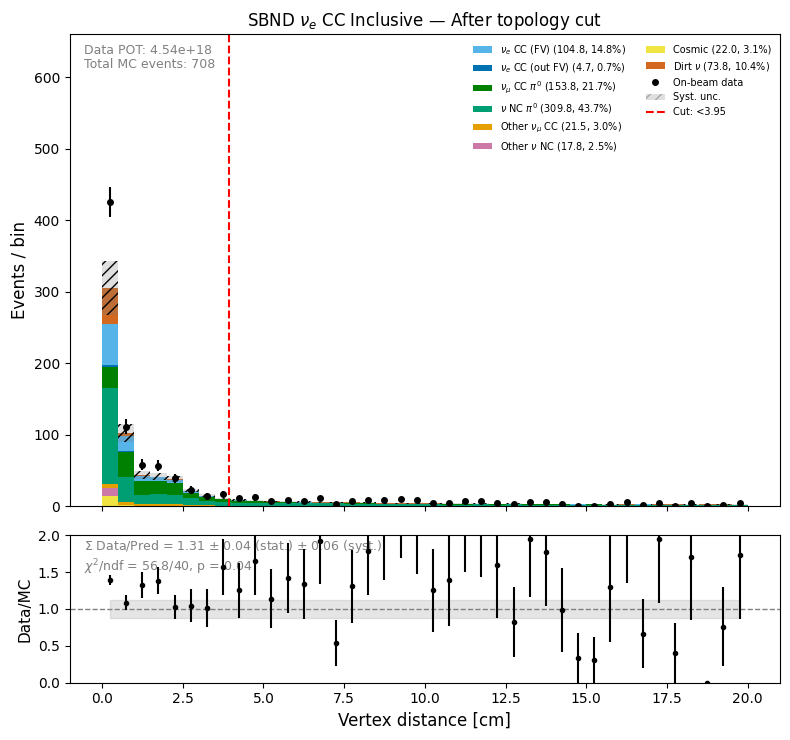

calo_ke: MC=69,929  Data=1,107  Dirt=6,950
  After topology cut / Leading electron calo KE [MeV]:
    Data/Pred = 1.220 ± 0.037 (stat.) ± 0.036 (syst.)
    chi2/ndf = 68.9/40  p = 0.003


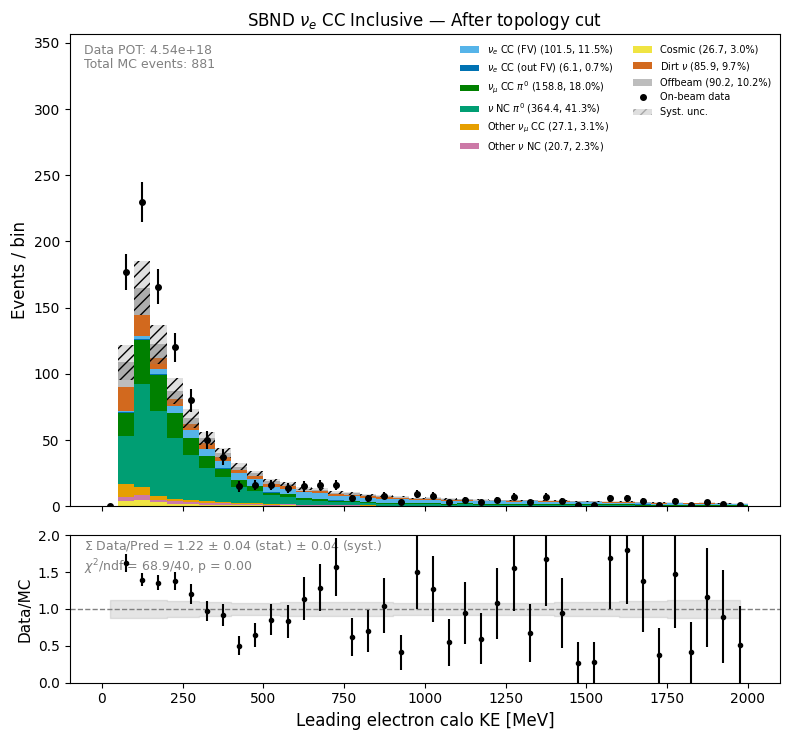

Extra variable plots -> ./plots_syst/


5394

In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# Extra selection variables
# ══════════════════════════════════════════════════════════════════════════════
from mem_optimizer import load_evtdf_slim

mc_evtdf_extra = load_evtdf_slim(DF_FILE, key=None, mode="reco_min_true")
mc_il_extra    = list(range(mc_evtdf_extra.index.nlevels - 1))

mc_se_idx      = sel_topo.index[sel_topo["sel_single_electron"]]
truth_cat_topo = sel_topo.loc[mc_se_idx,"truth_cat"]

lowE_se_idx = lowE_cut_flow["single_electron"]["inter_index"]

nh.plot_extra_selection_vars(
    mc_evtdf=mc_evtdf_extra,
    data_evtdf=data_evtdf_patched,
    sel_topo=sel_topo,
    mc_se_idx=mc_se_idx,
    data_se_idx=data_cut_flow["single_electron"]["inter_index"],
    mc_il=mc_il_extra,
    data_il=data_il,
    truth_cat_at_topo=truth_cat_topo,
    pot_scale_to_data=pot_scale_to_data,
    data_total_pot=data_total_pot,
    cov_results=cov_results,
    cv_results=cv_results,
    var_cfgs=VAR_CFGS,
    chi2_text_fn=chi2_text,
    savefig_fn=savefig,
    title=TITLE,
    data_label='On-beam data',
    plot_dir=PLOT_DIR,
    offbeam_shower_vars=OFFBEAM_SHOWER_VARS,
    offbeam_weight=offbeam_scale,
    dirt_evtdf=lowE_evtdf,
    dirt_se_idx=lowE_cut_flow["single_electron"]["inter_index"],
    dirt_il=lowE_il,
    dirt_weight=lowE_pot_scale_to_data,
)

del mc_evtdf_extra
gc.collect()

In [59]:
# # Check what fraction of weights are NaN in wgt_aligned
# nan_frac = wgt_aligned[bnb_cols_aligned].isna().mean().mean()
# print(f'NaN fraction in BNB weights: {nan_frac:.1%}')

# # Check a few weight values for matched rows
# matched = wgt_aligned[bnb_cols_aligned[0]].notna()
# print(f'Matched interactions: {matched.sum()} / {len(matched)}')
# print(wgt_aligned.loc[matched, bnb_cols_aligned[:3]].describe())

In [60]:
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    scale = pot_scale  # your pot_scale from the selection notebook
    print(f"\n{vcfg.name} — estimated raw MC events per bin:")
    print(f"  signal : {np.round(cv['sig_cv'] / scale, 1)}")
    print(f"  bkg    : {np.round(cv['bkg_cv'] / scale, 1)}")


reco_ke — estimated raw MC events per bin:
  signal : [ 363. 1448. 1216.  916.  696.  454.  721.]
  bkg    : [335. 579. 227. 162. 261. 249. 633.]

reco_costheta — estimated raw MC events per bin:
  signal : [ 157.  111.   95.  109.  164.  235.  325.  565. 1088. 2965.]
  bkg    : [  76.   70.   59.   63.   90.  124.  129.  198.  268. 1369.]


## 17. Unfolding with Omnifold 

In [61]:
# ── Export per-bin efficiency + flux/targets for OmniFold xsec ────────────────
import numpy as np, os

OMNIFOLD_OUT = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
os.makedirs(OMNIFOLD_OUT, exist_ok=True)

RECO_VARS   = ['reco_ke', 'reco_costheta', 'reco_p']
FINAL_STAGE = 'sel_vertex_distance'

sig_all = sel_topo[sel_topo['is_sig']]
sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo[FINAL_STAGE]].copy()
reco_raw = sig_sel[RECO_VARS].values.astype(np.float32)
sig_sel_valid = sig_sel[~np.isnan(reco_raw).any(axis=1)]

bins_ke  = np.array([0, 200, 400, 600, 800, 1000, 1400, 2000])
bins_cos = np.linspace(-1, 1, 11)

for var, bins, label in [('true_ke', bins_ke, 'true_ke'),
                          ('true_costheta', bins_cos, 'true_costheta')]:
    N_all, _ = np.histogram(sig_all[var].dropna(), bins=bins)
    N_sel, _ = np.histogram(sig_sel_valid[var].dropna(), bins=bins)
    eff = N_sel / N_all.clip(1)
    np.save(OMNIFOLD_OUT + f'efficiency_{label}.npy', eff)
    centers = 0.5 * (bins[:-1] + bins[1:])
    print(f"\n{label} efficiency:")
    for c, e, na, ns in zip(centers, eff, N_all, N_sel):
        print(f"  {c:8.1f}: {e:.4f}  ({ns}/{na})")

# Save pot_scale and N_targets for cross-section normalization
pot_scale = float(sel_topo['pot_scale'].iloc[0])
np.save(OMNIFOLD_OUT + 'pot_scale.npy', np.array([pot_scale]))
print(f"\npot_scale: {pot_scale}")
print("Saved efficiency and normalization files.")


true_ke efficiency:
     100.0: 0.0885  (60/678)
     300.0: 0.4325  (808/1868)
     500.0: 0.6012  (977/1625)
     700.0: 0.6312  (806/1277)
     900.0: 0.7228  (738/1021)
    1200.0: 0.7878  (1058/1343)
    1700.0: 0.8297  (828/998)

true_costheta efficiency:
      -0.9: 0.3013  (47/156)
      -0.7: 0.3472  (67/193)
      -0.5: 0.3359  (88/262)
      -0.3: 0.2886  (86/298)
      -0.1: 0.4062  (145/357)
       0.1: 0.4915  (232/472)
       0.3: 0.4769  (299/627)
       0.5: 0.5808  (550/947)
       0.7: 0.6380  (1114/1746)
       0.9: 0.7307  (3186/4360)

pot_scale: 1.754459261894226
Saved efficiency and normalization files.


In [ ]:
pause

In [ ]:
%reset -f